# ARTICLE'S MAIN CODES

#### necessary versions of the libraries

In [ ]:
pip install numpy==1.23

In [ ]:
pip install tsfresh==0.20.3 

In [ ]:
pip install pandas==1.5.3 

In [ ]:
pip install scipy==1.7.3

# MAIN CODES

In [317]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from numpy import mean, std
from scipy.stats import shapiro, normaltest, anderson, probplot

from sklearn.compose import make_column_selector as selector
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PolynomialFeatures, FunctionTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error
)
from sklearn.model_selection import (
    cross_val_score,
    RepeatedKFold,
    train_test_split
)

from statsmodels.tsa.holtwinters import ExponentialSmoothing

import gtda.time_series as ts
import gtda.diagrams as diag
from gtda.time_series import TakensEmbedding, SlidingWindow
from gtda.homology import VietorisRipsPersistence
from gtda.pipeline import Pipeline
from gtda.plotting import plot_point_cloud


In [318]:
# Load the file for time series
data_path = 'TRIAL_SET_4_H2ts.xlsx'
data = pd.read_excel(data_path)

In [319]:
SMALL_SIZE = 16
MEDIUM_SIZE = 18
BIGGER_SIZE = 20

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=MEDIUM_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=MEDIUM_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE) 
plt.rcParams['font.family'] = 'DeJavu Serif'
plt.rcParams['font.serif'] = ['Times New Roman']

In [320]:
data

,DateTime,Operation
0,2024-08-14 00:00:00,60
1,2024-08-14 01:00:00,60
2,2024-08-14 02:00:00,60
3,2024-08-14 03:00:00,60
4,2024-08-14 04:00:00,60
...,...,...
678,2024-09-11 06:00:00,51
679,2024-09-11 07:00:00,41
680,2024-09-11 08:00:00,59
681,2024-09-11 09:00:00,50


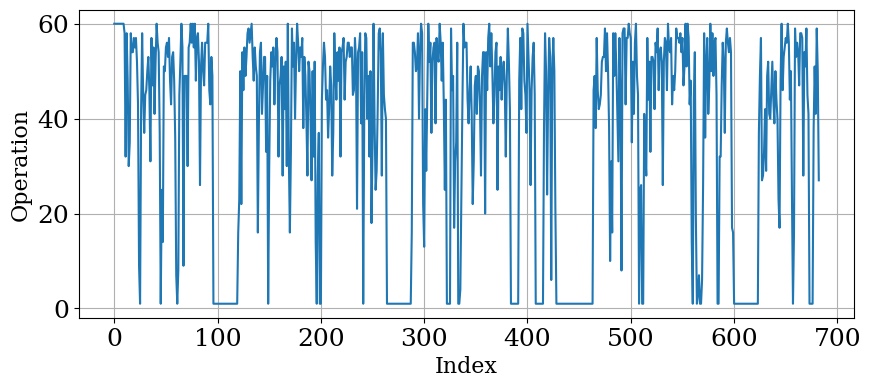

In [324]:
import matplotlib.pyplot as plt

# Reset index
data = data.reset_index(drop=True)

# Plot the 'Operation' column by index
plt.figure(figsize=(10, 4))
plt.plot(data['Operation'].values)
plt.xlabel('Index')
plt.ylabel('Operation')
plt.grid(True)

# Save the plot as SVG
plt.savefig('ts_h2.svg', format='svg')

# Show the plot
plt.show()


# prepare to store results

In [325]:
# Initialize a DataFrame to store results
def initialize_results():
    columns = ['Model_Name', 'MAE', 'MAPE','Cost']
    return pd.DataFrame(columns=columns)

# Function to add new results to the DataFrame
def update_results(results_df, model_name, mae, mape,Cost):
    new_result = {'Model_Name': model_name, 'MAE': mae, 'MAPE': mape , 'Cost': Cost}
    results_df = pd.concat([results_df, pd.DataFrame([new_result])], ignore_index=True)
    return results_df
# Example usage
if __name__ == "__main__":
    # Initialize results DataFrame
    main_results = initialize_results()

# MODEL 0 BASE SARIMA WITHOUT DECOMPOSITION

In [326]:
start_time=time.time()

In [327]:
from statsmodels.tsa.stattools import kpss

# Applying the KPSS test to the training data to test for stationarity
kpss_test = kpss(data['Operation'], regression='c')

# Unpacking the KPSS test results
kpss_statistic, p_value, lags, critical_values = kpss_test

# Displaying the KPSS test results
kpss_test_result = {
    'KPSS Statistic': kpss_statistic,
    'p-value': p_value,
    'Lags Used': lags,
    'Critical Values': critical_values,
    'Conclusion': 'Stationary' if p_value > 0.05 else 'Not stationary'
}

kpss_test_result

{'KPSS Statistic': 0.1786824511629263,
 'p-value': 0.1,
 'Lags Used': 15,
 'Critical Values': {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739},
 'Conclusion': 'Stationary'}

In [328]:
from pmdarima.arima import auto_arima, OCSBTest, CHTest

# time series after first differencing
# OCSB test that returns the recommended order of seasonal differencing:
n_ocsb = OCSBTest(m=12).estimate_seasonal_differencing_term(data['Operation'])

# CH test that returns the recommended order of seasonal differencing:
n_ch = CHTest(m=12).estimate_seasonal_differencing_term(data['Operation'])

# seasonal differencing recommendation:
print("time series -")
n_seasdiffs = {"recommended order of seasonal differencing":"", "OCSB recommendation":n_ocsb, "nCH recommendation":n_ch}
[print(key, ":", value) for key,value in n_seasdiffs.items()]

time series -
recommended order of seasonal differencing : 
OCSB recommendation : 0
nCH recommendation : 0


[None, None, None]

In [329]:
train_data = data[:-4]  # Last 4 rows for testing
test_data = data[-4:]

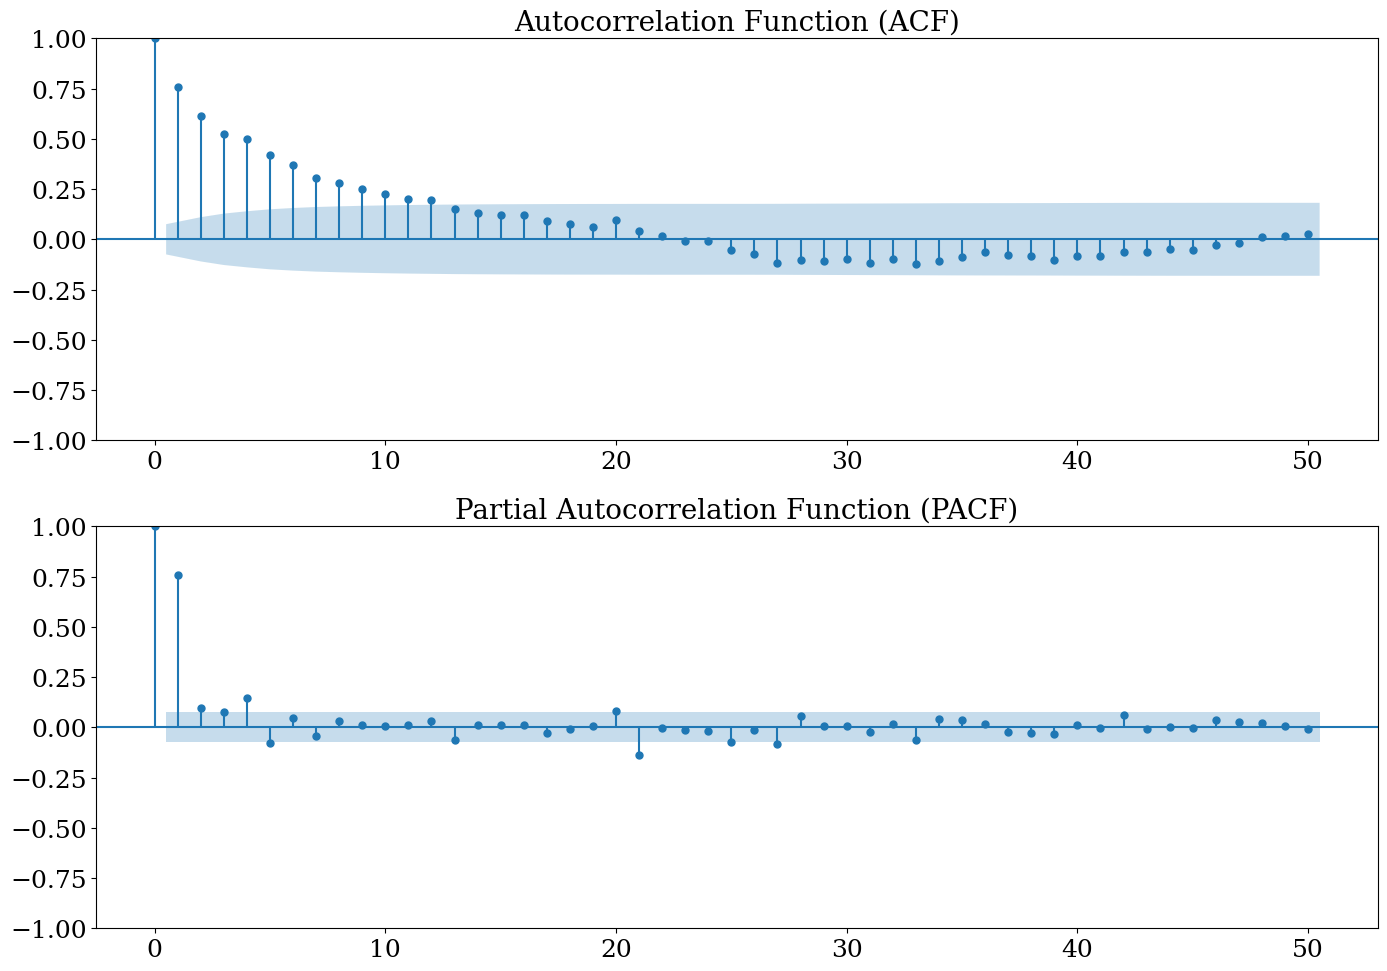

In [331]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot ACF and PACF for the cleaned training data
plt.figure(figsize=(14, 10))

# ACF plot
plt.subplot(2, 1, 1)
plot_acf(train_data['Operation'], lags=50, ax=plt.gca())
plt.title("Autocorrelation Function (ACF)")

# PACF plot
plt.subplot(2, 1, 2)
plot_pacf(train_data['Operation'], lags=50, ax=plt.gca(), method='ywm')
plt.title("Partial Autocorrelation Function (PACF)")

# Save the figure as an SVG file
plt.tight_layout()
plt.show()

                               SARIMAX Results                                
Dep. Variable:              Operation   No. Observations:                  679
Model:               SARIMAX(4, 0, 0)   Log Likelihood               -2774.460
Date:                Mon, 31 Mar 2025   AIC                           5558.921
Time:                        16:21:35   BIC                           5581.524
Sample:                             0   HQIC                          5567.671
                                - 679                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7120      0.034     20.703      0.000       0.645       0.779
ar.L2          0.0580      0.043      1.356      0.175      -0.026       0.142
ar.L3         -0.0039      0.047     -0.084      0.9

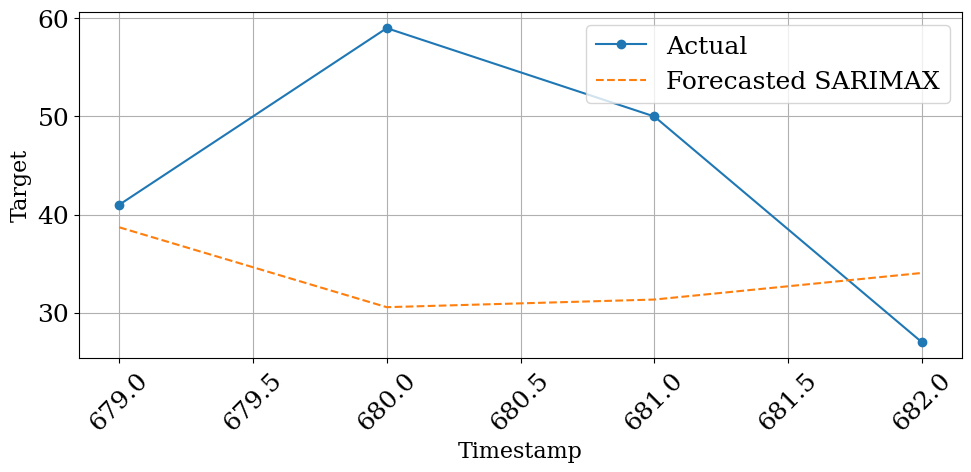

MAE: 14.11, MAPE: 0.29


In [332]:
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt

# Ensure data is sorted
train_data = train_data.sort_index()
test_data = test_data.sort_index()

# Fit SARIMAX model with combined Fourier terms
model = SARIMAX(train_data['Operation'], 
                order=(4, 0, 0),  # AR(4) with no differencing
                seasonal_order=(0, 0, 0, 8)
                )  
sarimax_results = model.fit(disp=False)
print(sarimax_results.summary())
# Forecast using combined Fourier terms
sarimax_forecast = sarimax_results.get_forecast(steps=len(test_data)).predicted_mean


# Evaluation metrics
sarimax_mae = mean_absolute_error(test_data['Operation'], sarimax_forecast)
sarimax_mape = mean_absolute_percentage_error(test_data['Operation'], sarimax_forecast)


# Plot results
plt.figure(figsize=(10, 5))
plt.plot(test_data.index, test_data['Operation'], label='Actual', marker='o')
plt.plot(test_data.index, sarimax_forecast, label='Forecasted SARIMAX', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Print evaluation metrics
print(f"MAE: {sarimax_mae:.2f}, MAPE: {sarimax_mape:.2f}")
mae=sarimax_mae
mape=sarimax_mape 


In [333]:
end_time=time.time()

In [334]:
Cost=end_time-start_time

In [335]:
main_results = update_results(main_results, 'BASE SARIMA WITHOUT DECOMPOSITION', mae, mape,Cost)

In [336]:
main_results

,Model_Name,MAE,MAPE,Cost
0,BASE SARIMA WITHOUT DECOMPOSITION,14.107829,0.293031,35.41875


# MODEL 0-1 BASE AUTO SARIMA WITHOUT DECOMPOSITION

In [16]:
start_time=time.time()

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[8] intercept   : AIC=6123.618, Time=0.06 sec
 ARIMA(1,0,0)(1,0,0)[8] intercept   : AIC=5550.350, Time=1.57 sec
 ARIMA(0,0,1)(0,0,1)[8] intercept   : AIC=5766.846, Time=1.13 sec
 ARIMA(0,0,0)(0,0,0)[8]             : AIC=7020.180, Time=0.03 sec
 ARIMA(1,0,0)(0,0,0)[8] intercept   : AIC=5550.251, Time=0.06 sec
 ARIMA(1,0,0)(0,0,1)[8] intercept   : AIC=5550.556, Time=0.37 sec
 ARIMA(1,0,0)(1,0,1)[8] intercept   : AIC=inf, Time=1.50 sec
 ARIMA(2,0,0)(0,0,0)[8] intercept   : AIC=5545.689, Time=0.29 sec
 ARIMA(2,0,0)(1,0,0)[8] intercept   : AIC=5546.839, Time=0.95 sec
 ARIMA(2,0,0)(0,0,1)[8] intercept   : AIC=5546.930, Time=0.36 sec
 ARIMA(2,0,0)(1,0,1)[8] intercept   : AIC=inf, Time=1.25 sec
 ARIMA(3,0,0)(0,0,0)[8] intercept   : AIC=5543.833, Time=0.20 sec
 ARIMA(3,0,0)(1,0,0)[8] intercept   : AIC=5545.226, Time=1.12 sec
 ARIMA(3,0,0)(0,0,1)[8] intercept   : AIC=5545.288, Time=1.15 sec
 ARIMA(3,0,0)(1,0,1)[8] intercept   : AIC=i

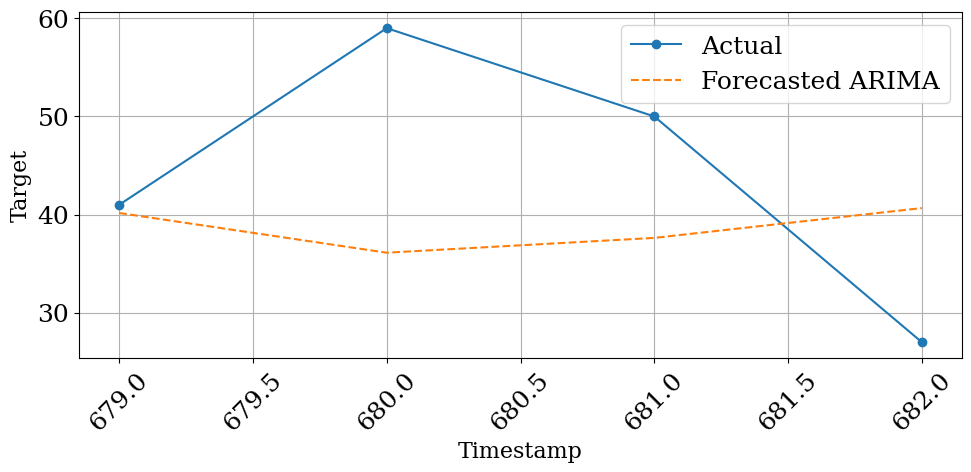

Test MAE: 12.4380
Test MAPE: 0.2904


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# Fit auto_arima with exogenous variables and seasonal period of 8
stepwise_model = auto_arima(
    y=train_data['Operation'],
    seasonal=True,
    m=8,
    start_p=0, start_q=0,
    max_p=5, max_q=5,
    start_P=0, start_Q=0,
    max_P=2, max_Q=2,
    d=None, D=None,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True,
    information_criterion='aic'
)

# Forecast for test period using exogenous variables
n_periods = len(test_data['Operation'])
sarima_predictions = stepwise_model.predict(n_periods=n_periods)

# Calculate evaluation metrics
sarima_mae = mean_absolute_error(test_data['Operation'], sarima_predictions)
sarima_mape = mean_absolute_percentage_error(test_data['Operation'], sarima_predictions)

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(test_data.index, test_data['Operation'], label='Actual', marker='o')
plt.plot(test_data.index, sarima_predictions, label='Forecasted ARIMA', linestyle='--')

plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Output the MAE and MAPE values
print("Test MAE: {:.4f}".format(sarima_mae))
print("Test MAPE: {:.4f}".format(sarima_mape))


In [18]:
end_time=time.time()

In [19]:
Cost=end_time-start_time

In [20]:
main_results = update_results(main_results, 'BASE AUTO SARIMA WITHOUT DECOMPOSITION', sarima_mae, sarima_mape,Cost)

In [21]:
main_results

,Model_Name,MAE,MAPE,Cost
0,BASE SARIMA WITHOUT DECOMPOSITION,14.107829,0.293031,33.096646
1,BASE AUTO SARIMA WITHOUT DECOMPOSITION,12.438014,0.290428,66.778659


### STOP HERE FOR ITERATION PURPOSES

In [22]:
data

,DateTime,Operation
0,2024-08-14 00:00:00,60
1,2024-08-14 01:00:00,60
2,2024-08-14 02:00:00,60
3,2024-08-14 03:00:00,60
4,2024-08-14 04:00:00,60
...,...,...
678,2024-09-11 06:00:00,51
679,2024-09-11 07:00:00,41
680,2024-09-11 08:00:00,59
681,2024-09-11 09:00:00,50


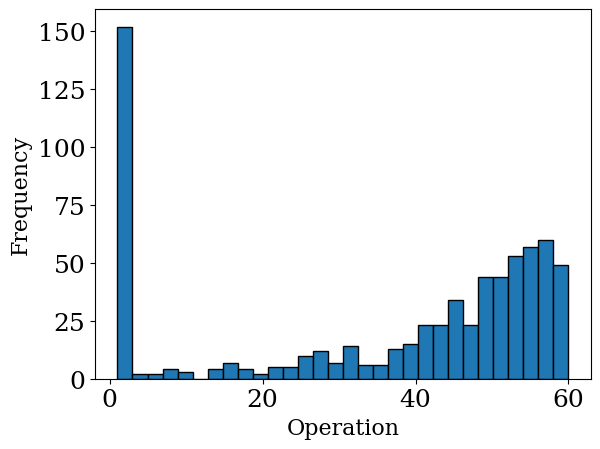

Skewness: -0.7110759282138528
Kurtosis: -1.1186466186033963


In [337]:
import matplotlib.pyplot as plt

# Plot the histogram for the 'Operation' column
plt.hist(data['Operation'], bins=30, edgecolor='black')
plt.xlabel('Operation')
plt.ylabel('Frequency')


# Save the figure as an SVG file
plt.savefig("hist_h2.svg", format="svg", dpi=900, bbox_inches='tight', facecolor='white')

# Show the plot
plt.show()

# Calculate skewness and kurtosis
skewness = data['Operation'].skew()
kurtosis = data['Operation'].kurt()

print("Skewness:", skewness)
print("Kurtosis:", kurtosis)


## PART I DECOMPOSITION

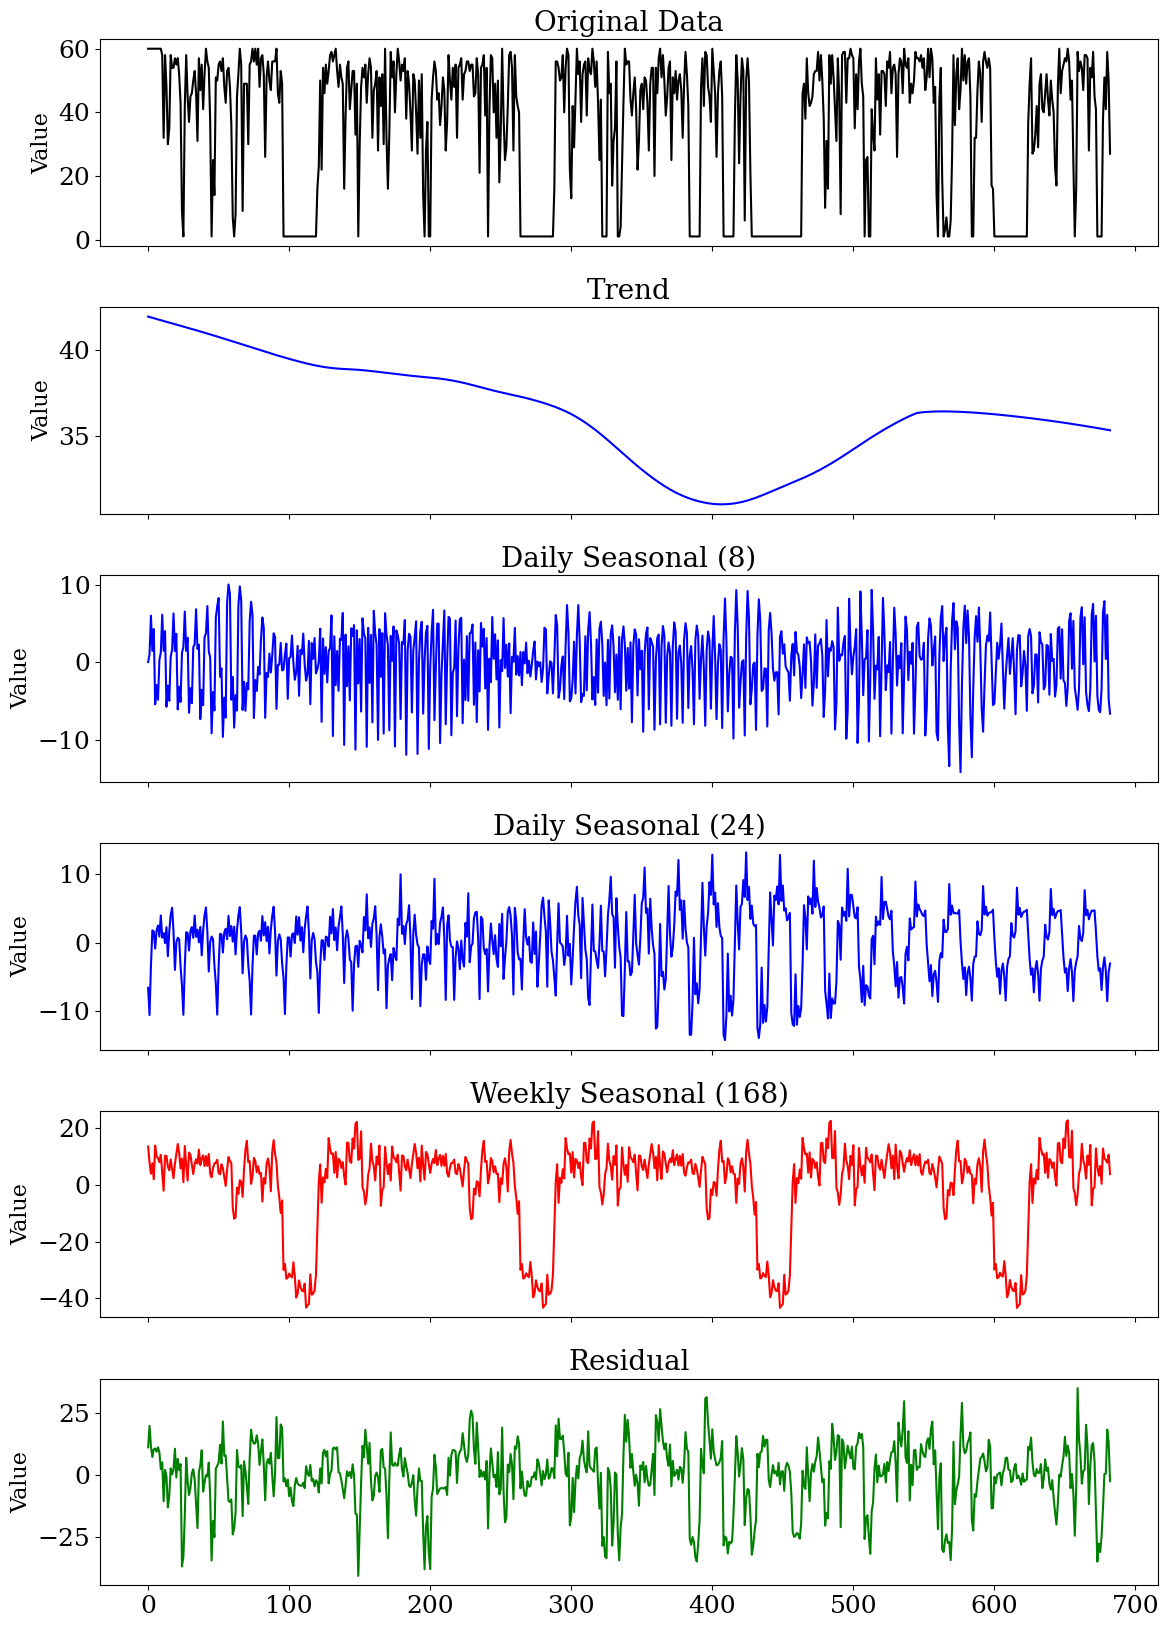

In [338]:
import pandas as pd
from statsmodels.tsa.seasonal import MSTL
import matplotlib.pyplot as plt

# Ensure the data is sorted by time
data = data.sort_index()

# MSTL decomposition
stl_kwargs = {"seasonal_deg": 0}
model = MSTL(data['Operation'], periods=(8, 24, 168), stl_kwargs=stl_kwargs)
res = model.fit()

# Extracting the seasonal components
seasonal_8=res.seasonal.iloc[:, 0]
seasonal_24 = res.seasonal.iloc[:, 1]  # Daily seasonal component
seasonal_168 = res.seasonal.iloc[:, 2]  # Weekly seasonal component
trend = res.trend
residual = res.resid

# Plotting
fig, axes = plt.subplots(6, 1, figsize=(12, 18), sharex=True)

data['Operation'].plot(ax=axes[0], color='black', title='Original Data')
axes[0].set_ylabel('Value')


trend.plot(ax=axes[1], color='blue', title='Trend')
axes[1].set_ylabel('Value')


seasonal_8.plot(ax=axes[2], color='blue', title='Daily Seasonal (8)')
axes[2].set_ylabel('Value')


seasonal_24.plot(ax=axes[3], color='blue', title='Daily Seasonal (24)')
axes[3].set_ylabel('Value')


seasonal_168.plot(ax=axes[4], color='red', title='Weekly Seasonal (168)')
axes[4].set_ylabel('Value')


residual.plot(ax=axes[5], color='green', title='Residual')
axes[5].set_ylabel('Value')

# Save the figure as an SVG file
plt.savefig("d_h2.svg", format="svg", dpi=900, bbox_inches='tight', facecolor='white')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [25]:
# Create DataFrames for each component
trend_df = pd.DataFrame({'Trend': trend})
seasonal_8_df = pd.DataFrame( {'Seasonal_8': seasonal_8})
seasonal_24_df = pd.DataFrame({ 'Seasonal_24': seasonal_24})
seasonal_168_df = pd.DataFrame({ 'Seasonal_168': seasonal_168})
residual_df = pd.DataFrame({ 'Operation': residual})

In [26]:
# Define the number of test samples
test_size = 4

# Divide each DataFrame into train and test sets
trend_train = trend_df.iloc[:-test_size]
trend_test = trend_df.iloc[-test_size:]

seasonal_8_train = seasonal_8_df.iloc[:-test_size]
seasonal_8_test = seasonal_8_df.iloc[-test_size:]

seasonal_24_train = seasonal_24_df.iloc[:-test_size]
seasonal_24_test = seasonal_24_df.iloc[-test_size:]

seasonal_168_train = seasonal_168_df.iloc[:-test_size]
seasonal_168_test = seasonal_168_df.iloc[-test_size:]

In [27]:
reference=data['Operation'].iloc[-test_size:]

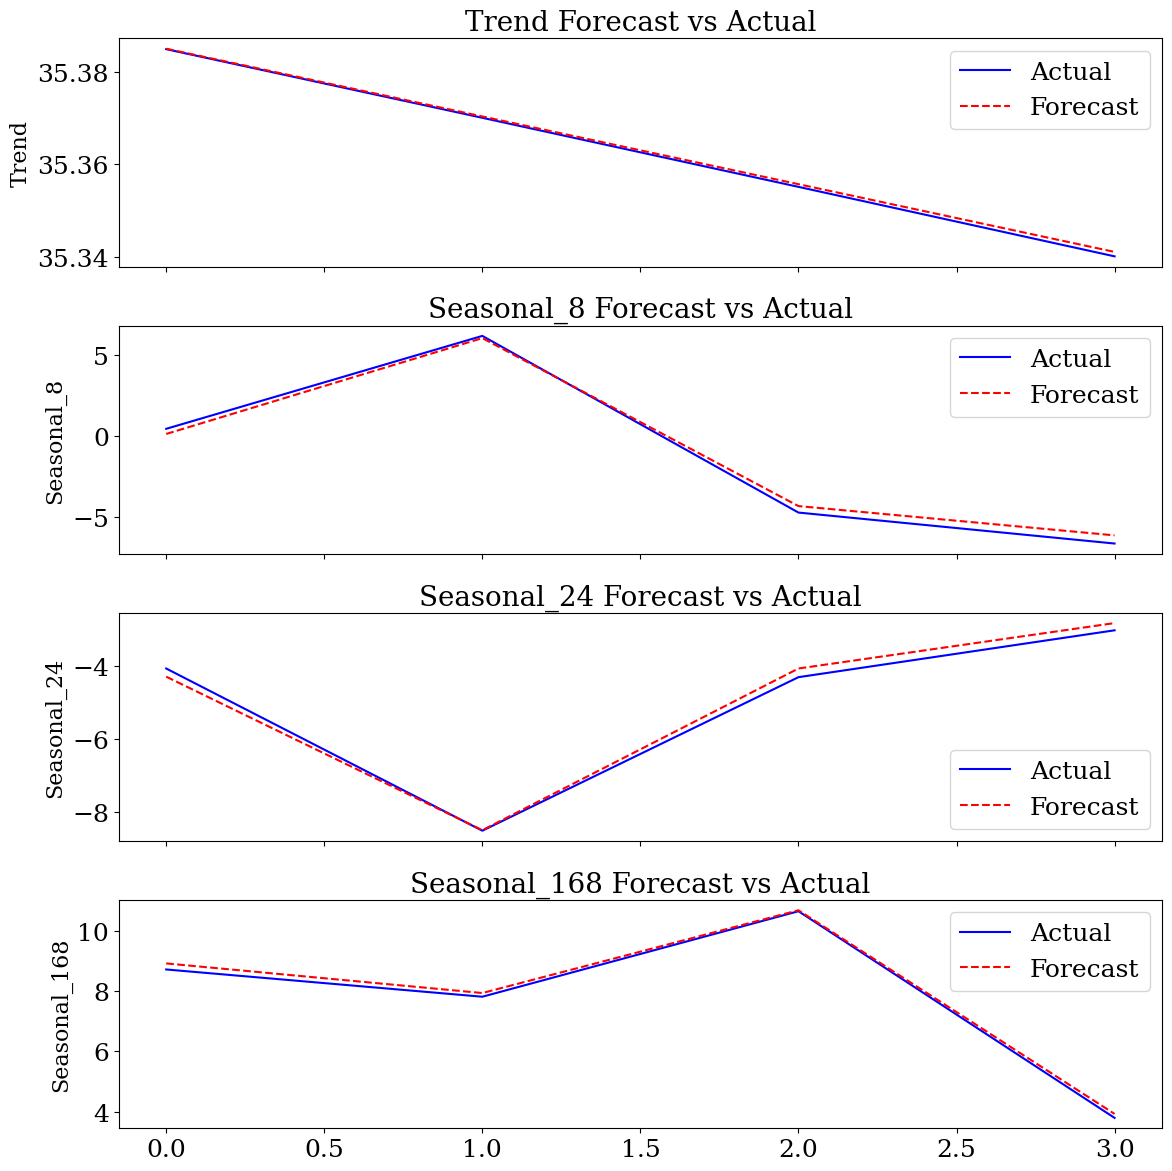

In [28]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing
# Initialize dictionaries to store results
mae_results = {}
mape_results = {}


# Define the ETS model (additive trend)
trend_model = ExponentialSmoothing(
    trend_train['Trend'], 
    trend='add',  # Use 'mul' for multiplicative trend if appropriate
    seasonal=None,  # No seasonality for pure trend modeling
    damped_trend=False  # Set to True if a damped trend is preferred
)

# Fit the model
fitted_trend_model = trend_model.fit()

# Forecast the next 20 data points
trend_forecast = np.array(fitted_trend_model.forecast(len(trend_test)))


# Calculate error metrics
mae_results['Trend'] = mean_absolute_error(trend_test['Trend'], trend_forecast)
mape_results['Trend'] = mean_absolute_percentage_error(trend_test['Trend'], trend_forecast)


# Forecast Seasonal (8) by repeating the last period's values
seasonal_8_forecast = np.tile(
    seasonal_8_train['Seasonal_8'][-8:].values,
    len(seasonal_8_test) // 8 + 1
)[:len(seasonal_8_test)]
mae_results['Seasonal_8'] = mean_absolute_error(seasonal_8_test['Seasonal_8'], seasonal_8_forecast)
mape_results['Seasonal_8'] = mean_absolute_percentage_error(seasonal_8_test['Seasonal_8'], seasonal_8_forecast)

# Forecast Seasonal (24) by repeating the last period's values
seasonal_24_forecast = np.tile(
    seasonal_24_train['Seasonal_24'][-24:].values,
    len(seasonal_24_test) // 24 + 1
)[:len(seasonal_24_test)]
mae_results['Seasonal_24'] = mean_absolute_error(seasonal_24_test['Seasonal_24'], seasonal_24_forecast)
mape_results['Seasonal_24'] = mean_absolute_percentage_error(seasonal_24_test['Seasonal_24'], seasonal_24_forecast)

# Forecast Seasonal (168) similarly
seasonal_168_forecast = np.tile(
    seasonal_168_train['Seasonal_168'][-168:].values,
    len(seasonal_168_test) // 168 + 1
)[:len(seasonal_168_test)]
mae_results['Seasonal_168'] = mean_absolute_error(seasonal_168_test['Seasonal_168'], seasonal_168_forecast)
mape_results['Seasonal_168'] = mean_absolute_percentage_error(seasonal_168_test['Seasonal_168'], seasonal_168_forecast)

# Plotting
fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)
components = ['Trend', 'Seasonal_8','Seasonal_24', 'Seasonal_168']
forecasts = [trend_forecast, seasonal_8_forecast, seasonal_24_forecast, seasonal_168_forecast]
test_data = [trend_test['Trend'],seasonal_8_test['Seasonal_8'], seasonal_24_test['Seasonal_24'], seasonal_168_test['Seasonal_168']]

for i, component in enumerate(components):
    axes[i].plot(test_data[i].values, label="Actual", color='blue')
    axes[i].plot(forecasts[i], label="Forecast", color='red', linestyle='dashed')
    axes[i].set_title(f'{component} Forecast vs Actual')
    axes[i].set_ylabel(component)
    axes[i].legend()

plt.tight_layout()
plt.show()



In [29]:
summed_up_array = np.sum(forecasts, axis=0)

In [30]:
import pandas as pd

# Assuming 'reference_df' is the reference DataFrame with the desired index
# and 'summed_up' is the array with values

summed_up = pd.DataFrame({
    'Index': reference.index,  # Use the index from the reference DataFrame
    'sum': summed_up_array  # Use the values from the array
})

# Set the index to match the reference DataFrame
summed_up.set_index('Index', inplace=True)

# Display the DataFrame
print(summed_up)

             sum
Index           
679    40.115999
680    40.819650
681    37.624510
682    30.303744


In [31]:
reference

679    41
680    59
681    50
682    27
Name: Operation, dtype: int64

In [32]:
file_path = 'summed_up.xlsx'
summed_up.to_excel(file_path, index=False)  # index=False to exclude the index column

In [33]:
file_path = 'reference.xlsx'
reference.to_excel(file_path, index=False)  # index=False to exclude the index column

## PART II FEATURE EXTRACTION

In [34]:
window_length = 24
window_size = 24
time_delay = 8
dimension = 3
stride = 1

In [35]:
df=residual_df

### STATISTICAL FEATURE EXTRACTION by TSFRESH

In [36]:
from tsfresh.feature_extraction import extract_features
from tsfresh.utilities.dataframe_functions import roll_time_series

In [37]:
start_time = time.time()

# Ensure tsfresh is installed
# !pip install tsfresh

# Add an index column to represent time
df['id'] = 1  # All data belongs to one time series
df['time'] = range(len(df))

# Rolling window to create overlapping segments
rolled_df = roll_time_series(df, column_id='id', column_sort='time', max_timeshift=window_size-1)

# Extract features using tsfresh
extracted_features = extract_features(
    rolled_df,
    column_id='id',
    column_sort='time',
    column_value='Operation',
    disable_progressbar=False
)


Feature Extraction: 100%|██████████| 30/30 [00:30<00:00,  1.02s/it]


In [38]:
extracted_features=extracted_features.reset_index(drop=True)

In [39]:
data = extracted_features.iloc[window_length-1:].reset_index(drop=True)

In [40]:
data

,Operation__variance_larger_than_standard_deviation,Operation__has_duplicate_max,Operation__has_duplicate_min,Operation__has_duplicate,Operation__sum_values,Operation__abs_energy,Operation__mean_abs_change,Operation__mean_change,Operation__mean_second_derivative_central,Operation__median,...,Operation__fourier_entropy__bins_5,Operation__fourier_entropy__bins_10,Operation__fourier_entropy__bins_100,Operation__permutation_entropy__dimension_3__tau_1,Operation__permutation_entropy__dimension_4__tau_1,Operation__permutation_entropy__dimension_5__tau_1,Operation__permutation_entropy__dimension_6__tau_1,Operation__permutation_entropy__dimension_7__tau_1,Operation__query_similarity_count__query_None__threshold_0.0,Operation__mean_n_absolute_max__number_of_maxima_7
0,1.0,0.0,0.0,0.0,104.090251,1777.781655,5.937577,-0.292738,-0.141319,4.713433,...,0.937156,1.377820,2.245035,1.668161,2.623522,2.995732,2.944439,2.890372,NaN,12.493484
1,1.0,0.0,0.0,0.0,56.375349,2996.712722,7.345895,-2.448066,-0.744117,3.514297,...,0.937156,1.412745,2.351673,1.656676,2.623522,2.995732,2.944439,2.890372,NaN,16.142931
2,1.0,0.0,0.0,0.0,3.945063,3682.514623,7.156088,-1.921282,0.184120,2.540164,...,1.031767,1.605207,2.458311,1.606466,2.648438,2.926418,2.944439,2.890372,NaN,18.011540
3,1.0,0.0,0.0,0.0,-23.732091,3815.606683,7.690275,-1.019614,0.306421,2.253440,...,1.031767,1.524707,2.204785,1.641230,2.648438,2.926418,2.944439,2.890372,NaN,18.698502
4,1.0,0.0,0.0,0.0,-24.048696,3811.142620,8.564392,-0.145497,0.517007,2.253440,...,1.031767,1.263626,2.351673,1.641230,2.648438,2.926418,2.944439,2.890372,NaN,18.698502
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
655,1.0,0.0,0.0,0.0,-70.624516,7115.503999,12.672339,0.000283,0.487154,0.409519,...,0.937156,1.377820,2.458311,1.620593,2.466577,2.787788,2.944439,2.890372,NaN,28.121152
656,1.0,0.0,0.0,0.0,-70.486881,7115.634776,12.334290,0.349735,0.385660,0.478337,...,1.031767,1.410514,2.458311,1.606466,2.359466,2.787788,2.944439,2.890372,NaN,28.121152
657,1.0,0.0,0.0,0.0,-44.806519,7389.910443,12.369009,1.848621,-0.036407,1.024297,...,1.178655,1.410514,2.311423,1.526775,2.306336,2.718473,2.944439,2.890372,NaN,28.121152
658,1.0,0.0,0.0,0.0,-7.423011,6967.763716,11.755810,0.788919,-1.023037,1.803817,...,1.072017,1.517152,2.311423,1.567236,2.306336,2.649159,2.944439,2.890372,NaN,27.241502


In [41]:
residual_df

,Operation,id,time
0,11.084386,1,0
1,19.675012,1,1
2,11.434210,1,2
3,7.208188,1,3
4,10.238015,1,4
...,...,...,...
678,0.412770,1,678
679,0.543904,1,679
680,18.180364,1,680
681,13.045591,1,681


In [42]:
df_ref = df.iloc[window_length-1:].reset_index(drop=True)

In [43]:
# Identify columns with inf, -inf, or NaN values
cols_with_invalid_values = data.columns[data.isin([np.inf, -np.inf]).any() | data.isna().any()]

# Replace inf and -inf with NaN first
data.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill NaN values with column mean
data[cols_with_invalid_values] = data[cols_with_invalid_values].apply(lambda col: col.fillna(col.mean()), axis=0)


In [44]:
df_ref = df_ref.drop(index=0).reset_index(drop=True)

In [45]:
regression_target_series = df_ref['Operation']

In [46]:
# Combine features and target into a single dataset for regression analysis
regression_dataset = data.copy()

In [47]:
regression_dataset['Target'] = regression_target_series

In [48]:
df1=regression_dataset

In [49]:
df1 = df1.drop(index=df1.index[-1]).reset_index(drop=True)

In [50]:
df1 = df1.dropna(axis=1, how='all').loc[:, ~(df1 == np.inf).all()]

In [51]:
# Dropping columns with low variance from df1
if 'df1' in locals():
    # Calculate variance of each column
    variance = df1.var()
    
    # Threshold for low variance (can be adjusted)
    low_variance_threshold = 0.01  # Example: close to zero variance
    
    # Identify columns with variance below the threshold
    low_variance_columns = variance[variance < low_variance_threshold].index
    
    # Drop low variance columns
    df1 = df1.drop(columns=low_variance_columns)

In [52]:
df1

,Operation__sum_values,Operation__abs_energy,Operation__mean_abs_change,Operation__mean_change,Operation__mean_second_derivative_central,Operation__median,Operation__mean,Operation__standard_deviation,Operation__variation_coefficient,Operation__variance,...,Operation__count_above__t_0,Operation__count_below__t_0,Operation__fourier_entropy__bins_2,Operation__fourier_entropy__bins_3,Operation__fourier_entropy__bins_5,Operation__fourier_entropy__bins_10,Operation__fourier_entropy__bins_100,Operation__permutation_entropy__dimension_4__tau_1,Operation__mean_n_absolute_max__number_of_maxima_7,Target
0,104.090251,1777.781655,5.937577,-0.292738,-0.141319,4.713433,4.337094,7.433966,1.714043,55.263853,...,0.791667,0.208333,0.429323,0.535961,0.937156,1.377820,2.245035,2.623522,12.493484,-36.630516
1,56.375349,2996.712722,7.345895,-2.448066,-0.744117,3.514297,2.348973,10.924530,4.650769,119.345356,...,0.750000,0.250000,0.429323,0.687092,0.937156,1.412745,2.351673,2.623522,16.142931,-32.755274
2,3.945063,3682.514623,7.156088,-1.921282,0.184120,2.540164,0.164378,12.385923,75.350410,153.411089,...,0.708333,0.291667,0.271189,0.687092,1.031767,1.605207,2.458311,2.648438,18.011540,-16.242944
3,-23.732091,3815.606683,7.690275,-1.019614,0.306421,2.253440,-0.988837,12.570036,-12.711938,158.005813,...,0.666667,0.333333,0.271189,0.687092,1.031767,1.524707,2.204785,2.648438,18.698502,6.891582
4,-24.048696,3811.142620,8.564392,-0.145497,0.517007,2.253440,-1.002029,12.561590,-12.536154,157.793547,...,0.666667,0.333333,0.271189,0.535961,1.031767,1.263626,2.351673,2.648438,18.698502,-2.448256
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
654,-76.312552,7143.162051,12.331165,-0.340891,0.129531,-1.534871,-3.179690,16.956454,-5.332739,287.521326,...,0.500000,0.500000,0.540204,0.790268,0.937156,1.377820,2.351673,2.491494,28.121152,0.412770
655,-70.624516,7115.503999,12.672339,0.000283,0.487154,0.409519,-2.942688,16.965256,-5.765224,287.819920,...,0.541667,0.458333,0.540204,0.687092,0.937156,1.377820,2.458311,2.466577,28.121152,0.543904
656,-70.486881,7115.634776,12.334290,0.349735,0.385660,0.478337,-2.936953,16.966411,-5.776874,287.859087,...,0.541667,0.458333,0.429323,0.790268,1.031767,1.410514,2.458311,2.359466,28.121152,18.180364
657,-44.806519,7389.910443,12.369009,1.848621,-0.036407,1.024297,-1.866938,17.447850,-9.345703,304.427477,...,0.583333,0.416667,0.429323,0.830518,1.178655,1.410514,2.311423,2.306336,28.121152,13.045591


In [53]:
from sklearn.ensemble import RandomForestRegressor
from feature_engine.selection import SmartCorrelatedSelection

In [54]:
# Assume the last column is the target variable (modify if needed)
target_column = "Target"  # Change if your target column has a different name
X = df1.drop(columns=[target_column])  # Extract feature columns
y = df1[target_column]  # Define the target variable

# Initialize SmartCorrelatedSelection for regression
tr = SmartCorrelatedSelection(
    variables=None,  # Apply to all numeric features
    method="pearson",  # Pearson correlation method
    threshold=0.9,  # Correlation threshold
    missing_values="raise",  # Raise error if missing values exist
    selection_method="model_performance",  # Use model performance to select features
    estimator=RandomForestRegressor(random_state=1, n_estimators=100),  # RandomForest for regression
    scoring="r2",  # Use R² as the evaluation metric
    cv=3  # 3-fold cross-validation
)

# Fit and transform the dataset to select best features
X_selected = tr.fit_transform(X, y)

# Reconstruct df2 with selected features and target variable
df1 = pd.concat([X_selected, y], axis=1)

In [55]:
from sklearn.preprocessing import MinMaxScaler

# Separate features and target
features = df1.drop(columns=["Target"])
target = df1["Target"]

# Apply scaling only to features
scaler = MinMaxScaler()
features_scaled = pd.DataFrame(scaler.fit_transform(features), columns=features.columns, index=features.index)

# Recombine scaled features with the original Target
df1_scaled = pd.concat([features_scaled, target], axis=1)

In [56]:
end_time = time.time()
statistical_ext=start_time-end_time

In [57]:
file_path = 'statistical_data.xlsx'
df1_scaled.to_excel(file_path, index=False)  # index=False to exclude the index column

### TOPOLOGICAL FEATURE EXTRACTION

In [58]:
import pandas as pd
import numpy as np
from gtda.diagrams import (
    Scaler, PersistenceEntropy, Amplitude, BettiCurve, 
    PersistenceLandscape, Silhouette, HeatKernel
)
import gtda.time_series as ts
import gtda.diagrams as diag
from gtda.time_series import TakensEmbedding
from gtda.time_series import SlidingWindow
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
from gtda.pipeline import Pipeline
from gtda.homology import VietorisRipsPersistence
from gtda.plotting import plot_point_cloud

In [59]:
start_time = time.time()

In [60]:
X=df['Operation']

In [61]:
import numpy as np
import pandas as pd
from gtda.time_series import SlidingWindow, TakensEmbedding
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import Scaler

# Load your data (replace 'df' with your actual DataFrame)
X = df['Operation'].to_numpy()

# Sliding Window
SW = SlidingWindow(size=window_size, stride=stride)
X_sw = SW.fit_transform(X)

# Debugging shape
print(f"Sliding Window Output Shape: {X_sw.shape}")

# Takens Embedding
TE = TakensEmbedding(time_delay=time_delay, dimension=dimension)
X_te = TE.fit_transform(X_sw)

# Debugging shape
print(f"Takens Embedding Output Shape: {X_te.shape}")

# Vietoris-Rips Persistence
VR = VietorisRipsPersistence(homology_dimensions=[0, 1])
diagrams = VR.fit_transform(X_te)

# Debugging number of diagrams
print(f"Number of Persistence Diagrams: {len(diagrams)}")

# Scaling Persistence Diagrams
scaler = Scaler()
scaled_diagrams = scaler.fit_transform(diagrams)

# Debugging scaled diagrams shape
print(f"Scaled Diagrams Shape: {scaled_diagrams.shape}")


Sliding Window Output Shape: (660, 24)
Takens Embedding Output Shape: (660, 8, 3)
Number of Persistence Diagrams: 660
Scaled Diagrams Shape: (660, 9, 3)


In [62]:
# Initialize feature extractors
persistence_entropy = PersistenceEntropy()
amplitude_bottleneck = Amplitude(metric='bottleneck')
amplitude_wasserstein = Amplitude(metric='wasserstein')
amplitude_landscape = Amplitude(metric='landscape')
betti_curve = BettiCurve()
persistence_landscape = PersistenceLandscape()
silhouette = Silhouette()
heat_kernel = HeatKernel(sigma=0.1, n_bins=100, n_jobs=-1)

In [63]:
# Extract features
entropy_features = persistence_entropy.fit_transform(scaled_diagrams)
amplitude_bottleneck_features = amplitude_bottleneck.fit_transform(scaled_diagrams)
amplitude_wasserstein_features = amplitude_wasserstein.fit_transform(scaled_diagrams)
amplitude_landscape_features = amplitude_landscape.fit_transform(scaled_diagrams)
betti_features = betti_curve.fit_transform(scaled_diagrams)
landscape_features = persistence_landscape.fit_transform(scaled_diagrams)
silhouette_features = silhouette.fit_transform(scaled_diagrams)
heat_kernel_features = heat_kernel.fit_transform(scaled_diagrams)

In [64]:
betti_features.shape

(660, 2, 100)

In [65]:
l1_h0 = []
l2_h0 = []
l1_h1 = []
l2_h1 = []

for i in range(betti_features.shape[0]):
    h0_curve = betti_features[i, 0, :]
    h1_curve = betti_features[i, 1, :]

    l1_h0.append(np.sum(np.abs(h0_curve)))
    l2_h0.append(np.sqrt(np.sum(h0_curve**2)))

    l1_h1.append(np.sum(np.abs(h1_curve)))
    l2_h1.append(np.sqrt(np.sum(h1_curve**2)))

# Create DataFrame
betti_df = pd.DataFrame({
    'betti_L1_H0': l1_h0,
    'betti_L2_H0': l2_h0,
    'betti_L1_H1': l1_h1,
    'betti_L2_H1': l2_h1
})

# Show result
betti_df


,betti_L1_H0,betti_L2_H0,betti_L1_H1,betti_L2_H1
0,92,23.323808,0,0.0
1,154,26.038433,0,0.0
2,146,25.768197,0,0.0
3,140,27.892651,0,0.0
4,172,29.799329,0,0.0
...,...,...,...,...
655,257,39.761791,0,0.0
656,246,38.183766,0,0.0
657,270,39.673669,0,0.0
658,280,40.224371,0,0.0


In [66]:
l1_h0_ls = []
l2_h0_ls = []
l1_h1_ls = []
l2_h1_ls = []

for i in range(landscape_features.shape[0]):
    h0_landscape = landscape_features[i, 0, :]
    h1_landscape = landscape_features[i, 1, :]

    l1_h0_ls.append(np.sum(np.abs(h0_landscape)))
    l2_h0_ls.append(np.sqrt(np.sum(h0_landscape**2)))

    l1_h1_ls.append(np.sum(np.abs(h1_landscape)))
    l2_h1_ls.append(np.sqrt(np.sum(h1_landscape**2)))

# Create DataFrame
landscape_df = pd.DataFrame({
    'landscape_features_L1_H0_LS': l1_h0_ls,
    'landscape_features_L2_H0_LS': l2_h0_ls,
    'landscape_features_L1_H1_LS': l1_h1_ls,
    'landscape_features_L2_H1_LS': l2_h1_ls
})

# Show result
landscape_df


,landscape_features_L1_H0_LS,landscape_features_L2_H0_LS,landscape_features_L1_H1_LS,landscape_features_L2_H1_LS
0,1.513497,0.420032,0.0,0.0
1,24.462327,3.386027,0.0,0.0
2,20.644626,2.981912,0.0,0.0
3,5.458578,1.099405,0.0,0.0
4,10.916436,1.848746,0.0,0.0
...,...,...,...,...
655,13.395804,2.155462,0.0,0.0
656,13.395804,2.155462,0.0,0.0
657,14.054394,2.234423,0.0,0.0
658,14.241323,2.256748,0.0,0.0


In [67]:
l1_h0_si = []
l2_h0_si = []
l1_h1_si = []
l2_h1_si = []

for i in range(silhouette_features.shape[0]):
    h0_silhouette = silhouette_features[i, 0, :]
    h1_silhouette = silhouette_features[i, 1, :]

    l1_h0_si.append(np.sum(np.abs(h0_silhouette)))
    l2_h0_si.append(np.sqrt(np.sum(h0_silhouette**2)))

    l1_h1_si.append(np.sum(np.abs(h1_silhouette)))
    l2_h1_si.append(np.sqrt(np.sum(h1_silhouette**2)))

# Create DataFrame
silhouette_df = pd.DataFrame({
    'silhouette_features_L1_H0_SI': l1_h0_si,
    'silhouette_features_L2_H0_SI': l2_h0_si,
    'silhouette_features_L1_H1_SI': l1_h1_si,
    'silhouette_features_L2_H1_SI': l2_h1_si
})

# Show result
silhouette_df.head()


,silhouette_features_L1_H0_SI,silhouette_features_L2_H0_SI,silhouette_features_L1_H1_SI,silhouette_features_L2_H1_SI
0,1.001876,0.286144,0.0,0.0
1,11.831305,1.592521,0.0,0.0
2,9.727442,1.361798,0.0,0.0
3,3.047797,0.604552,0.0,0.0
4,5.385877,0.922545,0.0,0.0


In [68]:
# Flatten entropy features
entropy_flattened = entropy_features.reshape(entropy_features.shape[0], -1)
entropy_df = pd.DataFrame(entropy_flattened, columns=[f"entropy_{i}" for i in range(entropy_flattened.shape[1])])

In [69]:
entropy_df

,entropy_0,entropy_1
0,2.752234,-1.0
1,2.371039,-1.0
2,2.410209,-1.0
3,2.691061,-1.0
4,2.633835,-1.0
...,...,...
655,2.771606,-1.0
656,2.745287,-1.0
657,2.734335,-1.0
658,2.725553,-1.0


In [70]:
# Flatten amplitude bottleneck features
amplitude_bottleneck_flattened = amplitude_bottleneck_features.reshape(amplitude_bottleneck_features.shape[0], -1)
amplitude_bottleneck_df = pd.DataFrame(amplitude_bottleneck_flattened, columns=[f"amplitude_bottleneck_{i}" for i in range(amplitude_bottleneck_flattened.shape[1])])
amplitude_bottleneck_df 

,amplitude_bottleneck_0,amplitude_bottleneck_1
0,0.174992,0.0
1,0.702997,0.0
2,0.645805,0.0
3,0.332197,0.0
4,0.469637,0.0
...,...,...
655,0.520238,0.0
656,0.520238,0.0
657,0.532903,0.0
658,0.536455,0.0


In [71]:
# Flatten amplitude wasserstein features
amplitude_wasserstein_flattened = amplitude_wasserstein_features.reshape(amplitude_wasserstein_features.shape[0], -1)
amplitude_wasserstein_df = pd.DataFrame(amplitude_wasserstein_flattened, columns=[f"amplitude_wasserstein_{i}" for i in range(amplitude_wasserstein_flattened.shape[1])])
amplitude_wasserstein_df


,amplitude_wasserstein_0,amplitude_wasserstein_1
0,0.353751,0.0
1,0.783087,0.0
2,0.728378,0.0
3,0.566809,0.0
4,0.720698,0.0
...,...,...
655,0.987328,0.0
656,0.959297,0.0
657,1.059080,0.0
658,1.103921,0.0


In [72]:
amplitude_landscape_flattened = amplitude_landscape_features.reshape(amplitude_landscape_features.shape[0], -1)
amplitude_landscape_df = pd.DataFrame(amplitude_landscape_flattened, columns=[f"amplitude_landscape_{i}" for i in range(amplitude_landscape_flattened.shape[1])])
amplitude_landscape_df 

,amplitude_landscape_0,amplitude_landscape_1
0,0.059701,0.0
1,0.481269,0.0
2,0.423831,0.0
3,0.156263,0.0
4,0.262769,0.0
...,...,...
655,0.306364,0.0
656,0.306364,0.0
657,0.317587,0.0
658,0.320760,0.0


In [73]:
heat_kernel_features.shape

(660, 2, 100, 100)

In [74]:
def compute_entropy(matrix):
    p = matrix.flatten()
    p = p[p > 0]  # Avoid log(0)
    p /= p.sum()  # Normalize to probability distribution
    return -np.sum(p * np.log(p))

def extract_heat_kernel_features(heat_kernel_features):
    feature_list = []

    for i in range(heat_kernel_features.shape[0]):  # for each sample
        features_sample = {}

        for dim, h_dim in enumerate(["H0", "H1"]):
            matrix = heat_kernel_features[i, dim, :, :]  # shape: (100, 100)

            # Global features
            features_sample[f"L1_{h_dim}"] = np.sum(np.abs(matrix))
            features_sample[f"L2_{h_dim}"] = np.sqrt(np.sum(matrix ** 2))

            # Per-column features
            for col in range(matrix.shape[1]):
                col_data = matrix[:, col]
                features_sample[f"Col{col}_L1_{h_dim}"] = np.sum(np.abs(col_data))
                features_sample[f"Col{col}_L2_{h_dim}"] = np.sqrt(np.sum(col_data ** 2))

        feature_list.append(features_sample)

    heat_kernel_df = pd.DataFrame(feature_list)
    return heat_kernel_df

# Usage
heat_kernel_df = extract_heat_kernel_features(heat_kernel_features)
heat_kernel_df.head()


,L1_H0,L2_H0,Col0_L1_H0,Col0_L2_H0,Col1_L1_H0,Col1_L2_H0,Col2_L1_H0,Col2_L2_H0,Col3_L1_H0,Col3_L2_H0,...,Col95_L1_H1,Col95_L2_H1,Col96_L1_H1,Col96_L2_H1,Col97_L1_H1,Col97_L2_H1,Col98_L1_H1,Col98_L2_H1,Col99_L1_H1,Col99_L2_H1
0,14780.739950,851.996935,1268.589474,284.834922,1218.329991,275.937312,1126.531241,256.049982,1008.878076,228.109502,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,16073.272180,784.559677,1320.588933,258.566537,1278.203424,251.667525,1189.365851,234.723309,1068.188481,209.994609,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,15991.950396,796.035382,1319.670733,262.794423,1276.877467,255.715700,1187.704520,238.401996,1066.472170,213.167947,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,17207.921636,766.832634,1359.770202,248.679958,1324.843626,243.104098,1239.545064,227.925182,1116.101930,204.960178,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,17426.365951,660.953043,1362.052098,214.005313,1328.115302,209.235764,1243.628981,196.224079,1120.318054,176.533461,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [75]:
# Combine all the DataFrames into a single DataFrame
combined_df = pd.concat([
    entropy_df,
    amplitude_bottleneck_df,
    amplitude_wasserstein_df,
    amplitude_landscape_df,
    betti_df,
    landscape_df,
    silhouette_df,
    heat_kernel_df
], axis=1)


In [76]:
def compute_carlsson_features(births, deaths, fn_max=5):
    lifetimes = deaths - births
    d_max = np.max(deaths) if len(deaths) > 0 else 0
    
    f1 = np.sum(births * lifetimes) if fn_max >= 1 else None
    f2 = np.sum((d_max - deaths) * lifetimes) if fn_max >= 2 else None
    f3 = np.sum((births ** 2) * (lifetimes ** 4)) if fn_max >= 3 else None
    f4 = np.sum(((d_max - deaths) ** 2) * (lifetimes ** 4)) if fn_max >= 4 else None
    f5 = np.max(lifetimes) if (fn_max >= 5 and len(lifetimes) > 0) else None

    return f1, f2, f3, f4, f5

features = {}
fn_max = 5  # You can adjust the number of Carlsson features

for dim in range(2):  # Loop over each homology dimension (0 and 1)
    filtered_diagrams = [diagram[diagram[:, 2] == dim] for diagram in scaled_diagrams]

    lifetimes = [diagram[:, 1] - diagram[:, 0] for diagram in filtered_diagrams]

    for i, lifetime in enumerate(lifetimes):
        sample_key = f'sample_{i + 1}'
        if sample_key not in features:
            features[sample_key] = {}

        features[sample_key][f'dim_{dim}_num_features'] = len(lifetime)
        features[sample_key][f'dim_{dim}_sum_lifetimes'] = np.sum(lifetime)

        if len(lifetime) > 0:
            features[sample_key][f'dim_{dim}_max_lifetime'] = np.max(lifetime)
            features[sample_key][f'dim_{dim}_mean_lifetime'] = np.mean(lifetime)
            features[sample_key][f'dim_{dim}_median_lifetime'] = np.median(lifetime)
            features[sample_key][f'dim_{dim}_std_lifetime'] = np.std(lifetime)
            features[sample_key][f'dim_{dim}_variance_lifetime'] = np.var(lifetime)
            features[sample_key][f'dim_{dim}_min_lifetime'] = np.min(lifetime)

            birth_times = filtered_diagrams[i][:, 0]
            death_times = filtered_diagrams[i][:, 1]

            features[sample_key][f'dim_{dim}_sum_birth_times'] = np.sum(birth_times)
            features[sample_key][f'dim_{dim}_mean_birth_time'] = np.mean(birth_times)
            features[sample_key][f'dim_{dim}_sum_death_times'] = np.sum(death_times)
            features[sample_key][f'dim_{dim}_mean_death_time'] = np.mean(death_times)

            # Add Carlsson features:
            f1, f2, f3, f4, f5 = compute_carlsson_features(birth_times, death_times, fn_max=fn_max)
            if f1 is not None:
                features[sample_key][f'dim_{dim}_carlsson_f1'] = f1
            if f2 is not None:
                features[sample_key][f'dim_{dim}_carlsson_f2'] = f2
            if f3 is not None:
                features[sample_key][f'dim_{dim}_carlsson_f3'] = f3
            if f4 is not None:
                features[sample_key][f'dim_{dim}_carlsson_f4'] = f4
            if f5 is not None:
                features[sample_key][f'dim_{dim}_carlsson_f5'] = f5

        else:
            # Fill zeros if empty diagram
            for metric in ['max_lifetime', 'mean_lifetime', 'median_lifetime', 'std_lifetime', 'variance_lifetime', 'min_lifetime', 'sum_birth_times', 'mean_birth_time', 'sum_death_times', 'mean_death_time']:
                features[sample_key][f'dim_{dim}_{metric}'] = 0

            # Add Carlsson feature zeros if empty
            for j in range(1, fn_max + 1):
                features[sample_key][f'dim_{dim}_carlsson_f{j}'] = 0

# Convert the nested dictionary to a DataFrame
features_df = pd.DataFrame.from_dict(features, orient='index')
features_df.reset_index(inplace=True)
features_df.rename(columns={'index': 'sample'}, inplace=True)
features_df.drop(columns=['sample'], inplace=True)

In [77]:
features_df.columns

Index(['dim_0_num_features', 'dim_0_sum_lifetimes', 'dim_0_max_lifetime',
       'dim_0_mean_lifetime', 'dim_0_median_lifetime', 'dim_0_std_lifetime',
       'dim_0_variance_lifetime', 'dim_0_min_lifetime',
       'dim_0_sum_birth_times', 'dim_0_mean_birth_time',
       'dim_0_sum_death_times', 'dim_0_mean_death_time', 'dim_0_carlsson_f1',
       'dim_0_carlsson_f2', 'dim_0_carlsson_f3', 'dim_0_carlsson_f4',
       'dim_0_carlsson_f5', 'dim_1_num_features', 'dim_1_sum_lifetimes',
       'dim_1_max_lifetime', 'dim_1_mean_lifetime', 'dim_1_median_lifetime',
       'dim_1_std_lifetime', 'dim_1_variance_lifetime', 'dim_1_min_lifetime',
       'dim_1_sum_birth_times', 'dim_1_mean_birth_time',
       'dim_1_sum_death_times', 'dim_1_mean_death_time', 'dim_1_carlsson_f1',
       'dim_1_carlsson_f2', 'dim_1_carlsson_f3', 'dim_1_carlsson_f4',
       'dim_1_carlsson_f5'],
      dtype='object')

In [78]:
features_df

,dim_0_num_features,dim_0_sum_lifetimes,dim_0_max_lifetime,dim_0_mean_lifetime,dim_0_median_lifetime,dim_0_std_lifetime,dim_0_variance_lifetime,dim_0_min_lifetime,dim_0_sum_birth_times,dim_0_mean_birth_time,...,dim_1_min_lifetime,dim_1_sum_birth_times,dim_1_mean_birth_time,dim_1_sum_death_times,dim_1_mean_death_time,dim_1_carlsson_f1,dim_1_carlsson_f2,dim_1_carlsson_f3,dim_1_carlsson_f4,dim_1_carlsson_f5
0,7,1.806457,0.349985,0.258065,0.279603,0.070077,0.004911,0.156458,0.0,0.0,...,0.0,0.434822,0.217411,0.434822,0.217411,0.0,0.0,0.0,0.0,0.0
1,7,3.055994,1.405994,0.436571,0.299501,0.399776,0.159821,0.178496,0.0,0.0,...,0.0,0.434822,0.217411,0.434822,0.217411,0.0,0.0,0.0,0.0,0.0
2,7,2.908317,1.291609,0.415474,0.299501,0.361309,0.130544,0.178496,0.0,0.0,...,0.0,0.434822,0.217411,0.434822,0.217411,0.0,0.0,0.0,0.0,0.0
3,7,2.769947,0.664393,0.395707,0.316692,0.164318,0.027001,0.213134,0.0,0.0,...,0.0,0.434822,0.217411,0.434822,0.217411,0.0,0.0,0.0,0.0,0.0
4,7,3.409720,0.939274,0.487103,0.329281,0.243997,0.059534,0.213134,0.0,0.0,...,0.0,0.434822,0.217411,0.434822,0.217411,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
655,7,5.095625,1.040476,0.727946,0.702121,0.164718,0.027132,0.511816,0.0,0.0,...,0.0,0.434822,0.217411,0.434822,0.217411,0.0,0.0,0.0,0.0,0.0
656,7,4.876903,1.040476,0.696700,0.649136,0.201163,0.040466,0.352041,0.0,0.0,...,0.0,0.434822,0.217411,0.434822,0.217411,0.0,0.0,0.0,0.0,0.0
657,7,5.356872,1.065806,0.765267,0.768992,0.235178,0.055308,0.352041,0.0,0.0,...,0.0,0.434822,0.217411,0.434822,0.217411,0.0,0.0,0.0,0.0,0.0
658,7,5.556186,1.072911,0.793741,0.768992,0.257569,0.066342,0.352041,0.0,0.0,...,0.0,0.434822,0.217411,0.434822,0.217411,0.0,0.0,0.0,0.0,0.0


In [79]:
features_df.reset_index(drop=True, inplace=True)

In [80]:
features_df

,dim_0_num_features,dim_0_sum_lifetimes,dim_0_max_lifetime,dim_0_mean_lifetime,dim_0_median_lifetime,dim_0_std_lifetime,dim_0_variance_lifetime,dim_0_min_lifetime,dim_0_sum_birth_times,dim_0_mean_birth_time,...,dim_1_min_lifetime,dim_1_sum_birth_times,dim_1_mean_birth_time,dim_1_sum_death_times,dim_1_mean_death_time,dim_1_carlsson_f1,dim_1_carlsson_f2,dim_1_carlsson_f3,dim_1_carlsson_f4,dim_1_carlsson_f5
0,7,1.806457,0.349985,0.258065,0.279603,0.070077,0.004911,0.156458,0.0,0.0,...,0.0,0.434822,0.217411,0.434822,0.217411,0.0,0.0,0.0,0.0,0.0
1,7,3.055994,1.405994,0.436571,0.299501,0.399776,0.159821,0.178496,0.0,0.0,...,0.0,0.434822,0.217411,0.434822,0.217411,0.0,0.0,0.0,0.0,0.0
2,7,2.908317,1.291609,0.415474,0.299501,0.361309,0.130544,0.178496,0.0,0.0,...,0.0,0.434822,0.217411,0.434822,0.217411,0.0,0.0,0.0,0.0,0.0
3,7,2.769947,0.664393,0.395707,0.316692,0.164318,0.027001,0.213134,0.0,0.0,...,0.0,0.434822,0.217411,0.434822,0.217411,0.0,0.0,0.0,0.0,0.0
4,7,3.409720,0.939274,0.487103,0.329281,0.243997,0.059534,0.213134,0.0,0.0,...,0.0,0.434822,0.217411,0.434822,0.217411,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
655,7,5.095625,1.040476,0.727946,0.702121,0.164718,0.027132,0.511816,0.0,0.0,...,0.0,0.434822,0.217411,0.434822,0.217411,0.0,0.0,0.0,0.0,0.0
656,7,4.876903,1.040476,0.696700,0.649136,0.201163,0.040466,0.352041,0.0,0.0,...,0.0,0.434822,0.217411,0.434822,0.217411,0.0,0.0,0.0,0.0,0.0
657,7,5.356872,1.065806,0.765267,0.768992,0.235178,0.055308,0.352041,0.0,0.0,...,0.0,0.434822,0.217411,0.434822,0.217411,0.0,0.0,0.0,0.0,0.0
658,7,5.556186,1.072911,0.793741,0.768992,0.257569,0.066342,0.352041,0.0,0.0,...,0.0,0.434822,0.217411,0.434822,0.217411,0.0,0.0,0.0,0.0,0.0


In [81]:
final_combined_df = pd.concat([combined_df.reset_index(drop=True), features_df], axis=1)

In [82]:
final_combined_df

,entropy_0,entropy_1,amplitude_bottleneck_0,amplitude_bottleneck_1,amplitude_wasserstein_0,amplitude_wasserstein_1,amplitude_landscape_0,amplitude_landscape_1,betti_L1_H0,betti_L2_H0,...,dim_1_min_lifetime,dim_1_sum_birth_times,dim_1_mean_birth_time,dim_1_sum_death_times,dim_1_mean_death_time,dim_1_carlsson_f1,dim_1_carlsson_f2,dim_1_carlsson_f3,dim_1_carlsson_f4,dim_1_carlsson_f5
0,2.752234,-1.0,0.174992,0.0,0.353751,0.0,0.059701,0.0,92,23.323808,...,0.0,0.434822,0.217411,0.434822,0.217411,0.0,0.0,0.0,0.0,0.0
1,2.371039,-1.0,0.702997,0.0,0.783087,0.0,0.481269,0.0,154,26.038433,...,0.0,0.434822,0.217411,0.434822,0.217411,0.0,0.0,0.0,0.0,0.0
2,2.410209,-1.0,0.645805,0.0,0.728378,0.0,0.423831,0.0,146,25.768197,...,0.0,0.434822,0.217411,0.434822,0.217411,0.0,0.0,0.0,0.0,0.0
3,2.691061,-1.0,0.332197,0.0,0.566809,0.0,0.156263,0.0,140,27.892651,...,0.0,0.434822,0.217411,0.434822,0.217411,0.0,0.0,0.0,0.0,0.0
4,2.633835,-1.0,0.469637,0.0,0.720698,0.0,0.262769,0.0,172,29.799329,...,0.0,0.434822,0.217411,0.434822,0.217411,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
655,2.771606,-1.0,0.520238,0.0,0.987328,0.0,0.306364,0.0,257,39.761791,...,0.0,0.434822,0.217411,0.434822,0.217411,0.0,0.0,0.0,0.0,0.0
656,2.745287,-1.0,0.520238,0.0,0.959297,0.0,0.306364,0.0,246,38.183766,...,0.0,0.434822,0.217411,0.434822,0.217411,0.0,0.0,0.0,0.0,0.0
657,2.734335,-1.0,0.532903,0.0,1.059080,0.0,0.317587,0.0,270,39.673669,...,0.0,0.434822,0.217411,0.434822,0.217411,0.0,0.0,0.0,0.0,0.0
658,2.725553,-1.0,0.536455,0.0,1.103921,0.0,0.320760,0.0,280,40.224371,...,0.0,0.434822,0.217411,0.434822,0.217411,0.0,0.0,0.0,0.0,0.0


In [83]:
final_combined_df = final_combined_df.loc[:, ~final_combined_df.isin([np.inf, -np.inf]).any() & final_combined_df.notna().all()]

In [84]:
# Dropping columns with low variance from final_combined_df
if 'final_combined_df' in locals():
    # Calculate variance of each column
    variance = final_combined_df.var()
    
    # Threshold for low variance (can be adjusted)
    low_variance_threshold = 0.01  # Example: close to zero variance
    
    # Identify columns with variance below the threshold
    low_variance_columns = variance[variance < low_variance_threshold].index
    
    # Drop low variance columns
    final_combined_df_cleaned = final_combined_df.drop(columns=low_variance_columns)

In [85]:
data=final_combined_df_cleaned

In [86]:
# Identify columns with inf, -inf, or NaN values
cols_with_invalid_values = data.columns[data.isin([np.inf, -np.inf]).any() | data.isna().any()]

# Replace inf and -inf with NaN first
data.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill NaN values with column mean
data[cols_with_invalid_values] = data[cols_with_invalid_values].apply(lambda col: col.fillna(col.mean()), axis=0)

In [87]:
simplified_df=data

In [88]:
# Adjust the indices of the feature dataset for regression analysis
regression_features_df = simplified_df[:-1].reset_index(drop=True)
regression_target_series = df['Operation'][window_size:].reset_index(drop=True)

# Combine features and target into a single dataset for regression analysis
regression_dataset = regression_features_df.copy()
regression_dataset['Target'] = regression_target_series

In [89]:
df2=regression_dataset

In [90]:
df2

,entropy_0,entropy_1,amplitude_bottleneck_0,amplitude_wasserstein_0,amplitude_landscape_0,betti_L1_H0,betti_L2_H0,betti_L1_H1,betti_L2_H1,landscape_features_L1_H0_LS,...,dim_0_sum_death_times,dim_0_mean_death_time,dim_0_carlsson_f2,dim_0_carlsson_f4,dim_0_carlsson_f5,dim_1_sum_birth_times,dim_1_mean_birth_time,dim_1_sum_death_times,dim_1_mean_death_time,Target
0,2.752234,-1.0,0.174992,0.353751,0.059701,92,23.323808,0,0.0,1.513497,...,1.806457,0.258065,0.131672,0.000147,0.349985,0.434822,0.217411,0.434822,0.217411,-36.630516
1,2.371039,-1.0,0.702997,0.783087,0.481269,154,26.038433,0,0.0,24.462327,...,3.055994,0.436571,1.843809,0.052432,1.405994,0.434822,0.217411,0.434822,0.217411,-32.755274
2,2.410209,-1.0,0.645805,0.728378,0.423831,146,25.768197,0,0.0,20.644626,...,2.908317,0.415474,1.634269,0.038285,1.291609,0.434822,0.217411,0.434822,0.217411,-16.242944
3,2.691061,-1.0,0.332197,0.566809,0.156263,140,27.892651,0,0.0,5.458578,...,2.769947,0.395707,0.555244,0.005364,0.664393,0.434822,0.217411,0.434822,0.217411,6.891582
4,2.633835,-1.0,0.469637,0.720698,0.262769,172,29.799329,0,0.0,10.916436,...,3.409720,0.487103,1.125037,0.042908,0.939274,0.434822,0.217411,0.434822,0.217411,-2.448256
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
654,2.757031,-1.0,0.520238,1.008381,0.306364,260,39.496835,0,0.0,13.395804,...,5.164381,0.737769,1.306085,0.124798,1.040476,0.434822,0.217411,0.434822,0.217411,0.412770
655,2.771606,-1.0,0.520238,0.987328,0.306364,257,39.761791,0,0.0,13.395804,...,5.095625,0.727946,1.402608,0.142818,1.040476,0.434822,0.217411,0.434822,0.217411,0.543904
656,2.745287,-1.0,0.520238,0.959297,0.306364,246,38.183766,0,0.0,13.395804,...,4.876903,0.696700,1.393294,0.130423,1.040476,0.434822,0.217411,0.434822,0.217411,18.180364
657,2.734335,-1.0,0.532903,1.059080,0.317587,270,39.673669,0,0.0,14.054394,...,5.356872,0.765267,1.222788,0.120294,1.065806,0.434822,0.217411,0.434822,0.217411,13.045591


In [91]:
from sklearn.ensemble import RandomForestRegressor
from feature_engine.selection import SmartCorrelatedSelection

In [92]:
# Assume the last column is the target variable (modify if needed)
target_column = "Target"  # Change if your target column has a different name
X = df2.drop(columns=[target_column])  # Extract feature columns
y = df2[target_column]  # Define the target variable

# Initialize SmartCorrelatedSelection for regression
tr = SmartCorrelatedSelection(
    variables=None,  # Apply to all numeric features
    method="pearson",  # Pearson correlation method
    threshold=0.99,  # Correlation threshold
    missing_values="raise",  # Raise error if missing values exist
    selection_method="model_performance",  # Use model performance to select features
    estimator=RandomForestRegressor(random_state=1, n_estimators=100),  # RandomForest for regression
    scoring="r2",  # Use R² as the evaluation metric
    cv=3  # 3-fold cross-validation
)

# Fit and transform the dataset to select best features
X_selected = tr.fit_transform(X, y)

# Reconstruct df2 with selected features and target variable
df2 = pd.concat([X_selected, y], axis=1)

In [93]:
from sklearn.preprocessing import MinMaxScaler

# Separate features and target
features = df2.drop(columns=["Target"])
target = df2["Target"]

# Apply scaling only to features
scaler = MinMaxScaler()
features_scaled = pd.DataFrame(scaler.fit_transform(features), columns=features.columns, index=features.index)

# Recombine scaled features with the original Target
df2_scaled = pd.concat([features_scaled, target], axis=1)


In [94]:
end_time = time.time()
topological_ext=start_time-end_time

In [95]:
file_path = 'topological_data.xlsx'
df2_scaled.to_excel(file_path, index=False)  # index=False to exclude the index column

In [96]:
df2_scaled

,entropy_0,entropy_1,amplitude_bottleneck_0,amplitude_wasserstein_0,betti_L1_H0,betti_L2_H0,betti_L1_H1,betti_L2_H1,landscape_features_L1_H0_LS,silhouette_features_L1_H0_SI,...,Col95_L1_H1,Col96_L1_H1,Col97_L2_H1,Col99_L2_H1,dim_0_median_lifetime,dim_0_std_lifetime,dim_0_carlsson_f2,dim_0_carlsson_f4,dim_1_mean_death_time,Target
0,0.939849,0.0,0.098614,0.159809,0.167857,0.289040,0.0,0.0,0.023583,0.030416,...,0.0,0.0,0.0,0.0,0.224633,0.047735,0.024870,0.000096,0.0,-36.630516
1,0.452725,0.0,0.675501,0.536220,0.389286,0.389639,0.0,0.0,0.490589,0.469574,...,0.0,0.0,0.0,0.0,0.248784,0.661514,0.427005,0.034430,0.0,-32.755274
2,0.502780,0.0,0.613014,0.488256,0.360714,0.379624,0.0,0.0,0.412899,0.384258,...,0.0,0.0,0.0,0.0,0.248784,0.589904,0.377790,0.025140,0.0,-16.242944
3,0.861676,0.0,0.270372,0.346603,0.339286,0.458352,0.0,0.0,0.103865,0.113383,...,0.0,0.0,0.0,0.0,0.269650,0.223178,0.124355,0.003521,0.0,6.891582
4,0.788548,0.0,0.420537,0.481523,0.453571,0.529010,0.0,0.0,0.214931,0.208197,...,0.0,0.0,0.0,0.0,0.284929,0.371510,0.258185,0.028176,0.0,-2.448256
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
654,0.945979,0.0,0.475822,0.733742,0.767857,0.888381,0.0,0.0,0.265386,0.317799,...,0.0,0.0,0.0,0.0,0.768420,0.274130,0.300708,0.081951,0.0,0.412770
655,0.964603,0.0,0.475822,0.715284,0.757143,0.898200,0.0,0.0,0.265386,0.298549,...,0.0,0.0,0.0,0.0,0.737455,0.223922,0.323379,0.093785,0.0,0.543904
656,0.930971,0.0,0.475822,0.690709,0.717857,0.839722,0.0,0.0,0.265386,0.294672,...,0.0,0.0,0.0,0.0,0.673147,0.291769,0.321191,0.085645,0.0,18.180364
657,0.916975,0.0,0.489660,0.778191,0.803571,0.894935,0.0,0.0,0.278788,0.364374,...,0.0,0.0,0.0,0.0,0.818619,0.355092,0.281144,0.078994,0.0,13.045591


### COMBINING FEATURES

In [97]:
print(df1_scaled.shape)
print(df2_scaled.shape)

(659, 268)
(659, 143)


In [98]:
df1_scaled = df1_scaled.reset_index(drop=True)
df2_scaled = df2_scaled.reset_index(drop=True)
df1_scaled = df1_scaled.drop('Target', axis=1)

In [99]:
df3= pd.concat([df2_scaled, df1_scaled], axis=1)

In [100]:
df3

,entropy_0,entropy_1,amplitude_bottleneck_0,amplitude_wasserstein_0,betti_L1_H0,betti_L2_H0,betti_L1_H1,betti_L2_H1,landscape_features_L1_H0_LS,silhouette_features_L1_H0_SI,...,Operation__energy_ratio_by_chunks__num_segments_10__segment_focus_7,Operation__energy_ratio_by_chunks__num_segments_10__segment_focus_8,Operation__energy_ratio_by_chunks__num_segments_10__segment_focus_9,Operation__ratio_beyond_r_sigma__r_0.5,Operation__fourier_entropy__bins_2,Operation__fourier_entropy__bins_3,Operation__fourier_entropy__bins_5,Operation__fourier_entropy__bins_10,Operation__fourier_entropy__bins_100,Operation__permutation_entropy__dimension_4__tau_1
0,0.939849,0.0,0.098614,0.159809,0.167857,0.289040,0.0,0.0,0.023583,0.030416,...,0.098287,0.038271,0.018029,0.533333,0.377411,0.322247,0.504556,0.522383,0.613147,0.695534
1,0.452725,0.0,0.675501,0.536220,0.389286,0.389639,0.0,0.0,0.490589,0.469574,...,0.056571,0.024161,0.640073,0.333333,0.377411,0.506185,0.504556,0.541618,0.742098,0.695534
2,0.502780,0.0,0.613014,0.488256,0.360714,0.379624,0.0,0.0,0.412899,0.384258,...,0.017717,0.009689,0.924360,0.466667,0.000000,0.506185,0.576236,0.647616,0.871049,0.721786
3,0.861676,0.0,0.270372,0.346603,0.339286,0.458352,0.0,0.0,0.103865,0.113383,...,0.018228,0.562813,0.493819,0.466667,0.000000,0.506185,0.576236,0.603281,0.564475,0.721786
4,0.788548,0.0,0.420537,0.481523,0.453571,0.529010,0.0,0.0,0.214931,0.208197,...,0.009005,1.000000,0.115074,0.466667,0.000000,0.322247,0.576236,0.459491,0.742098,0.721786
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
654,0.945979,0.0,0.475822,0.733742,0.767857,0.888381,0.0,0.0,0.265386,0.317799,...,0.303865,0.377922,0.152297,0.600000,0.642046,0.631758,0.504556,0.522383,0.742098,0.556427
655,0.964603,0.0,0.475822,0.715284,0.757143,0.898200,0.0,0.0,0.265386,0.298549,...,0.418277,0.344663,0.034025,0.533333,0.642046,0.506185,0.504556,0.522383,0.871049,0.530175
656,0.930971,0.0,0.475822,0.690709,0.717857,0.839722,0.0,0.0,0.265386,0.294672,...,0.364683,0.171173,0.000000,0.533333,0.377411,0.631758,0.576236,0.540389,0.871049,0.417320
657,0.916975,0.0,0.489660,0.778191,0.803571,0.894935,0.0,0.0,0.278788,0.364374,...,0.319002,0.036675,0.063021,0.600000,0.377411,0.680745,0.687523,0.540389,0.693426,0.361342


In [101]:
file_path = 'combined_data.xlsx'
df3.to_excel(file_path, index=False)  # index=False to exclude the index column

## PART III FEATURE SELECTION and FORECASTING

In [339]:
data_path = 'summed_up.xlsx'
summed_up = pd.read_excel(data_path)

In [340]:
data_path = 'reference.xlsx'
reference = pd.read_excel(data_path)

In [341]:
data_path = 'statistical_data.xlsx'
datas = pd.read_excel(data_path)

In [342]:
data_path = 'topological_data.xlsx'
datat = pd.read_excel(data_path)

In [343]:
data_path = 'combined_data.xlsx'
datac = pd.read_excel(data_path)

In [344]:
all_equal = (
    datat['Target'].equals(datas['Target']) and
    datat['Target'].equals(datac['Target'])
)

print("All Target columns are equal:" if all_equal else "Target columns are NOT equal.")


All Target columns are equal:


In [345]:
from statsmodels.tsa.stattools import kpss

# Applying the KPSS test to the training data to test for stationarity
kpss_test = kpss(datac['Target'], regression='c')

# Unpacking the KPSS test results
kpss_statistic, p_value, lags, critical_values = kpss_test

# Displaying the KPSS test results
kpss_test_result = {
    'KPSS Statistic': kpss_statistic,
    'p-value': p_value,
    'Lags Used': lags,
    'Critical Values': critical_values,
    'Conclusion': 'Stationary' if p_value > 0.05 else 'Not stationary'
}

kpss_test_result


{'KPSS Statistic': 0.03700945096819061,
 'p-value': 0.1,
 'Lags Used': 13,
 'Critical Values': {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739},
 'Conclusion': 'Stationary'}

In [346]:
from pmdarima.arima import auto_arima, OCSBTest, CHTest

# time series after first differencing
# OCSB test that returns the recommended order of seasonal differencing:
n_ocsb = OCSBTest(m=12).estimate_seasonal_differencing_term(datac['Target'])

# CH test that returns the recommended order of seasonal differencing:
n_ch = CHTest(m=12).estimate_seasonal_differencing_term(datac['Target'])

# seasonal differencing recommendation:
print("time series -")
n_seasdiffs = {"recommended order of seasonal differencing":"", "OCSB recommendation":n_ocsb, "nCH recommendation":n_ch}
[print(key, ":", value) for key,value in n_seasdiffs.items()]

time series -
recommended order of seasonal differencing : 
OCSB recommendation : 0
nCH recommendation : 0


[None, None, None]

In [347]:
train_data = datac[:-4]  # Last 4 rows for testing
test_data = datac[-4:]

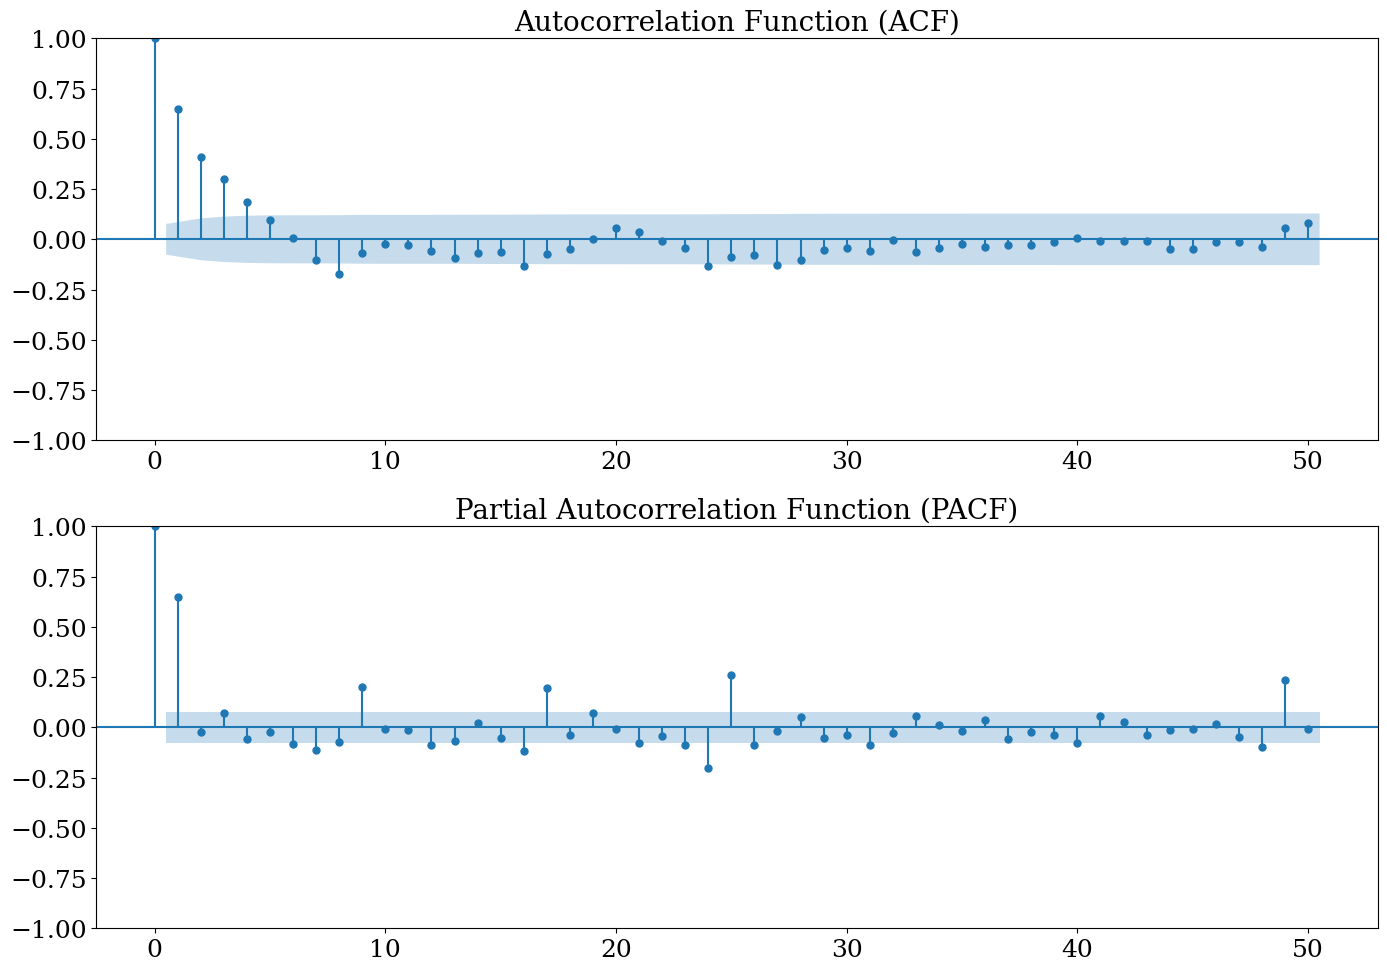

In [348]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot ACF and PACF for the cleaned training data
plt.figure(figsize=(14, 10))

# ACF plot
plt.subplot(2, 1, 1)
plot_acf(train_data['Target'], lags=50, ax=plt.gca())
plt.title("Autocorrelation Function (ACF)")

# PACF plot
plt.subplot(2, 1, 2)
plot_pacf(train_data['Target'], lags=50, ax=plt.gca(), method='ywm')
plt.title("Partial Autocorrelation Function (PACF)")

# Save the figure as an SVG file
plt.savefig("acf_h2.svg", format="svg", dpi=900, bbox_inches='tight', facecolor='white')
plt.tight_layout()
plt.show()

In [113]:
data=datac

# MODEL 1 : NO FEATURE SARIMA

In [114]:
start_time=time.time()

In [115]:
train_data = data[:-4]  # Last 4 rows for testing
test_data = data[-4:]

                                      SARIMAX Results                                      
Dep. Variable:                              Target   No. Observations:                  655
Model:             SARIMAX(1, 0, 0)x(1, 0, [1], 8)   Log Likelihood               -2299.494
Date:                             Mon, 31 Mar 2025   AIC                           4606.988
Time:                                     09:05:05   BIC                           4624.926
Sample:                                          0   HQIC                          4613.943
                                             - 655                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7570      0.024     31.565      0.000       0.710       0.804
ar.S.L8        0.2977      

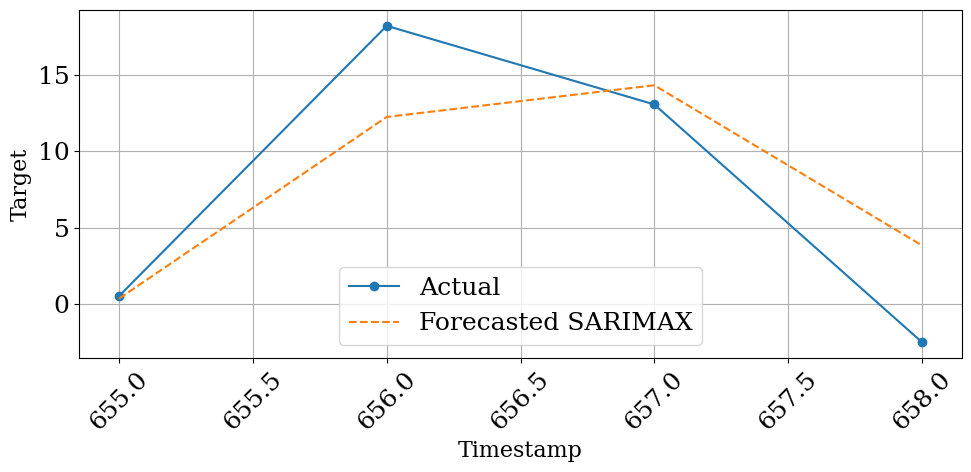

MAE: 3.42, MAPE: 0.82


In [116]:
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt

# Ensure data is sorted
train_data = train_data.sort_index()
test_data = test_data.sort_index()

# Fit SARIMAX model with combined Fourier terms
model = SARIMAX(train_data['Target'], 
                order=(1, 0, 0),  # AR(4) with no differencing
                seasonal_order=(1, 0, 1, 8)
                )  
sarimax_results = model.fit(disp=False)
print(sarimax_results.summary())
# Forecast using combined Fourier terms
sarimax_forecast = sarimax_results.get_forecast(steps=len(test_data)).predicted_mean


# Evaluation metrics
sarimax_mae = mean_absolute_error(test_data['Target'], sarimax_forecast)
sarimax_mape = mean_absolute_percentage_error(test_data['Target'], sarimax_forecast)


# Plot results
plt.figure(figsize=(10, 5))
plt.plot(test_data.index, test_data['Target'], label='Actual', marker='o')
plt.plot(test_data.index, sarimax_forecast, label='Forecasted SARIMAX', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Print evaluation metrics
print(f"MAE: {sarimax_mae:.2f}, MAPE: {sarimax_mape:.2f}")


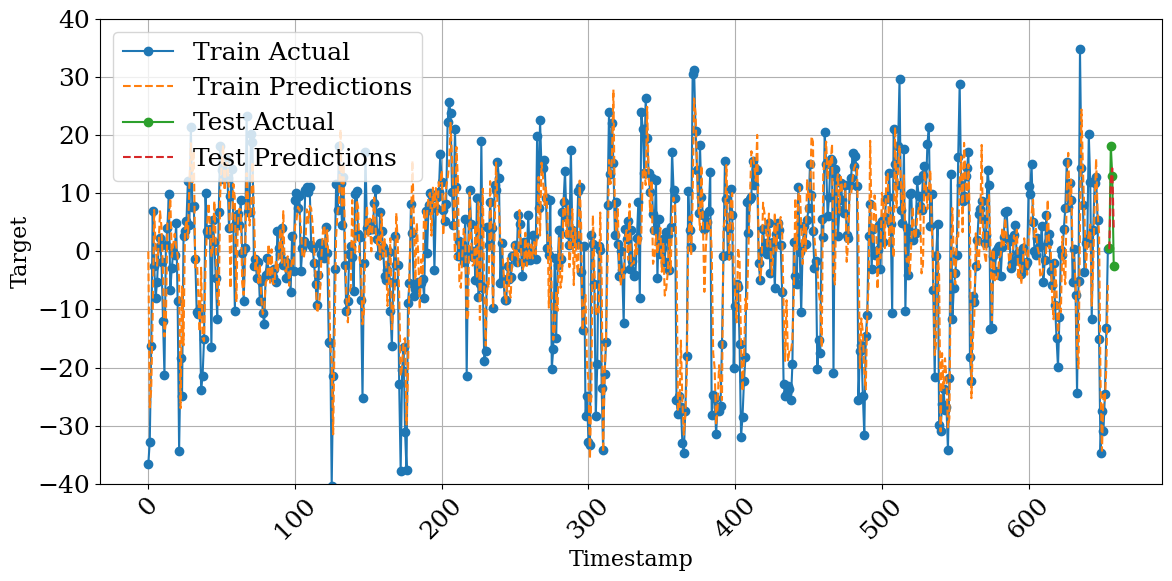

Train MAE: 6.1229
Train MAPE: 5.0085
Test MAE: 3.4221
Test MAPE: 0.8223


In [117]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(1, 0, 0),  # AR(4) with no differencing
                seasonal_order=(1, 0, 1, 8)
                )  
sarimax_results = model.fit(disp=False)

# In-sample predictions for the training set
train_predictions = sarimax_results.predict(start=train_data.index[0], 
                                             end=train_data.index[-1], 
                                      )

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data))
test_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics for the training set
train_mae = mean_absolute_error(train_data['Target'], train_predictions)
train_mape = mean_absolute_percentage_error(train_data['Target'], train_predictions)

# Calculate evaluation metrics for the test set
test_mae = mean_absolute_error(test_data['Target'], test_predictions)
test_mape = mean_absolute_percentage_error(test_data['Target'], test_predictions)

# Plot the results: actual and predictions for both train and test data
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data['Target'], label='Train Actual', marker='o')
plt.plot(train_data.index, train_predictions, label='Train Predictions', linestyle='--')
plt.plot(test_data.index, test_data['Target'], label='Test Actual', marker='o')
plt.plot(test_data.index, test_predictions, label='Test Predictions', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(-40, 40)
plt.show()

# Output the evaluation metrics
print("Train MAE: {:.4f}".format(train_mae))
print("Train MAPE: {:.4f}".format(train_mape))
print("Test MAE: {:.4f}".format(test_mae))
print("Test MAPE: {:.4f}".format(test_mape))


   Combined_Sum
0     40.491818
1     53.048322
2     51.923174
3     34.149361
MAE: 3.88
MAPE: 10.41%


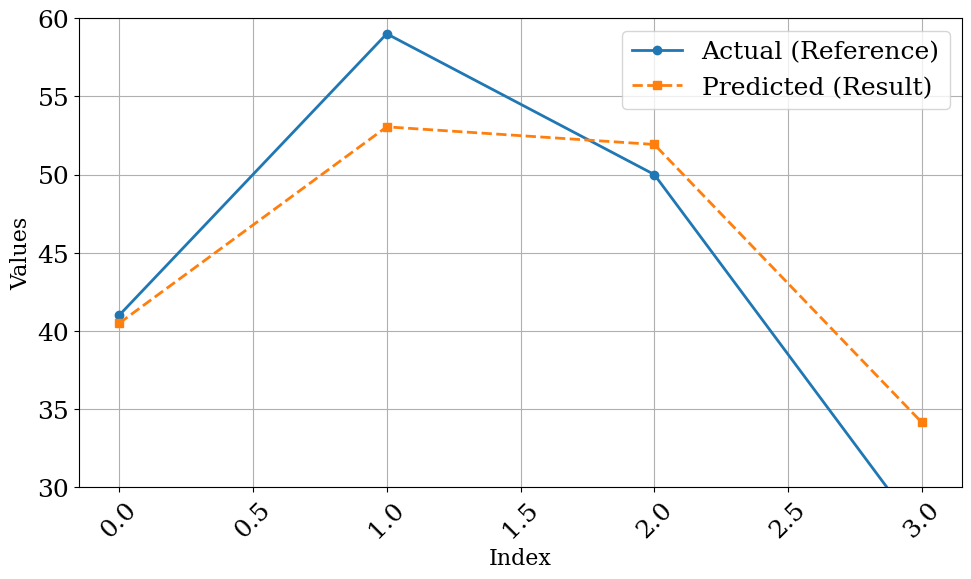

In [118]:
# Convert the DataFrames to NumPy arrays
sarimax_forecast_array = sarimax_forecast.to_numpy().flatten()
summed_up_array = summed_up.to_numpy().flatten()

# Ensure both arrays have the same length
min_length = min(len(sarimax_forecast_array), len(summed_up_array))
sarimax_forecast_array = sarimax_forecast_array[:min_length]
summed_up_array = summed_up_array[:min_length]

# Perform element-wise summation
combined_sum_array = sarimax_forecast_array + summed_up_array

# Convert the result back to a DataFrame (optional)
result_df = pd.DataFrame(combined_sum_array, columns=['Combined_Sum'])

# Print the resulting DataFrame
print(result_df)

# Reset the index of the reference DataFrame
reference = reference.reset_index(drop=True)

# Ensure alignment of lengths
min_length = min(len(result_df), len(reference))
predicted = result_df.iloc[:min_length]['Combined_Sum']
test = reference.iloc[:min_length].squeeze()

# Calculate MAE and MAPE
mae = mean_absolute_error(test, predicted)
mape = mean_absolute_percentage_error(test, predicted)

# Print MAE and MAPE
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2%}")

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(test.index, test, label='Actual (Reference)', marker='o', linestyle='-', linewidth=2)
plt.plot(predicted.index, predicted, label='Predicted (Result)', marker='s', linestyle='--', linewidth=2)
 
plt.xlabel('Index')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(30, 60)
plt.show()



In [119]:
end_time=time.time()

In [120]:
Cost=end_time-start_time

In [121]:
main_results = update_results(main_results, 'SARIMA by DECOMPOSITION W NO FEATURE ', mae, mape,Cost)

In [122]:
main_results

,Model_Name,MAE,MAPE,Cost
0,BASE SARIMA WITHOUT DECOMPOSITION,14.107829,0.293031,33.096646
1,BASE AUTO SARIMA WITHOUT DECOMPOSITION,12.438014,0.290428,66.778659
2,SARIMA by DECOMPOSITION W NO FEATURE,3.883099,0.104131,6.707407


# MODEL 1-1 : NO FEATURE AUTO SARIMA

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[8] intercept   : AIC=5198.693, Time=0.03 sec
 ARIMA(1,0,0)(1,0,0)[8] intercept   : AIC=4799.018, Time=0.44 sec
 ARIMA(0,0,1)(0,0,1)[8] intercept   : AIC=4862.225, Time=0.33 sec
 ARIMA(0,0,0)(0,0,0)[8]             : AIC=5196.896, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[8] intercept   : AIC=4837.038, Time=0.07 sec
 ARIMA(1,0,0)(2,0,0)[8] intercept   : AIC=4758.416, Time=2.64 sec
 ARIMA(1,0,0)(2,0,1)[8] intercept   : AIC=inf, Time=1.01 sec
 ARIMA(1,0,0)(1,0,1)[8] intercept   : AIC=inf, Time=0.79 sec
 ARIMA(0,0,0)(2,0,0)[8] intercept   : AIC=5161.726, Time=3.62 sec
 ARIMA(2,0,0)(2,0,0)[8] intercept   : AIC=4760.414, Time=3.85 sec
 ARIMA(1,0,1)(2,0,0)[8] intercept   : AIC=4760.413, Time=2.53 sec
 ARIMA(0,0,1)(2,0,0)[8] intercept   : AIC=4866.488, Time=1.34 sec
 ARIMA(2,0,1)(2,0,0)[8] intercept   : AIC=inf, Time=3.00 sec
 ARIMA(1,0,0)(2,0,0)[8]             : AIC=4756.474, Time=0.49 sec
 ARIMA(1,0,0)(1,0,0)[8]             : AIC=4797.0

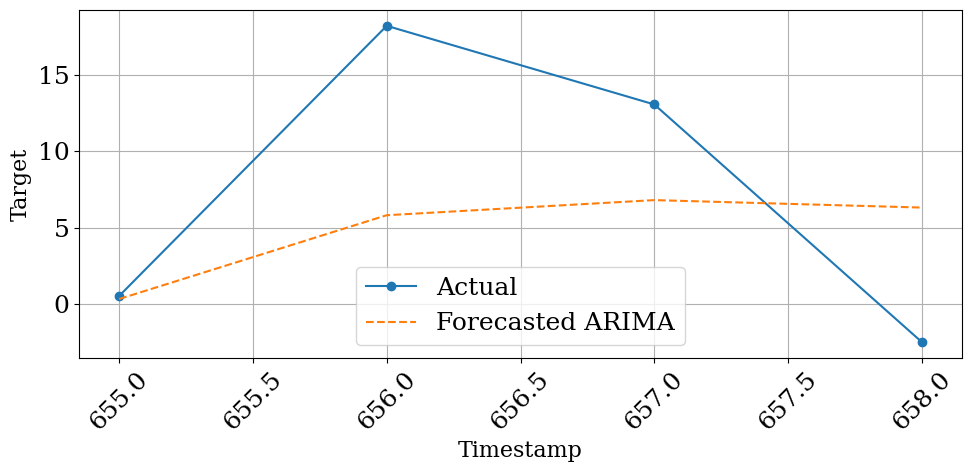

Test MAE: 6.8992
Test MAPE: 1.2711


In [123]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# Fit auto_arima with exogenous variables and seasonal period of 8
stepwise_model = auto_arima(
    y=train_data['Target'],

    seasonal=True,
    m=8,
    start_p=0, start_q=0,
    max_p=5, max_q=5,
    start_P=0, start_Q=0,
    max_P=2, max_Q=2,
    d=None, D=None,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True,
    information_criterion='aic'
)

# Forecast for test period using exogenous variables
n_periods = len(test_data)
sarima_predictions = stepwise_model.predict(n_periods=n_periods)

# Calculate evaluation metrics
sarima_mae = mean_absolute_error(test_data['Target'], sarima_predictions)
sarima_mape = mean_absolute_percentage_error(test_data['Target'], sarima_predictions)

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(test_data.index, test_data['Target'], label='Actual', marker='o')
plt.plot(test_data.index, sarima_predictions, label='Forecasted ARIMA', linestyle='--')

plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Output the MAE and MAPE values
print("Test MAE: {:.4f}".format(sarima_mae))
print("Test MAPE: {:.4f}".format(sarima_mape))


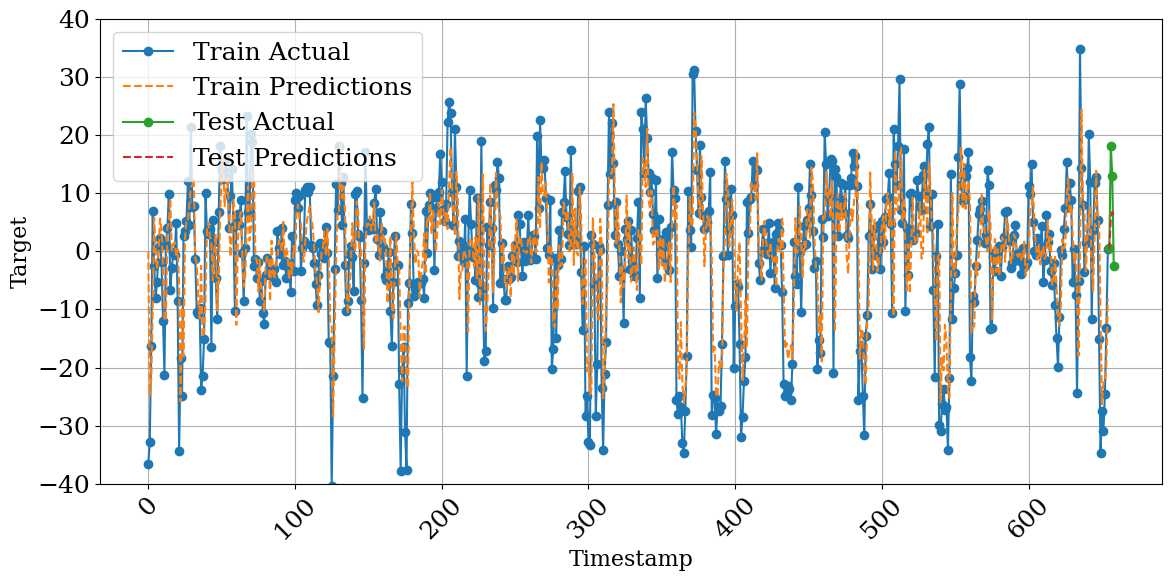

Train MAE: 6.6980
Train MAPE: 6.1197
Test MAE: 6.8992
Test MAPE: 1.2711


In [124]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error


# In-sample predictions for the training set
train_predictions = stepwise_model.predict_in_sample()

# Forecasting the values for the test set duration
test_predictions = stepwise_model.predict(n_periods=len(test_data))

# Calculate evaluation metrics for the training set
train_mae = mean_absolute_error(train_data['Target'], train_predictions)
train_mape = mean_absolute_percentage_error(train_data['Target'], train_predictions)

# Calculate evaluation metrics for the test set
test_mae = mean_absolute_error(test_data['Target'], test_predictions)
test_mape = mean_absolute_percentage_error(test_data['Target'], test_predictions)

# Plot the results: actual and predictions for both train and test data
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data['Target'], label='Train Actual', marker='o')
plt.plot(train_data.index, train_predictions, label='Train Predictions', linestyle='--')
plt.plot(test_data.index, test_data['Target'], label='Test Actual', marker='o')
plt.plot(test_data.index, test_predictions, label='Test Predictions', linestyle='--')

plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(-40, 40)
plt.show()

# Output the evaluation metrics
print("Train MAE: {:.4f}".format(train_mae))
print("Train MAPE: {:.4f}".format(train_mape))
print("Test MAE: {:.4f}".format(test_mae))
print("Test MAPE: {:.4f}".format(test_mape))


   Combined_Sum
0     40.458920
1     46.633295
2     44.424308
3     36.616868
MAE: 7.03
MAPE: 17.26%


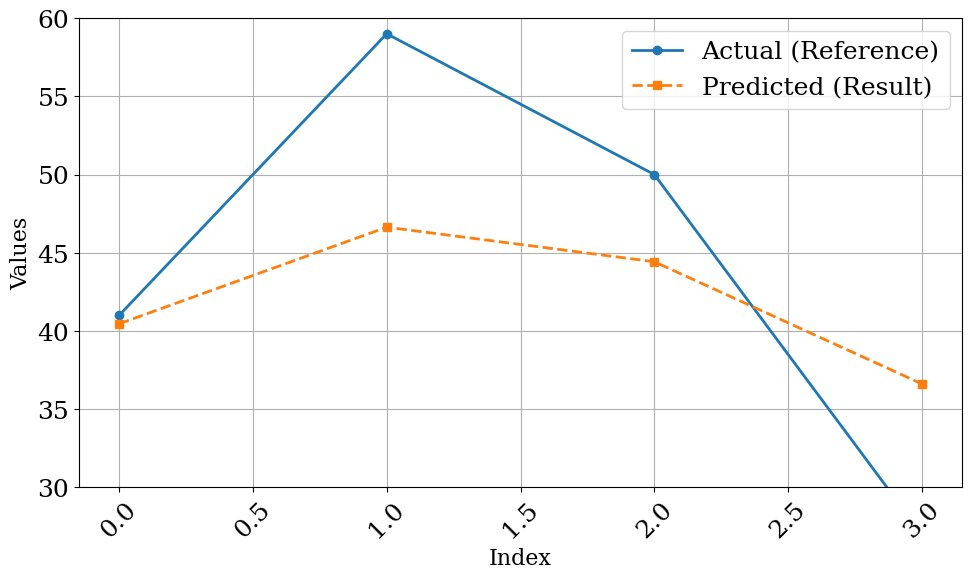

In [125]:
# Convert the DataFrames to NumPy arrays
sarimax_forecast_array = test_predictions.to_numpy().flatten()
summed_up_array = summed_up.to_numpy().flatten()

# Ensure both arrays have the same length
min_length = min(len(sarimax_forecast_array), len(summed_up_array))
sarimax_forecast_array = sarimax_forecast_array[:min_length]
summed_up_array = summed_up_array[:min_length]

# Perform element-wise summation
combined_sum_array = sarimax_forecast_array + summed_up_array

# Convert the result back to a DataFrame (optional)
result_df = pd.DataFrame(combined_sum_array, columns=['Combined_Sum'])

# Print the resulting DataFrame
print(result_df)

# Reset the index of the reference DataFrame
reference = reference.reset_index(drop=True)

# Ensure alignment of lengths
min_length = min(len(result_df), len(reference))
predicted = result_df.iloc[:min_length]['Combined_Sum']
test = reference.iloc[:min_length].squeeze()

# Calculate MAE and MAPE
mae = mean_absolute_error(test, predicted)
mape = mean_absolute_percentage_error(test, predicted)

# Print MAE and MAPE
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2%}")

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(test.index, test, label='Actual (Reference)', marker='o', linestyle='-', linewidth=2)
plt.plot(predicted.index, predicted, label='Predicted (Result)', marker='s', linestyle='--', linewidth=2)
 
plt.xlabel('Index')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(30, 60)
plt.show()

In [126]:
end_time=time.time()

In [127]:
Cost = end_time - start_time

In [128]:
main_results = update_results(main_results, 'AUTO SARIMA BY DECOMPOSITION W NO FEATURE', mae, mape,Cost)

In [129]:
main_results

,Model_Name,MAE,MAPE,Cost
0,BASE SARIMA WITHOUT DECOMPOSITION,14.107829,0.293031,33.096646
1,BASE AUTO SARIMA WITHOUT DECOMPOSITION,12.438014,0.290428,66.778659
2,SARIMA by DECOMPOSITION W NO FEATURE,3.883099,0.104131,6.707407
3,AUTO SARIMA BY DECOMPOSITION W NO FEATURE,7.025086,0.172624,39.854797


### TOPOLOGICAL DATASET

In [130]:
main_results = update_results(main_results, 'Topological Dataset','0' ,'0','0' )

In [131]:
data=datat

# MODEL 2 : SARIMA W ALL FEATURES

In [132]:
start_time=time.time()

In [133]:
train_data = data[:-4]  # Last 4 rows for testing
test_data = data[-4:]

In [134]:
selected_columns_train = train_data.drop(columns=["Target"])
selected_columns_test = test_data.drop(columns=["Target"])

In [135]:
exog_train=selected_columns_train
exog_test=selected_columns_test 

D:\Users\ar600780\AppData\Roaming\Python\Python310\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


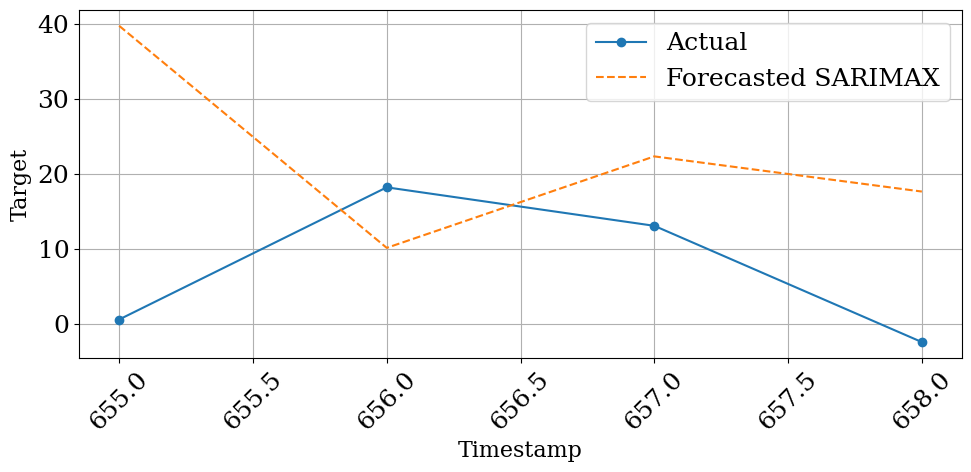

(19.15478310915267, 20.335095727158738)

In [136]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt


# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(1, 0, 0), 
                seasonal_order=(1, 0, 1, 8), 
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
sarima_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics
sarima_mse = mean_absolute_error(test_data['Target'], sarima_predictions)
sarima_mape = mean_absolute_percentage_error(test_data['Target'], sarima_predictions)

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(test_data.index, test_data['Target'], label='Actual', marker='o')
plt.plot(test_data.index, sarima_predictions, label='Forecasted SARIMAX', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Output the MSE and MAPE values
sarima_mse, sarima_mape


D:\Users\ar600780\AppData\Roaming\Python\Python310\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


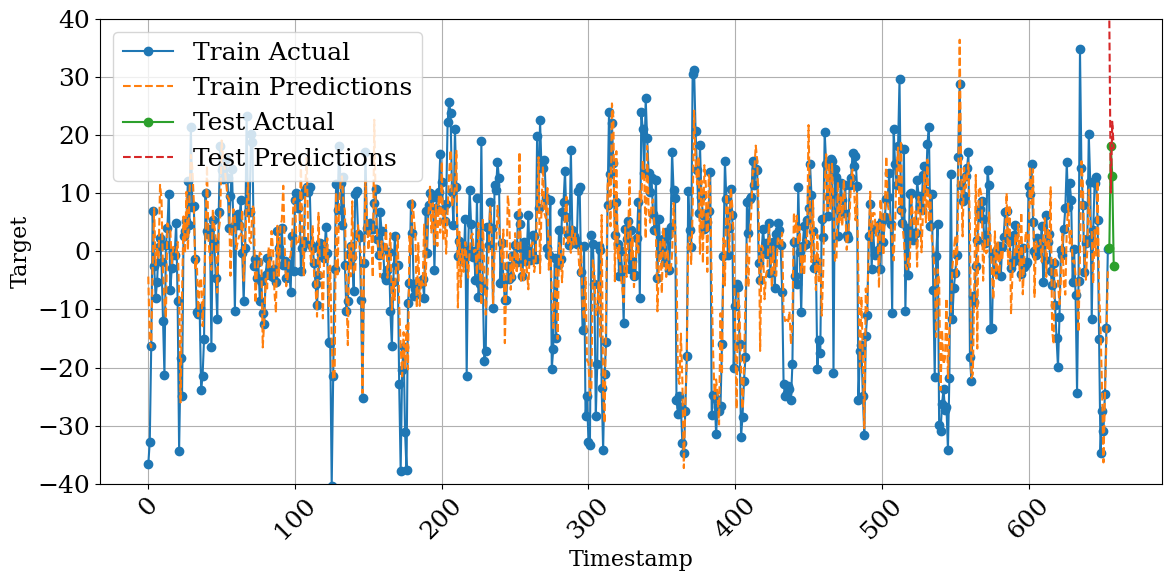

Train MAE: 6.8666
Train MAPE: 10.6278
Test MAE: 19.1548
Test MAPE: 20.3351


In [137]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(1, 0, 0), 
                seasonal_order=(1, 0, 1, 8), 
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# In-sample predictions for the training set
train_predictions = sarimax_results.predict(start=train_data.index[0], 
                                             end=train_data.index[-1], 
                                             exog=exog_train)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
test_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics for the training set
train_mae = mean_absolute_error(train_data['Target'], train_predictions)
train_mape = mean_absolute_percentage_error(train_data['Target'], train_predictions)

# Calculate evaluation metrics for the test set
test_mae = mean_absolute_error(test_data['Target'], test_predictions)
test_mape = mean_absolute_percentage_error(test_data['Target'], test_predictions)

# Plot the results: actual and predictions for both train and test data
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data['Target'], label='Train Actual', marker='o')
plt.plot(train_data.index, train_predictions, label='Train Predictions', linestyle='--')
plt.plot(test_data.index, test_data['Target'], label='Test Actual', marker='o')
plt.plot(test_data.index, test_predictions, label='Test Predictions', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(-40, 40)
plt.show()

# Output the evaluation metrics
print("Train MAE: {:.4f}".format(train_mae))
print("Train MAPE: {:.4f}".format(train_mape))
print("Test MAE: {:.4f}".format(test_mae))
print("Test MAPE: {:.4f}".format(test_mape))


   Combined_Sum
0     79.850267
1     50.923231
2     59.935070
3     47.920658
MAE: 19.45
MAPE: 51.45%


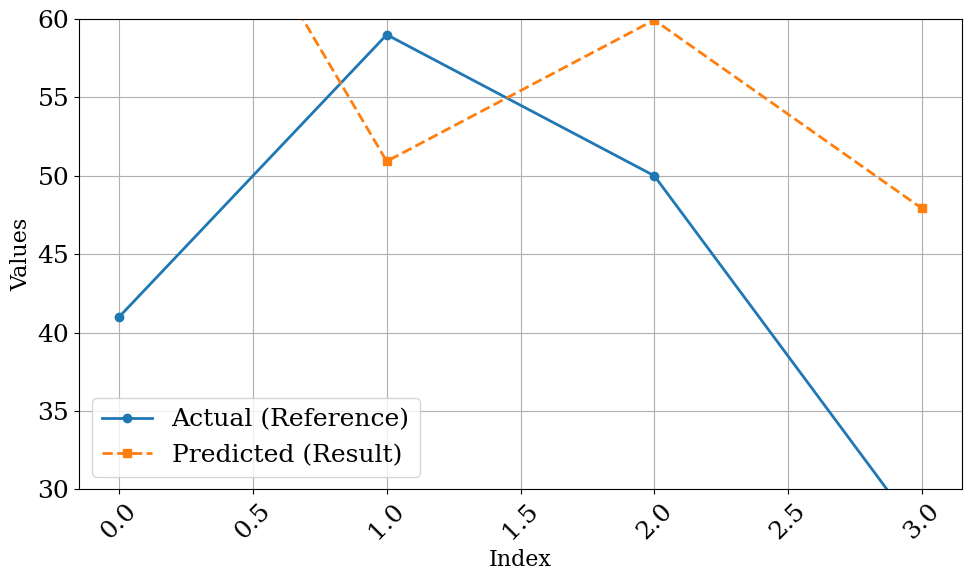

In [138]:
# Convert the DataFrames to NumPy arrays
sarimax_forecast_array = sarima_predictions.to_numpy().flatten()
summed_up_array = summed_up.to_numpy().flatten()

# Ensure both arrays have the same length
min_length = min(len(sarimax_forecast_array), len(summed_up_array))
sarimax_forecast_array = sarimax_forecast_array[:min_length]
summed_up_array = summed_up_array[:min_length]

# Perform element-wise summation
combined_sum_array = sarimax_forecast_array + summed_up_array

# Convert the result back to a DataFrame (optional)
result_df = pd.DataFrame(combined_sum_array, columns=['Combined_Sum'])

# Print the resulting DataFrame
print(result_df)

# Reset the index of the reference DataFrame
reference = reference.reset_index(drop=True)

# Ensure alignment of lengths
min_length = min(len(result_df), len(reference))
predicted = result_df.iloc[:min_length]['Combined_Sum']
test = reference.iloc[:min_length].squeeze()

# Calculate MAE and MAPE
mae = mean_absolute_error(test, predicted)
mape = mean_absolute_percentage_error(test, predicted)

# Print MAE and MAPE
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2%}")

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(test.index, test, label='Actual (Reference)', marker='o', linestyle='-', linewidth=2)
plt.plot(predicted.index, predicted, label='Predicted (Result)', marker='s', linestyle='--', linewidth=2)
 
plt.xlabel('Index')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(30, 60)
plt.show()


In [139]:
end_time=time.time()

In [140]:
Cost = end_time - start_time

In [141]:
main_results = update_results(main_results, 'SARIMA W ALL FEATUREs', mae, mape,Cost)

In [142]:
main_results

,Model_Name,MAE,MAPE,Cost
0,BASE SARIMA WITHOUT DECOMPOSITION,14.107829,0.293031,33.096646
1,BASE AUTO SARIMA WITHOUT DECOMPOSITION,12.438014,0.290428,66.778659
2,SARIMA by DECOMPOSITION W NO FEATURE,3.883099,0.104131,6.707407
3,AUTO SARIMA BY DECOMPOSITION W NO FEATURE,7.025086,0.172624,39.854797
4,Topological Dataset,0,0,0
5,SARIMA W ALL FEATUREs,19.445691,0.514501,100.935903


# MODEL 3-1 : SARIMA W RFE FEATURES

In [143]:
start_time=time.time()

In [144]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.utils import resample
import time
import warnings
import multiprocessing
from joblib import Parallel, delayed

warnings.filterwarnings("ignore")

start_time = time.time()

# Load dataset
df = data  # <-- make sure `data` is defined
target_column = "Target"
exog_columns = [col for col in df.columns if col != target_column]

# Split into training
train_df = df.iloc[:-4]
X_train = train_df[exog_columns]
y_train = train_df[target_column]

# SARIMAX p-value extractor
def get_p_values(X, y):
    try:
        model = SARIMAX(y, 
                        order=(1, 0, 0), 
                        seasonal_order=(1, 0, 1, 8), 
                        exog=X)
        result = model.fit(disp=False)
        return result.pvalues.loc[X.columns]
    except Exception as e:
        print("SARIMAX fit error:", e)
        return pd.Series([1.0] * X.shape[1], index=X.columns)

# Model AIC calculator
def compute_aic(feature_set):
    try:
        model = SARIMAX(y_train, 
                        order=(1, 0, 0), 
                        seasonal_order=(1, 0, 1, 8), 
                        exog=X_train[list(feature_set)])
        result = model.fit(disp=False)
        return (feature_set, result.aic)
    except:
        return (feature_set, np.inf)

# RFE parameters
selected_features = exog_columns.copy()
step2 = 5

# RFE Loop
while True:
    p_values = get_p_values(X_train[selected_features], y_train)

    # Features with p > 0.05
    worst_candidates = p_values[p_values > 0.05]

    # Stopping criterion
    if len(worst_candidates) < step2:
        print(f"Stopping early: Only {len(worst_candidates)} features have p > 0.05.")
        break

    # Dynamic step size
    step = min(20, len(worst_candidates), len(selected_features) // 2)

    # Worst features sorted by p-value
    worst_features = worst_candidates.sort_values(ascending=False).head(step).index

    for feature in worst_features:
        if feature in selected_features:
            selected_features.remove(feature)
            print(f"Removed Feature: {feature}, p-value: {p_values[feature]}")

print("\nInitial RFE Completed.")
print(f"Remaining Features: {len(selected_features)}")

# Optional: Stability Check via Bootstrapping
print("\nRunning stability check (bootstrap p-values)...")
bootstrap_rounds = 10
stable_features = []

boot_results = []
for i in range(bootstrap_rounds):
    X_res, y_res = resample(X_train[selected_features], y_train)
    p_vals = get_p_values(X_res, y_res)
    significant = set(p_vals[p_vals < 0.05].index)
    boot_results.append(significant)

stable_features = list(set.intersection(*boot_results))
print(f"\nStable Features Across {bootstrap_rounds} Bootstraps: {len(stable_features)}")

# Optional: AIC comparison for final selection
print("\nEvaluating AIC on stable subsets...")
feature_sets = [stable_features, selected_features]  # Compare both
num_cores = multiprocessing.cpu_count()

aic_values = Parallel(n_jobs=num_cores)(
    delayed(compute_aic)(f_set) for f_set in feature_sets
)

best_features, best_aic = sorted(aic_values, key=lambda x: x[1])[0]
print(f"\nBest AIC: {best_aic}")
print("Selected Final Features:", best_features)


Removed Feature: Col30_L2_H1, p-value: 0.9831859369913116
Removed Feature: Col56_L1_H1, p-value: 0.9830439692141159
Removed Feature: Col80_L1_H0, p-value: 0.9776988816804261
Removed Feature: Col46_L2_H1, p-value: 0.9672715700540268
Removed Feature: Col78_L1_H0, p-value: 0.9509723345655674
Removed Feature: Col29_L1_H1, p-value: 0.9482280723112969
Removed Feature: Col15_L2_H0, p-value: 0.9289524110645915
Removed Feature: Col34_L1_H1, p-value: 0.9223770794591897
Removed Feature: Col68_L1_H1, p-value: 0.9072766648601549
Removed Feature: Col28_L1_H0, p-value: 0.888259309782647
Removed Feature: Col64_L1_H0, p-value: 0.8835894480574129
Removed Feature: Col60_L1_H0, p-value: 0.8823310316028549
Removed Feature: silhouette_features_L2_H0_SI, p-value: 0.8640985215716825
Removed Feature: Col54_L1_H1, p-value: 0.8623507167575999
Removed Feature: Col51_L2_H1, p-value: 0.8588523630603003
Removed Feature: Col33_L1_H0, p-value: 0.837726558435049
Removed Feature: Col32_L2_H1, p-value: 0.8358621360403297

In [145]:
columns_to_keep = selected_features.copy()  # Make a copy of your list
if 'Target' not in columns_to_keep:
    columns_to_keep.append('Target')

data_rfe = data[columns_to_keep]

In [146]:
data_rfe

,amplitude_bottleneck_0,betti_L2_H0,L1_H0,Col4_L2_H0,Col5_L1_H0,Col5_L2_H0,Col6_L2_H0,Col7_L1_H0,Col7_L2_H0,Col8_L1_H0,...,Col87_L2_H1,Col88_L2_H1,Col93_L1_H1,Col93_L2_H1,Col95_L1_H1,Col96_L1_H1,Col97_L2_H1,Col99_L2_H1,dim_0_median_lifetime,Target
0,0.098614,0.289040,0.671865,0.751978,0.828142,0.778488,0.856326,0.873505,0.756762,0.861010,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.224633,-36.630516
1,0.675501,0.389639,0.784918,0.623555,0.915081,0.620170,0.641286,0.844655,0.554010,0.761852,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.248784,-32.755274
2,0.613014,0.379624,0.777805,0.645319,0.915486,0.644582,0.672859,0.868392,0.587565,0.802653,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.248784,-16.242944
3,0.270372,0.458352,0.884161,0.590449,0.977780,0.568589,0.529891,0.778318,0.400278,0.621735,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.269650,6.891582
4,0.420537,0.529010,0.903267,0.389432,0.976562,0.354078,0.316272,0.714620,0.250748,0.507813,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.284929,-2.448256
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
654,0.475822,0.888381,0.998306,0.446668,0.994023,0.411135,0.336796,0.491017,0.188570,0.103697,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.768420,0.412770
655,0.475822,0.898200,1.000000,0.564590,0.993631,0.536697,0.456026,0.484490,0.258456,0.089984,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.737455,0.543904
656,0.475822,0.839722,0.993651,0.464090,0.995018,0.429649,0.354490,0.509959,0.199502,0.138911,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.673147,18.180364
657,0.489660,0.894935,0.993655,0.355887,0.995018,0.314437,0.245102,0.509959,0.135409,0.138911,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.818619,13.045591


In [147]:
train_data = data_rfe[:-4]  # Last 4 rows for testing
test_data = data_rfe[-4:]

In [148]:
selected_columns_train = train_data.drop(columns=["Target"])
selected_columns_test = test_data.drop(columns=["Target"])

In [149]:
exog_train=selected_columns_train
exog_test=selected_columns_test 

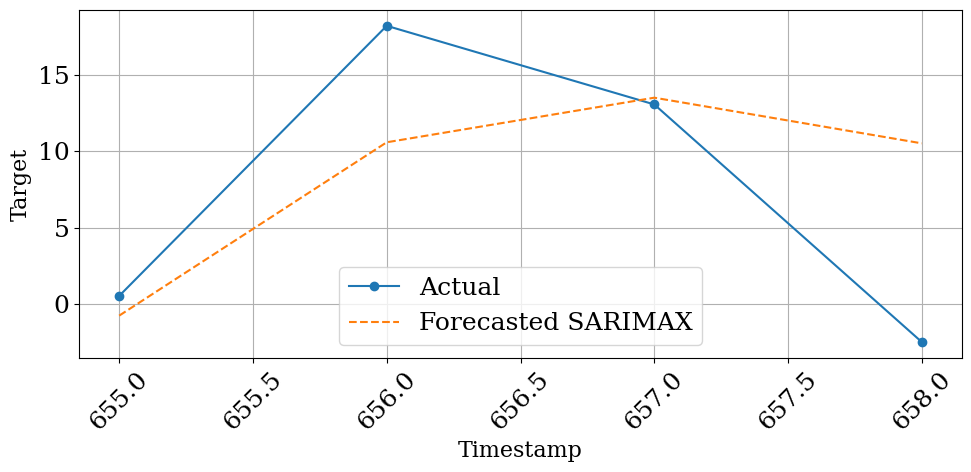

(5.577565099535592, 2.0184934762138553)

In [150]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt


# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(1, 0, 0), 
                seasonal_order=(1, 0, 1, 8), 
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
sarima_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics
sarima_mse = mean_absolute_error(test_data['Target'], sarima_predictions)
sarima_mape = mean_absolute_percentage_error(test_data['Target'], sarima_predictions)

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(test_data.index, test_data['Target'], label='Actual', marker='o')
plt.plot(test_data.index, sarima_predictions, label='Forecasted SARIMAX', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Output the MSE and MAPE values
sarima_mse, sarima_mape


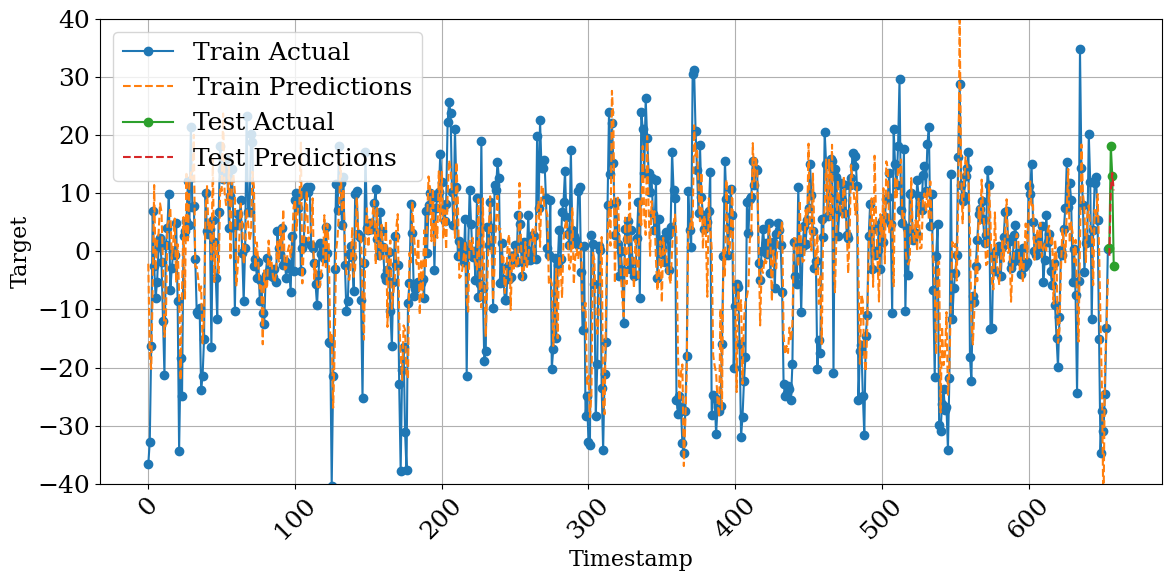

Train MAE: 6.9139
Train MAPE: 3.6521
Test MAE: 5.5776
Test MAPE: 2.0185


In [151]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(1, 0, 0), 
                seasonal_order=(1, 0, 1, 8), 
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# In-sample predictions for the training set
train_predictions = sarimax_results.predict(start=train_data.index[0], 
                                             end=train_data.index[-1], 
                                             exog=exog_train)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
test_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics for the training set
train_mae = mean_absolute_error(train_data['Target'], train_predictions)
train_mape = mean_absolute_percentage_error(train_data['Target'], train_predictions)

# Calculate evaluation metrics for the test set
test_mae = mean_absolute_error(test_data['Target'], test_predictions)
test_mape = mean_absolute_percentage_error(test_data['Target'], test_predictions)

# Plot the results: actual and predictions for both train and test data
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data['Target'], label='Train Actual', marker='o')
plt.plot(train_data.index, train_predictions, label='Train Predictions', linestyle='--')
plt.plot(test_data.index, test_data['Target'], label='Test Actual', marker='o')
plt.plot(test_data.index, test_predictions, label='Test Predictions', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(-40, 40)
plt.show()

# Output the evaluation metrics
print("Train MAE: {:.4f}".format(train_mae))
print("Train MAPE: {:.4f}".format(train_mape))
print("Test MAE: {:.4f}".format(test_mae))
print("Test MAPE: {:.4f}".format(test_mape))


   Combined_Sum
0     39.371524
1     51.395632
2     51.112006
3     40.809239
MAE: 6.04
MAPE: 17.56%


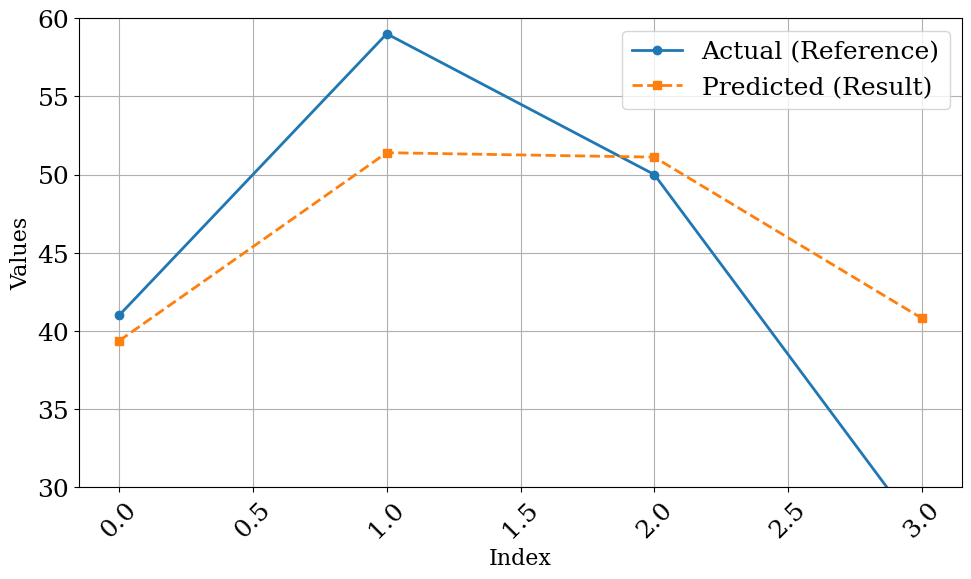

In [152]:
# Convert the DataFrames to NumPy arrays
sarimax_forecast_array = sarima_predictions.to_numpy().flatten()
summed_up_array = summed_up.to_numpy().flatten()

# Ensure both arrays have the same length
min_length = min(len(sarimax_forecast_array), len(summed_up_array))
sarimax_forecast_array = sarimax_forecast_array[:min_length]
summed_up_array = summed_up_array[:min_length]

# Perform element-wise summation
combined_sum_array = sarimax_forecast_array + summed_up_array

# Convert the result back to a DataFrame (optional)
result_df = pd.DataFrame(combined_sum_array, columns=['Combined_Sum'])

# Print the resulting DataFrame
print(result_df)

# Reset the index of the reference DataFrame
reference = reference.reset_index(drop=True)

# Ensure alignment of lengths
min_length = min(len(result_df), len(reference))
predicted = result_df.iloc[:min_length]['Combined_Sum']
test = reference.iloc[:min_length].squeeze()

# Calculate MAE and MAPE
mae = mean_absolute_error(test, predicted)
mape = mean_absolute_percentage_error(test, predicted)

# Print MAE and MAPE
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2%}")

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(test.index, test, label='Actual (Reference)', marker='o', linestyle='-', linewidth=2)
plt.plot(predicted.index, predicted, label='Predicted (Result)', marker='s', linestyle='--', linewidth=2)
 
plt.xlabel('Index')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(30, 60)
plt.show()


In [153]:
end_time=time.time()

In [154]:
Cost = end_time - start_time

In [155]:
main_results = update_results(main_results, 'SARIMA W RFE FEATUREs', mae, mape,Cost)

In [156]:
main_results

,Model_Name,MAE,MAPE,Cost
0,BASE SARIMA WITHOUT DECOMPOSITION,14.107829,0.293031,33.096646
1,BASE AUTO SARIMA WITHOUT DECOMPOSITION,12.438014,0.290428,66.778659
2,SARIMA by DECOMPOSITION W NO FEATURE,3.883099,0.104131,6.707407
3,AUTO SARIMA BY DECOMPOSITION W NO FEATURE,7.025086,0.172624,39.854797
4,Topological Dataset,0,0,0
5,SARIMA W ALL FEATUREs,19.445691,0.514501,100.935903
6,SARIMA W RFE FEATUREs,6.038522,0.175575,420.725752


# MODEL 4 : SARIMA W RFE + PSO FEATURES

In [157]:
import numpy as np 
import pandas as pd
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pyswarm import pso  # Particle Swarm Optimization
from functools import lru_cache
from collections import Counter
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
start_time=time.time()
# Suppress warnings
warnings.filterwarnings("ignore")

# ============================
# Data Preparation
# ============================

target_column = 'Target'  # Replace with actual target column
train_data = data_rfe[:-4]  # Use all but the last 4 rows for training

selected_columns_train = train_data.drop(columns=[target_column])  # Features only
exog_train = selected_columns_train.values

num_features = selected_columns_train.shape[1]  # Number of features

# ============================
# Caching for Faster Execution
# ============================

solution_cache = {}

@lru_cache(maxsize=1000)
def evaluate_solution(solution_key):
    """
    Evaluates SARIMAX performance for a given feature subset using negative BIC.
    """
    selected_features = np.array(solution_key, dtype=bool)
    
    # Penalize solutions that select no features
    if not np.any(selected_features):
        return 1e6  

    exog_selected = exog_train[:, selected_features]

    try:
        model = SARIMAX(train_data[target_column],
                        order=(1, 0, 0),
                        seasonal_order=(1, 0, 1, 8),
                        exog=exog_selected,
                        enforce_stationarity=False,
                        enforce_invertibility=False)
        results = model.fit(disp=0, maxiter=30)  # Lower maxiter for speed
        return results.bic  # Minimize BIC
    except:
        return 1e6  # Strong penalty for errors

# ============================
# Define PSO Objective Function
# ============================

def pso_objective_function(solution):
    """
    Evaluates the fitness of a feature subset for PSO.
    """
    key = tuple(np.round(solution).astype(int))  # Convert to binary feature selection
    
    if key in solution_cache:
        return solution_cache[key]

    # Evaluate solution
    fitness_val = evaluate_solution(key)
    solution_cache[key] = fitness_val  # Store in cache
    return fitness_val

# ============================
# PSO Execution
# ============================

lb = [0] * num_features  # Lower bounds (0 = feature not selected)
ub = [1] * num_features  # Upper bounds (1 = feature selected)

selected_features_runs = []
best_results = []
num_columns = data_rfe.shape[1]-1
for run in range(5):
    print(f"Starting PSO optimization, run {run+1}...")

    best_solution, best_bic = best_solution, best_bic = pso(
    pso_objective_function, 
    lb, 
    ub, 
    swarmsize=40, 
    maxiter=100, 
    omega=0.7,  # Inertia weight
    phip=1.4,   # Cognitive parameter (similar to c1)
    phig=1.8,   # Social parameter (similar to c2)
    debug=False
)


    # Convert solution to selected feature names
    selected_features_mask = np.round(best_solution).astype(int).astype(bool)
    selected_features_pso = selected_columns_train.columns[selected_features_mask].tolist()
    selected_features_runs.append(selected_features_pso)

    # Fit final model with selected features
    exog_train_final = exog_train[:, selected_features_mask]


    final_model = SARIMAX(train_data[target_column],
                          order=(1, 0, 0),
                          seasonal_order=(1, 0, 1, 8),
                          exog=exog_train_final)
    final_results = final_model.fit(disp=False)
    


    # Save best results
    best_results.append({
        "Run": run + 1,
        "BIC": best_bic,
        "Selected Features": selected_features_pso
    })

# Convert to DataFrame
results_df = pd.DataFrame(best_results)

# Identify the best run (minimum BIC)
best_run = results_df.loc[results_df[['BIC']].sum(axis=1).idxmin()]
best_run_features = best_run["Selected Features"]

# Find the most frequently chosen features (chosen in at least 3 runs)
feature_counts = Counter(feature for run_features in selected_features_runs for feature in run_features)
final_feature_selection = list(feature_counts.keys())

# If final_feature_selection is empty, assign it to best_run_features
if not final_feature_selection:
    final_feature_selection = best_run_features

# Save best run features and final feature selection in separate lists
best_run_feature_list = list(best_run_features)
final_feature_selection_list = list(final_feature_selection)

# ============================
# Display Results
# ============================

print("\nPSO Runs Results:")
print(results_df)

print("\nBest Run Summary:")
print(best_run)

print("\nFinal Feature Selection (Chosen in at least 3 runs or from best run if empty):")
print(final_feature_selection_list)

print("\nBest Run Features List:")
print(best_run_feature_list)

# ============================
# Save Results
# ============================

# Convert to DataFrame for easy export if needed
best_run_summary_df = pd.DataFrame([best_run])
final_features_df = pd.DataFrame({"Most Chosen Features": final_feature_selection_list})


Starting PSO optimization, run 1...
Stopping search: maximum iterations reached --> 100
Starting PSO optimization, run 2...
Stopping search: maximum iterations reached --> 100
Starting PSO optimization, run 3...
Stopping search: maximum iterations reached --> 100
Starting PSO optimization, run 4...
Stopping search: maximum iterations reached --> 100
Starting PSO optimization, run 5...
Stopping search: maximum iterations reached --> 100

PSO Runs Results:
   Run          BIC                                  Selected Features
0    1  4614.510405  [amplitude_bottleneck_0, L1_H0, Col4_L2_H0, Co...
1    2  4687.281927  [L1_H0, Col5_L1_H0, Col8_L1_H0, Col16_L1_H0, C...
2    3  4658.165792  [amplitude_bottleneck_0, betti_L2_H0, Col6_L2_...
3    4  4589.220600  [betti_L2_H0, Col10_L2_H0, Col17_L2_H0, Col49_...
4    5  4623.699766  [Col16_L1_H0, Col24_L2_H0, Col38_L2_H0, Col88_...

Best Run Summary:
Run                                                                  4
BIC                      

In [158]:
# Save best run features and final feature selection in separate lists
best_run_feature_list = list(best_run_features)
final_feature_selection_list = list(final_feature_selection)

In [159]:
# Convert selected_features_pso to a standard Python list
selected_features_pso = best_run_feature_list

# Add 'Target' to the selected features list
selected_features_pso.append('Target')

In [160]:
data_pso=data_rfe[selected_features_pso]

In [161]:
# Convert selected_features_pso to a standard Python list
selected_features_pso = final_feature_selection_list

# Add 'Target' to the selected features list
selected_features_pso.append('Target')

In [162]:
data_pso_best=data_rfe[selected_features_pso]

In [163]:
train_data = data_pso[:-4]  # Last 4 rows for testing
test_data = data_pso[-4:]

In [164]:
selected_columns_train = train_data.drop(columns=["Target"])
selected_columns_test = test_data.drop(columns=["Target"])

In [165]:
exog_train=selected_columns_train
exog_test=selected_columns_test 

In [166]:
start_time=time.time()

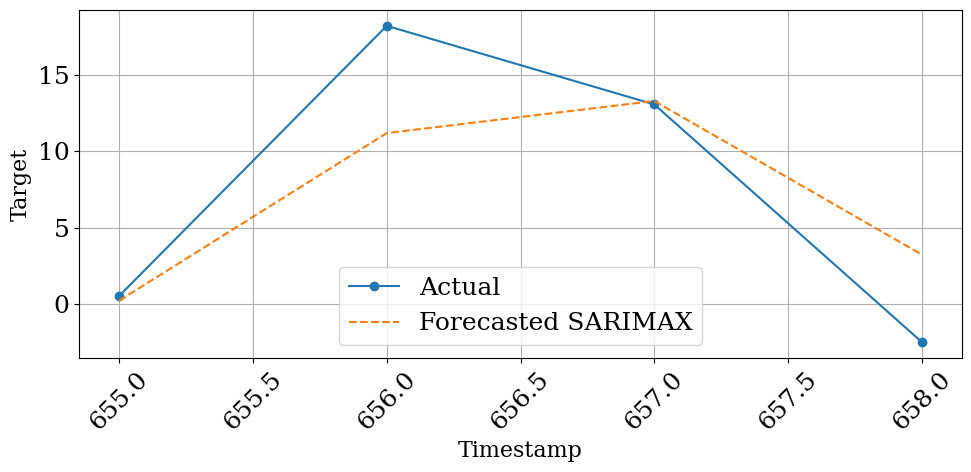

(3.3119393214405415, 0.8206437125196556)

In [167]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt


# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(1, 0, 0), 
                seasonal_order=(1, 0, 1, 8), 
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
sarima_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics
sarima_mse = mean_absolute_error(test_data['Target'], sarima_predictions)
sarima_mape = mean_absolute_percentage_error(test_data['Target'], sarima_predictions)

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(test_data.index, test_data['Target'], label='Actual', marker='o')
plt.plot(test_data.index, sarima_predictions, label='Forecasted SARIMAX', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Output the MSE and MAPE values
sarima_mse, sarima_mape


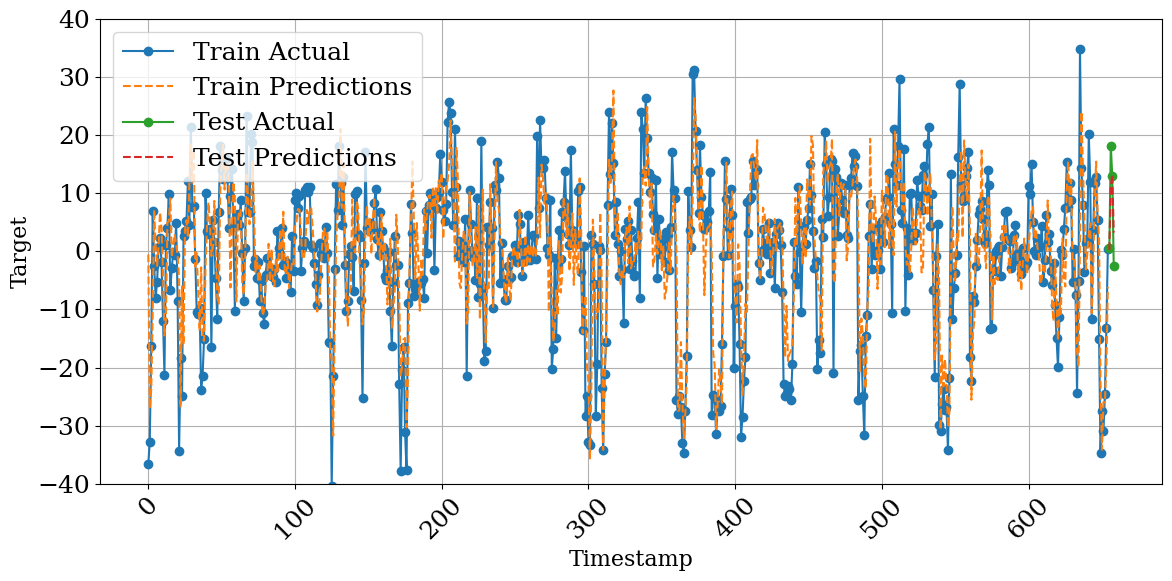

Train MAE: 6.1126
Train MAPE: 4.6437
Test MAE: 3.3119
Test MAPE: 0.8206


In [168]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(1, 0, 0), 
                seasonal_order=(1, 0, 1, 8), 
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# In-sample predictions for the training set
train_predictions = sarimax_results.predict(start=train_data.index[0], 
                                             end=train_data.index[-1], 
                                             exog=exog_train)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
test_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics for the training set
train_mae = mean_absolute_error(train_data['Target'], train_predictions)
train_mape = mean_absolute_percentage_error(train_data['Target'], train_predictions)

# Calculate evaluation metrics for the test set
test_mae = mean_absolute_error(test_data['Target'], test_predictions)
test_mape = mean_absolute_percentage_error(test_data['Target'], test_predictions)

# Plot the results: actual and predictions for both train and test data
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data['Target'], label='Train Actual', marker='o')
plt.plot(train_data.index, train_predictions, label='Train Predictions', linestyle='--')
plt.plot(test_data.index, test_data['Target'], label='Test Actual', marker='o')
plt.plot(test_data.index, test_predictions, label='Test Predictions', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(-40, 40)
plt.show()

# Output the evaluation metrics
print("Train MAE: {:.4f}".format(train_mae))
print("Train MAPE: {:.4f}".format(train_mape))
print("Test MAE: {:.4f}".format(test_mae))
print("Test MAPE: {:.4f}".format(test_mape))


   Combined_Sum
0     40.350514
1     51.996597
2     50.896161
3     33.542535
MAE: 3.77
MAPE: 9.87%


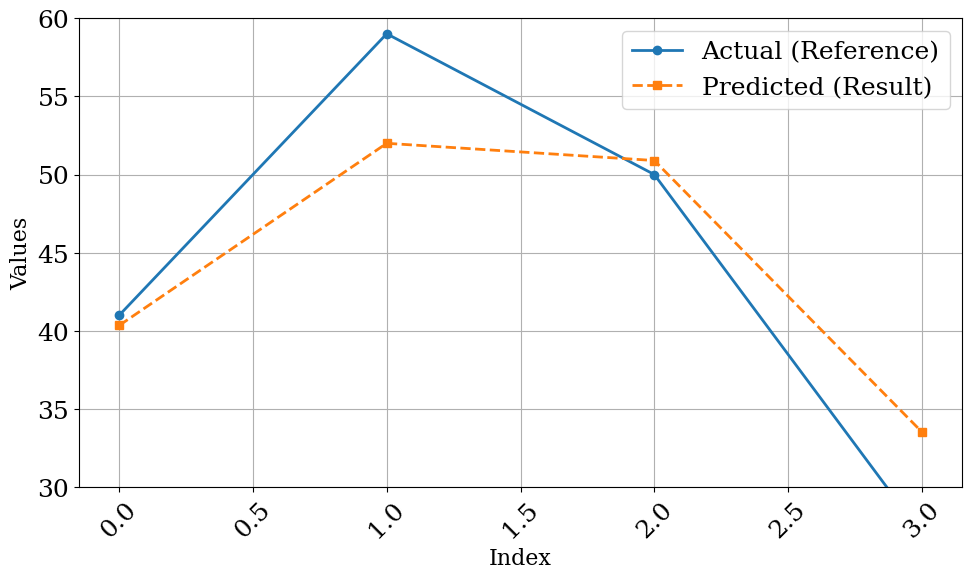

In [169]:
# Convert the DataFrames to NumPy arrays
sarimax_forecast_array = sarima_predictions.to_numpy().flatten()
summed_up_array = summed_up.to_numpy().flatten()

# Ensure both arrays have the same length
min_length = min(len(sarimax_forecast_array), len(summed_up_array))
sarimax_forecast_array = sarimax_forecast_array[:min_length]
summed_up_array = summed_up_array[:min_length]

# Perform element-wise summation
combined_sum_array = sarimax_forecast_array + summed_up_array

# Convert the result back to a DataFrame (optional)
result_df = pd.DataFrame(combined_sum_array, columns=['Combined_Sum'])

# Print the resulting DataFrame
print(result_df)

# Reset the index of the reference DataFrame
reference = reference.reset_index(drop=True)

# Ensure alignment of lengths
min_length = min(len(result_df), len(reference))
predicted = result_df.iloc[:min_length]['Combined_Sum']
test = reference.iloc[:min_length].squeeze()

# Calculate MAE and MAPE
mae = mean_absolute_error(test, predicted)
mape = mean_absolute_percentage_error(test, predicted)

# Print MAE and MAPE
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2%}")

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(test.index, test, label='Actual (Reference)', marker='o', linestyle='-', linewidth=2)
plt.plot(predicted.index, predicted, label='Predicted (Result)', marker='s', linestyle='--', linewidth=2)
 
plt.xlabel('Index')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(30, 60)
plt.show()


In [170]:
end_time=time.time()

In [171]:
Cost = end_time - start_time

In [172]:
main_results = update_results(main_results, 'SARIMA W RFE + PSO FEATUREs', mae, mape,Cost)

In [173]:
main_results

,Model_Name,MAE,MAPE,Cost
0,BASE SARIMA WITHOUT DECOMPOSITION,14.107829,0.293031,33.096646
1,BASE AUTO SARIMA WITHOUT DECOMPOSITION,12.438014,0.290428,66.778659
2,SARIMA by DECOMPOSITION W NO FEATURE,3.883099,0.104131,6.707407
3,AUTO SARIMA BY DECOMPOSITION W NO FEATURE,7.025086,0.172624,39.854797
4,Topological Dataset,0,0,0
5,SARIMA W ALL FEATUREs,19.445691,0.514501,100.935903
6,SARIMA W RFE FEATUREs,6.038522,0.175575,420.725752
7,SARIMA W RFE + PSO FEATUREs,3.772896,0.098696,11.606659


# MODEL 4 - 1: SARIMA W RFE+PSO BEST FEATURE SELECTION

In [174]:
start_time=time.time()

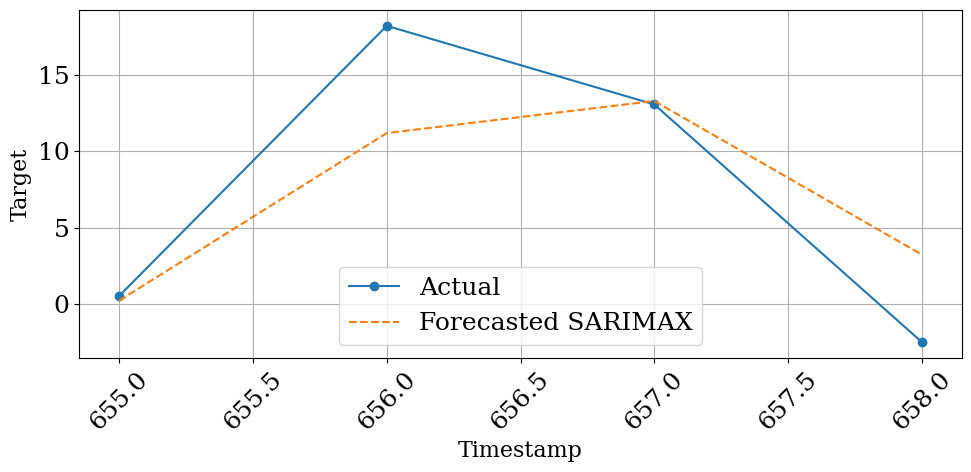

(3.3119393214405415, 0.8206437125196556)

In [175]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt


# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(1, 0, 0), 
                seasonal_order=(1, 0, 1, 8), 
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
sarima_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics
sarima_mse = mean_absolute_error(test_data['Target'], sarima_predictions)
sarima_mape = mean_absolute_percentage_error(test_data['Target'], sarima_predictions)

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(test_data.index, test_data['Target'], label='Actual', marker='o')
plt.plot(test_data.index, sarima_predictions, label='Forecasted SARIMAX', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Output the MSE and MAPE values
sarima_mse, sarima_mape


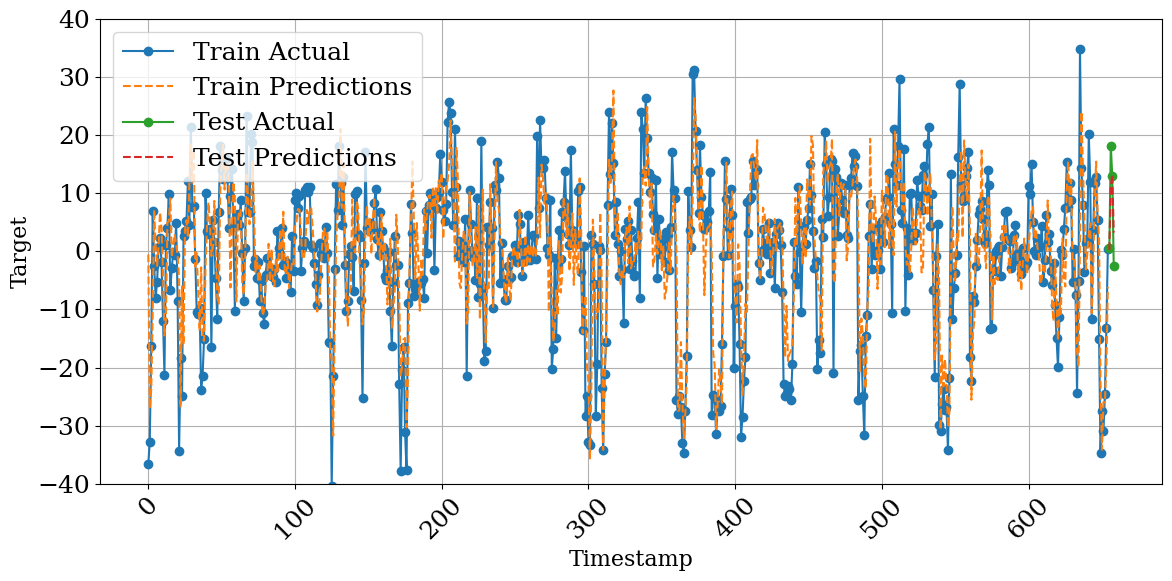

Train MAE: 6.1126
Train MAPE: 4.6437
Test MAE: 3.3119
Test MAPE: 0.8206


In [176]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(1, 0, 0), 
                seasonal_order=(1, 0, 1, 8), 
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# In-sample predictions for the training set
train_predictions = sarimax_results.predict(start=train_data.index[0], 
                                             end=train_data.index[-1], 
                                             exog=exog_train)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
test_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics for the training set
train_mae = mean_absolute_error(train_data['Target'], train_predictions)
train_mape = mean_absolute_percentage_error(train_data['Target'], train_predictions)

# Calculate evaluation metrics for the test set
test_mae = mean_absolute_error(test_data['Target'], test_predictions)
test_mape = mean_absolute_percentage_error(test_data['Target'], test_predictions)

# Plot the results: actual and predictions for both train and test data
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data['Target'], label='Train Actual', marker='o')
plt.plot(train_data.index, train_predictions, label='Train Predictions', linestyle='--')
plt.plot(test_data.index, test_data['Target'], label='Test Actual', marker='o')
plt.plot(test_data.index, test_predictions, label='Test Predictions', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(-40, 40)
plt.show()

# Output the evaluation metrics
print("Train MAE: {:.4f}".format(train_mae))
print("Train MAPE: {:.4f}".format(train_mape))
print("Test MAE: {:.4f}".format(test_mae))
print("Test MAPE: {:.4f}".format(test_mape))


   Combined_Sum
0     40.350514
1     51.996597
2     50.896161
3     33.542535
MAE: 3.77
MAPE: 9.87%


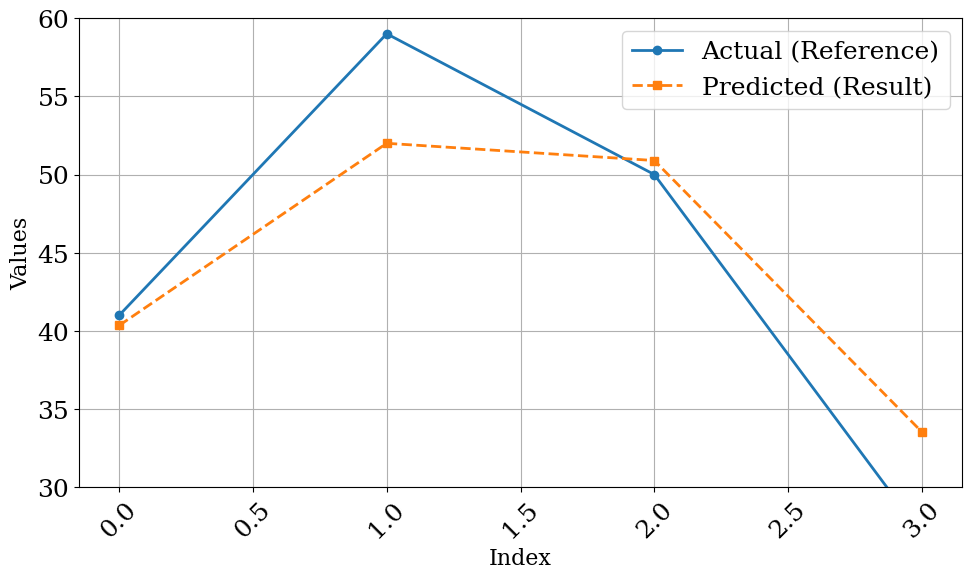

In [177]:
# Convert the DataFrames to NumPy arrays
sarimax_forecast_array = sarima_predictions.to_numpy().flatten()
summed_up_array = summed_up.to_numpy().flatten()

# Ensure both arrays have the same length
min_length = min(len(sarimax_forecast_array), len(summed_up_array))
sarimax_forecast_array = sarimax_forecast_array[:min_length]
summed_up_array = summed_up_array[:min_length]

# Perform element-wise summation
combined_sum_array = sarimax_forecast_array + summed_up_array

# Convert the result back to a DataFrame (optional)
result_df = pd.DataFrame(combined_sum_array, columns=['Combined_Sum'])

# Print the resulting DataFrame
print(result_df)

# Reset the index of the reference DataFrame
reference = reference.reset_index(drop=True)

# Ensure alignment of lengths
min_length = min(len(result_df), len(reference))
predicted = result_df.iloc[:min_length]['Combined_Sum']
test = reference.iloc[:min_length].squeeze()

# Calculate MAE and MAPE
mae = mean_absolute_error(test, predicted)
mape = mean_absolute_percentage_error(test, predicted)

# Print MAE and MAPE
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2%}")

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(test.index, test, label='Actual (Reference)', marker='o', linestyle='-', linewidth=2)
plt.plot(predicted.index, predicted, label='Predicted (Result)', marker='s', linestyle='--', linewidth=2)
 
plt.xlabel('Index')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(30, 60)
plt.show()


In [178]:
end_time=time.time()

In [179]:
Cost = end_time - start_time

In [180]:
main_results = update_results(main_results, 'SARIMA W RFE + PSO BEST FEATUREs', mae, mape,Cost)

In [181]:
main_results

,Model_Name,MAE,MAPE,Cost
0,BASE SARIMA WITHOUT DECOMPOSITION,14.107829,0.293031,33.096646
1,BASE AUTO SARIMA WITHOUT DECOMPOSITION,12.438014,0.290428,66.778659
2,SARIMA by DECOMPOSITION W NO FEATURE,3.883099,0.104131,6.707407
3,AUTO SARIMA BY DECOMPOSITION W NO FEATURE,7.025086,0.172624,39.854797
4,Topological Dataset,0,0,0
5,SARIMA W ALL FEATUREs,19.445691,0.514501,100.935903
6,SARIMA W RFE FEATUREs,6.038522,0.175575,420.725752
7,SARIMA W RFE + PSO FEATUREs,3.772896,0.098696,11.606659
8,SARIMA W RFE + PSO BEST FEATUREs,3.772896,0.098696,5.616401


# MODEL 5-1 : FEATURE SELECTION REGRESSION ANALYSIS

In [182]:
data

,entropy_0,entropy_1,amplitude_bottleneck_0,amplitude_wasserstein_0,betti_L1_H0,betti_L2_H0,betti_L1_H1,betti_L2_H1,landscape_features_L1_H0_LS,silhouette_features_L1_H0_SI,...,Col95_L1_H1,Col96_L1_H1,Col97_L2_H1,Col99_L2_H1,dim_0_median_lifetime,dim_0_std_lifetime,dim_0_carlsson_f2,dim_0_carlsson_f4,dim_1_mean_death_time,Target
0,0.939849,0.0,0.098614,0.159809,0.167857,0.289040,0.0,0.0,0.023583,0.030416,...,0.0,0.0,0.0,0.0,0.224633,0.047735,0.024870,0.000096,0.0,-36.630516
1,0.452725,0.0,0.675501,0.536220,0.389286,0.389639,0.0,0.0,0.490589,0.469574,...,0.0,0.0,0.0,0.0,0.248784,0.661514,0.427005,0.034430,0.0,-32.755274
2,0.502780,0.0,0.613014,0.488256,0.360714,0.379624,0.0,0.0,0.412899,0.384258,...,0.0,0.0,0.0,0.0,0.248784,0.589904,0.377790,0.025140,0.0,-16.242944
3,0.861676,0.0,0.270372,0.346603,0.339286,0.458352,0.0,0.0,0.103865,0.113383,...,0.0,0.0,0.0,0.0,0.269650,0.223178,0.124355,0.003521,0.0,6.891582
4,0.788548,0.0,0.420537,0.481523,0.453571,0.529010,0.0,0.0,0.214931,0.208197,...,0.0,0.0,0.0,0.0,0.284929,0.371510,0.258185,0.028176,0.0,-2.448256
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
654,0.945979,0.0,0.475822,0.733742,0.767857,0.888381,0.0,0.0,0.265386,0.317799,...,0.0,0.0,0.0,0.0,0.768420,0.274130,0.300708,0.081951,0.0,0.412770
655,0.964603,0.0,0.475822,0.715284,0.757143,0.898200,0.0,0.0,0.265386,0.298549,...,0.0,0.0,0.0,0.0,0.737455,0.223922,0.323379,0.093785,0.0,0.543904
656,0.930971,0.0,0.475822,0.690709,0.717857,0.839722,0.0,0.0,0.265386,0.294672,...,0.0,0.0,0.0,0.0,0.673147,0.291769,0.321191,0.085645,0.0,18.180364
657,0.916975,0.0,0.489660,0.778191,0.803571,0.894935,0.0,0.0,0.278788,0.364374,...,0.0,0.0,0.0,0.0,0.818619,0.355092,0.281144,0.078994,0.0,13.045591


In [183]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from xgboost import XGBRegressor

start_time=time.time()

# Step 1: Split the data
train_data = data[:-4]
test_data = data[-4:]

X_train = train_data.drop(columns=["Target"])
X_test = test_data.drop(columns=["Target"])
y_train = train_data["Target"]
y_test = test_data["Target"]

from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

In [184]:
from sklearn.ensemble import RandomForestRegressor
import numpy as np

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Get top k important features
importances = pd.Series(model.feature_importances_, index=X_train.columns)
selected_features = importances.sort_values(ascending=False).head(50).index  # choose top 20 or tune

X_train = X_train[selected_features]
X_test = X_test[selected_features]


In [185]:
X_train

,entropy_0,Col8_L1_H0,Col6_L1_H0,L1_H0,dim_0_median_lifetime,Col5_L1_H0,dim_0_carlsson_f2,Col7_L1_H0,Col36_L2_H0,Col8_L2_H0,...,Col31_L2_H0,Col52_L2_H0,silhouette_features_L2_H0_SI,Col26_L2_H0,Col44_L2_H0,landscape_features_L1_H0_LS,Col28_L1_H0,Col29_L2_H0,Col14_L2_H0,dim_1_mean_death_time
0,0.939849,0.861010,0.873733,0.671865,0.224633,0.828142,0.024870,0.873505,0.000208,0.757116,...,0.007831,0.000000,0.066801,0.089779,0.000000,0.023583,0.035906,0.021975,0.844892,0.000000
1,0.452725,0.761852,0.916890,0.784918,0.248784,0.915081,0.427005,0.844655,0.000208,0.568949,...,0.007831,0.000922,0.547146,0.089641,0.000000,0.490589,0.035906,0.021975,0.786689,0.000000
2,0.502780,0.802653,0.925529,0.777805,0.248784,0.915486,0.377790,0.868392,0.000065,0.607521,...,0.004719,0.028426,0.462311,0.066287,0.000202,0.412899,0.024567,0.014434,0.810926,0.000000
3,0.861676,0.621735,0.929920,0.884161,0.269650,0.977780,0.124355,0.778318,0.299287,0.389408,...,0.481976,0.000096,0.183878,0.313651,0.027041,0.103865,0.362380,0.399242,0.734958,0.000000
4,0.788548,0.507813,0.907276,0.903267,0.284929,0.976562,0.258185,0.714620,0.328704,0.260333,...,0.483755,0.161162,0.300801,0.302140,0.321146,0.214931,0.358739,0.397632,0.569684,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
650,0.853291,0.114173,0.841102,0.996873,0.587193,0.994317,0.465528,0.495692,0.189556,0.061325,...,0.360867,0.417386,0.515333,0.639580,0.449869,0.383534,0.510099,0.451808,0.140132,0.000000
651,0.905643,0.114082,0.841102,0.996894,0.653755,0.994317,0.294756,0.495692,0.347428,0.083447,...,0.413967,0.417386,0.426964,0.569965,0.770091,0.256141,0.476288,0.443127,0.137665,0.455986
652,0.744530,0.108348,0.832453,0.990582,0.653755,0.985712,1.000000,0.487959,0.343281,0.057850,...,0.413815,0.107932,0.729068,0.569965,0.617013,0.839064,0.476288,0.443127,0.137547,0.000000
653,0.931150,0.105247,0.839792,0.998056,0.905104,0.994068,0.288312,0.491658,0.479192,0.089087,...,0.413884,0.465348,0.476009,0.440937,1.000000,0.265386,0.404196,0.395655,0.077320,0.000000


In [186]:
import warnings
warnings.filterwarnings("ignore")  # Suppress all warnings

from sklearn.linear_model import Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, make_scorer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import pandas as pd
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
# Optional: scale for SVR and other sensitive models
scaler = StandardScaler()


tscv = TimeSeriesSplit(n_splits=5)

# Step 1: Define models and their hyperparameter grids
models = {
    "Lasso": (Lasso(), {
        "alpha": [0.001, 0.01, 0.1, 1, 10]
    }),
    "ElasticNet": (ElasticNet(), {
        "alpha": [0.001, 0.01, 0.1, 1, 10],
        "l1_ratio": [0.1, 0.5, 0.9]
    }),
    "RandomForest": (RandomForestRegressor(), {
        "n_estimators": [100, 200],
        "max_depth": [None, 10, 20]
    }),
    "XGBoost": (XGBRegressor(verbosity=0), {
        "n_estimators": [100, 200],
        "learning_rate": [0.01, 0.1],
        "max_depth": [3, 6]
    }),
    
    "CatBoost": (CatBoostRegressor(verbose=0), {
        "iterations": [100, 200],
        "learning_rate": [0.01, 0.1],
        "depth": [3, 6]
    }),
    "GradientBoosting": (GradientBoostingRegressor(), {
        "n_estimators": [100, 200],
        "learning_rate": [0.01, 0.1],
        "max_depth": [3, 6]
    }),
    "SVR": (Pipeline([
        ('scaler', StandardScaler()),
        ('svr', SVR())
    ]), {
        "svr__C": [0.1, 1, 10],
        "svr__epsilon": [0.01, 0.1]
    })
}

results = []

# Step 2: Run grid search and evaluate
for name, (model, param_grid) in models.items():
    print(f"🔍 Tuning {name}...")

    grid = GridSearchCV(model, param_grid, cv=tscv, scoring=make_scorer(mean_absolute_error, greater_is_better=False), n_jobs=-1)
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    preds = best_model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    mape = mean_absolute_percentage_error(y_test, preds)

    results.append({
        "Model": name,
        "MAE": mae,
        "MAPE": mape,
        "ModelObject": best_model,
        "BestParams": grid.best_params_
    })

# Step 3: Choose the best model based on MAE, then MAPE
results_df = pd.DataFrame(results).sort_values(by=["MAE", "MAPE"])
best = results_df.iloc[0]
best_model = best["ModelObject"]

print("✅ Best Model:", best["Model"])
print("🔹 MAE:", best["MAE"])
print("🔹 MAPE:", best["MAPE"])
print("🎯 Best Params:", best["BestParams"])


🔍 Tuning Lasso...
🔍 Tuning ElasticNet...
🔍 Tuning RandomForest...
🔍 Tuning XGBoost...
🔍 Tuning CatBoost...
🔍 Tuning GradientBoosting...
🔍 Tuning SVR...
✅ Best Model: SVR
🔹 MAE: 8.246151256690789
🔹 MAPE: 1.3132668880313632
🎯 Best Params: {'svr__C': 0.1, 'svr__epsilon': 0.01}


<Figure size 1400x600 with 0 Axes>

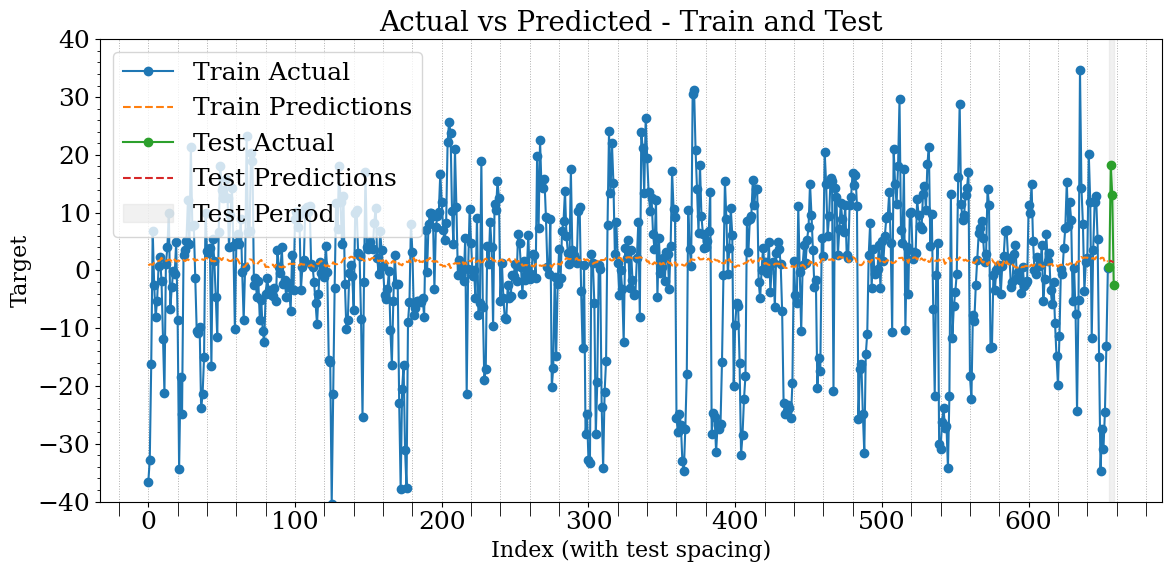

Train MAE: 9.3272
Train MAPE: 2.4127
Test MAE: 8.2462
Test MAPE: 1.3133


In [187]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# Train the best ML model on the training data

best_model.fit(X_train, y_train)

# In-sample predictions for the training set
train_predictions = best_model.predict(X_train)

# Forecasting for the test set
test_predictions = best_model.predict(X_test)

# Calculate evaluation metrics for the training set
train_mae = mean_absolute_error(y_train, train_predictions)
train_mape = mean_absolute_percentage_error(y_train, train_predictions)

# Calculate evaluation metrics for the test set
test_mae = mean_absolute_error(y_test, test_predictions)
test_mape = mean_absolute_percentage_error(y_test, test_predictions)


plt.figure(figsize=(14, 6))

# Convert index to a numeric range for controlled spacing
train_x = np.arange(len(train_data))
test_x = np.arange(len(test_data))  + len(train_data)  # 5x spacing and offset after train

# Plot actual and predicted values
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data['Target'], label='Train Actual', marker='o')
plt.plot(train_data.index, train_predictions, label='Train Predictions', linestyle='--')
plt.plot(test_data.index, test_data['Target'], label='Test Actual', marker='o')
plt.plot(test_data.index, test_predictions, label='Test Predictions', linestyle='--')

# Highlight the test period
plt.axvspan(test_x[0], test_x[-1], color='lightgray', alpha=0.3, label='Test Period')

# Make gridlines denser
plt.minorticks_on()
plt.grid(which='both', axis='x', linestyle=':', linewidth=0.7)
plt.tick_params(axis='x', which='minor', length=10)

# Add labels and legend
plt.xlabel('Index (with test spacing)')
plt.ylabel('Target')
plt.title('Actual vs Predicted - Train and Test')
plt.legend(loc='upper left')  # 👈 Changed legend position here
plt.tight_layout()
plt.ylim(-40, 40)
plt.show()

# Output the evaluation metrics
print("Train MAE: {:.4f}".format(train_mae))
print("Train MAPE: {:.4f}".format(train_mape))
print("Test MAE: {:.4f}".format(test_mae))
print("Test MAPE: {:.4f}".format(test_mape))


   Combined_Sum
0     41.676241
1     42.494190
2     39.142336
3     31.768320
MAE: 8.20
MAPE: 17.25%


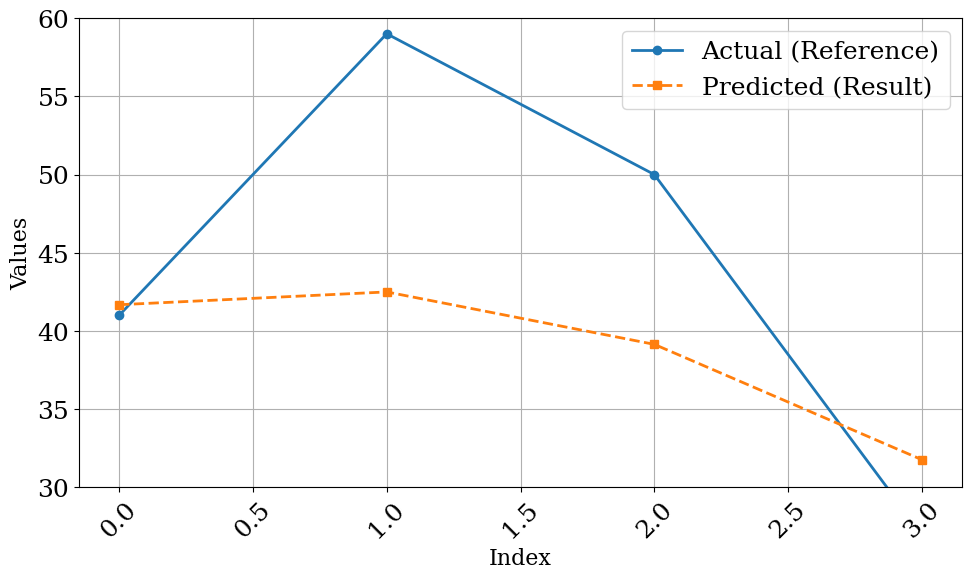

In [188]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# Fit the best model on the training data (exogenous features)
best_model.fit(X_train, y_train)

# Make predictions on the test set
predictions = best_model.predict(X_test)

# Convert the DataFrames to NumPy arrays
predictions_array = predictions.flatten()
summed_up_array = summed_up.to_numpy().flatten()

# Ensure both arrays have the same length
min_length = min(len(predictions_array), len(summed_up_array))
predictions_array = predictions_array[:min_length]
summed_up_array = summed_up_array[:min_length]

# Perform element-wise summation
combined_sum_array = predictions_array + summed_up_array

# Convert the result back to a DataFrame (optional)
result_df = pd.DataFrame(combined_sum_array, columns=['Combined_Sum'])

# Print the resulting DataFrame
print(result_df)

# Reset the index of the reference DataFrame
reference = reference.reset_index(drop=True)

# Ensure alignment of lengths
min_length = min(len(result_df), len(reference))
predicted = result_df.iloc[:min_length]['Combined_Sum']
test = reference.iloc[:min_length].squeeze()

# Calculate MAE and MAPE
mae = mean_absolute_error(test, predicted)
mape = mean_absolute_percentage_error(test, predicted)

# Print MAE and MAPE
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2%}")

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(test.index, test, label='Actual (Reference)', marker='o', linestyle='-', linewidth=2)
plt.plot(predicted.index, predicted, label='Predicted (Result)', marker='s', linestyle='--', linewidth=2)

plt.xlabel('Index')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(30, 60)
plt.show()




In [189]:
end_time=time.time()

In [190]:
Cost=end_time-start_time

In [191]:
main_results = update_results(main_results, 'Regression Model W SELECTED FEATURES', mae, mape, Cost)

In [192]:
main_results

,Model_Name,MAE,MAPE,Cost
0,BASE SARIMA WITHOUT DECOMPOSITION,14.107829,0.293031,33.096646
1,BASE AUTO SARIMA WITHOUT DECOMPOSITION,12.438014,0.290428,66.778659
2,SARIMA by DECOMPOSITION W NO FEATURE,3.883099,0.104131,6.707407
3,AUTO SARIMA BY DECOMPOSITION W NO FEATURE,7.025086,0.172624,39.854797
4,Topological Dataset,0,0,0
5,SARIMA W ALL FEATUREs,19.445691,0.514501,100.935903
6,SARIMA W RFE FEATUREs,6.038522,0.175575,420.725752
7,SARIMA W RFE + PSO FEATUREs,3.772896,0.098696,11.606659
8,SARIMA W RFE + PSO BEST FEATUREs,3.772896,0.098696,5.616401
9,Regression Model W SELECTED FEATURES,8.202009,0.172503,313.378184


# MODEL 5 : ALL FEATURES REGRESSION ANALYSIS

In [193]:
data

,entropy_0,entropy_1,amplitude_bottleneck_0,amplitude_wasserstein_0,betti_L1_H0,betti_L2_H0,betti_L1_H1,betti_L2_H1,landscape_features_L1_H0_LS,silhouette_features_L1_H0_SI,...,Col95_L1_H1,Col96_L1_H1,Col97_L2_H1,Col99_L2_H1,dim_0_median_lifetime,dim_0_std_lifetime,dim_0_carlsson_f2,dim_0_carlsson_f4,dim_1_mean_death_time,Target
0,0.939849,0.0,0.098614,0.159809,0.167857,0.289040,0.0,0.0,0.023583,0.030416,...,0.0,0.0,0.0,0.0,0.224633,0.047735,0.024870,0.000096,0.0,-36.630516
1,0.452725,0.0,0.675501,0.536220,0.389286,0.389639,0.0,0.0,0.490589,0.469574,...,0.0,0.0,0.0,0.0,0.248784,0.661514,0.427005,0.034430,0.0,-32.755274
2,0.502780,0.0,0.613014,0.488256,0.360714,0.379624,0.0,0.0,0.412899,0.384258,...,0.0,0.0,0.0,0.0,0.248784,0.589904,0.377790,0.025140,0.0,-16.242944
3,0.861676,0.0,0.270372,0.346603,0.339286,0.458352,0.0,0.0,0.103865,0.113383,...,0.0,0.0,0.0,0.0,0.269650,0.223178,0.124355,0.003521,0.0,6.891582
4,0.788548,0.0,0.420537,0.481523,0.453571,0.529010,0.0,0.0,0.214931,0.208197,...,0.0,0.0,0.0,0.0,0.284929,0.371510,0.258185,0.028176,0.0,-2.448256
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
654,0.945979,0.0,0.475822,0.733742,0.767857,0.888381,0.0,0.0,0.265386,0.317799,...,0.0,0.0,0.0,0.0,0.768420,0.274130,0.300708,0.081951,0.0,0.412770
655,0.964603,0.0,0.475822,0.715284,0.757143,0.898200,0.0,0.0,0.265386,0.298549,...,0.0,0.0,0.0,0.0,0.737455,0.223922,0.323379,0.093785,0.0,0.543904
656,0.930971,0.0,0.475822,0.690709,0.717857,0.839722,0.0,0.0,0.265386,0.294672,...,0.0,0.0,0.0,0.0,0.673147,0.291769,0.321191,0.085645,0.0,18.180364
657,0.916975,0.0,0.489660,0.778191,0.803571,0.894935,0.0,0.0,0.278788,0.364374,...,0.0,0.0,0.0,0.0,0.818619,0.355092,0.281144,0.078994,0.0,13.045591


In [194]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from xgboost import XGBRegressor

start_time=time.time()

# Step 1: Split the data
train_data = data[:-4]
test_data = data[-4:]

X_train = train_data.drop(columns=["Target"])
X_test = test_data.drop(columns=["Target"])
y_train = train_data["Target"]
y_test = test_data["Target"]

In [195]:
import warnings
warnings.filterwarnings("ignore")  # Suppress all warnings

from sklearn.linear_model import Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, make_scorer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import pandas as pd
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
# Optional: scale for SVR and other sensitive models
scaler = StandardScaler()


tscv = TimeSeriesSplit(n_splits=5)

# Step 1: Define models and their hyperparameter grids
models = {
    "Lasso": (Lasso(), {
        "alpha": [0.001, 0.01, 0.1, 1, 10]
    }),
    "ElasticNet": (ElasticNet(), {
        "alpha": [0.001, 0.01, 0.1, 1, 10],
        "l1_ratio": [0.1, 0.5, 0.9]
    }),
    "RandomForest": (RandomForestRegressor(), {
        "n_estimators": [100, 200],
        "max_depth": [None, 10, 20]
    }),
    "XGBoost": (XGBRegressor(verbosity=0), {
        "n_estimators": [100, 200],
        "learning_rate": [0.01, 0.1],
        "max_depth": [3, 6]
    }),
    
    "CatBoost": (CatBoostRegressor(verbose=0), {
        "iterations": [100, 200],
        "learning_rate": [0.01, 0.1],
        "depth": [3, 6]
    }),
    "GradientBoosting": (GradientBoostingRegressor(), {
        "n_estimators": [100, 200],
        "learning_rate": [0.01, 0.1],
        "max_depth": [3, 6]
    }),
    "SVR": (Pipeline([
        ('scaler', StandardScaler()),
        ('svr', SVR())
    ]), {
        "svr__C": [0.1, 1, 10],
        "svr__epsilon": [0.01, 0.1]
    })
}

results = []

# Step 2: Run grid search and evaluate
for name, (model, param_grid) in models.items():
    print(f"🔍 Tuning {name}...")

    grid = GridSearchCV(model, param_grid, cv=tscv, scoring=make_scorer(mean_absolute_error, greater_is_better=False), n_jobs=-1)
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    preds = best_model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    mape = mean_absolute_percentage_error(y_test, preds)

    results.append({
        "Model": name,
        "MAE": mae,
        "MAPE": mape,
        "ModelObject": best_model,
        "BestParams": grid.best_params_
    })

# Step 3: Choose the best model based on MAE, then MAPE
results_df = pd.DataFrame(results).sort_values(by=["MAE", "MAPE"])
best = results_df.iloc[0]
best_model = best["ModelObject"]

print("✅ Best Model:", best["Model"])
print("🔹 MAE:", best["MAE"])
print("🔹 MAPE:", best["MAPE"])
print("🎯 Best Params:", best["BestParams"])


🔍 Tuning Lasso...
🔍 Tuning ElasticNet...
🔍 Tuning RandomForest...
🔍 Tuning XGBoost...
🔍 Tuning CatBoost...
🔍 Tuning GradientBoosting...
🔍 Tuning SVR...
✅ Best Model: SVR
🔹 MAE: 8.295203348552874
🔹 MAPE: 1.2764534868922623
🎯 Best Params: {'svr__C': 0.1, 'svr__epsilon': 0.01}


<Figure size 1400x600 with 0 Axes>

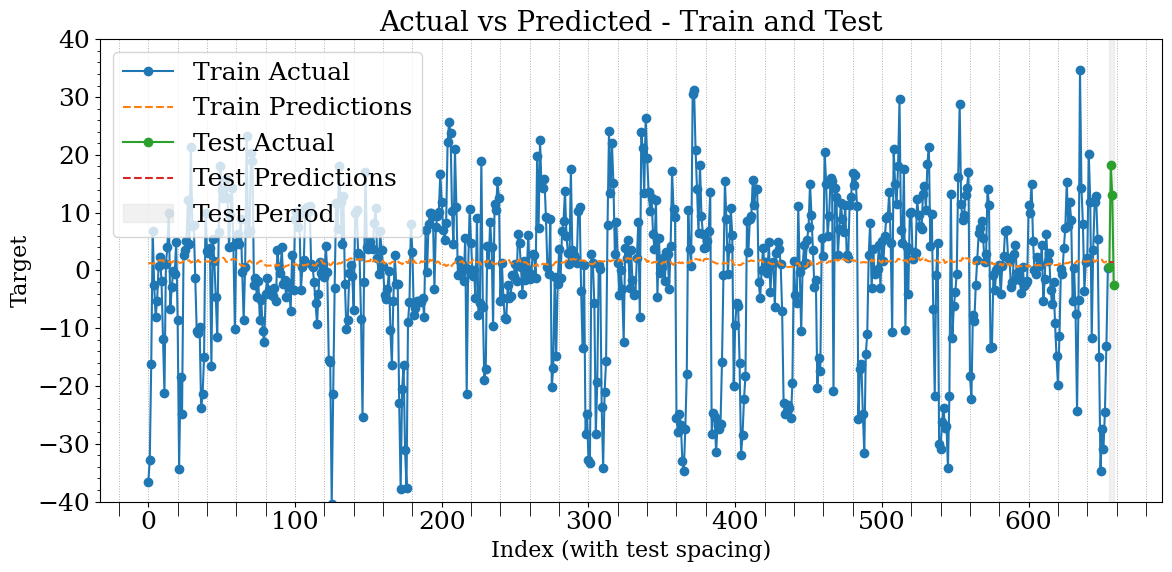

Train MAE: 9.3441
Train MAPE: 2.3447
Test MAE: 8.2952
Test MAPE: 1.2765


In [196]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# Train the best ML model on the training data

best_model.fit(X_train, y_train)

# In-sample predictions for the training set
train_predictions = best_model.predict(X_train)

# Forecasting for the test set
test_predictions = best_model.predict(X_test)

# Calculate evaluation metrics for the training set
train_mae = mean_absolute_error(y_train, train_predictions)
train_mape = mean_absolute_percentage_error(y_train, train_predictions)

# Calculate evaluation metrics for the test set
test_mae = mean_absolute_error(y_test, test_predictions)
test_mape = mean_absolute_percentage_error(y_test, test_predictions)


plt.figure(figsize=(14, 6))

# Convert index to a numeric range for controlled spacing
train_x = np.arange(len(train_data))
test_x = np.arange(len(test_data))  + len(train_data)  # 5x spacing and offset after train

# Plot actual and predicted values
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data['Target'], label='Train Actual', marker='o')
plt.plot(train_data.index, train_predictions, label='Train Predictions', linestyle='--')
plt.plot(test_data.index, test_data['Target'], label='Test Actual', marker='o')
plt.plot(test_data.index, test_predictions, label='Test Predictions', linestyle='--')

# Highlight the test period
plt.axvspan(test_x[0], test_x[-1], color='lightgray', alpha=0.3, label='Test Period')

# Make gridlines denser
plt.minorticks_on()
plt.grid(which='both', axis='x', linestyle=':', linewidth=0.7)
plt.tick_params(axis='x', which='minor', length=10)

# Add labels and legend
plt.xlabel('Index (with test spacing)')
plt.ylabel('Target')
plt.title('Actual vs Predicted - Train and Test')
plt.legend(loc='upper left')  # 👈 Changed legend position here
plt.tight_layout()
plt.ylim(-40, 40)
plt.show()

# Output the evaluation metrics
print("Train MAE: {:.4f}".format(train_mae))
print("Train MAPE: {:.4f}".format(train_mape))
print("Test MAE: {:.4f}".format(test_mae))
print("Test MAPE: {:.4f}".format(test_mape))


   Combined_Sum
0     41.589279
1     42.292742
2     39.046250
3     31.753956
MAE: 8.25
MAPE: 17.32%


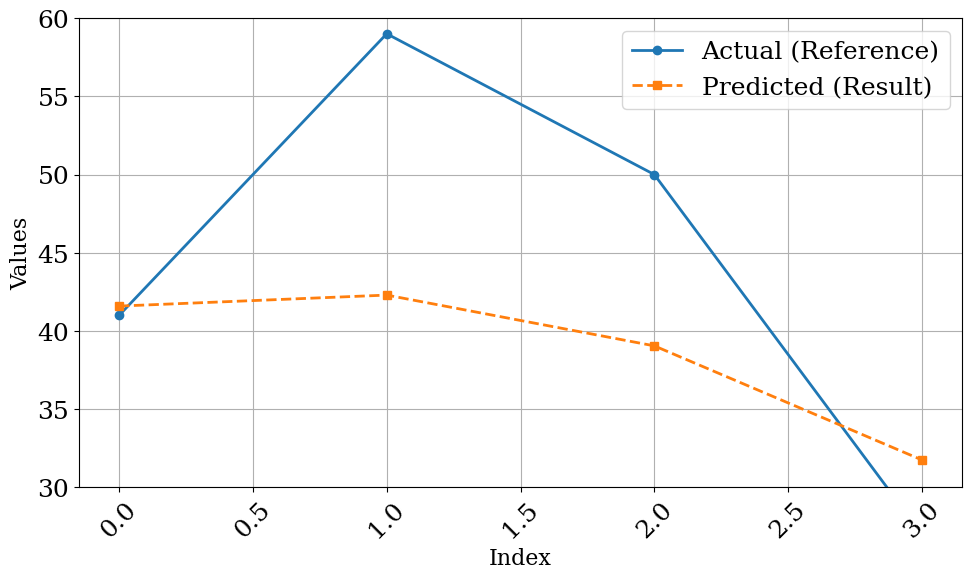

In [197]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# Fit the best model on the training data (exogenous features)
best_model.fit(X_train, y_train)

# Make predictions on the test set
predictions = best_model.predict(X_test)

# Convert the DataFrames to NumPy arrays
predictions_array = predictions.flatten()
summed_up_array = summed_up.to_numpy().flatten()

# Ensure both arrays have the same length
min_length = min(len(predictions_array), len(summed_up_array))
predictions_array = predictions_array[:min_length]
summed_up_array = summed_up_array[:min_length]

# Perform element-wise summation
combined_sum_array = predictions_array + summed_up_array

# Convert the result back to a DataFrame (optional)
result_df = pd.DataFrame(combined_sum_array, columns=['Combined_Sum'])

# Print the resulting DataFrame
print(result_df)

# Reset the index of the reference DataFrame
reference = reference.reset_index(drop=True)

# Ensure alignment of lengths
min_length = min(len(result_df), len(reference))
predicted = result_df.iloc[:min_length]['Combined_Sum']
test = reference.iloc[:min_length].squeeze()

# Calculate MAE and MAPE
mae = mean_absolute_error(test, predicted)
mape = mean_absolute_percentage_error(test, predicted)

# Print MAE and MAPE
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2%}")

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(test.index, test, label='Actual (Reference)', marker='o', linestyle='-', linewidth=2)
plt.plot(predicted.index, predicted, label='Predicted (Result)', marker='s', linestyle='--', linewidth=2)

plt.xlabel('Index')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(30, 60)
plt.show()




In [198]:
end_time=time.time()

In [199]:
Cost=end_time-start_time

In [200]:
main_results = update_results(main_results, 'Regression Model All', mae, mape, Cost)

In [201]:
main_results

,Model_Name,MAE,MAPE,Cost
0,BASE SARIMA WITHOUT DECOMPOSITION,14.107829,0.293031,33.096646
1,BASE AUTO SARIMA WITHOUT DECOMPOSITION,12.438014,0.290428,66.778659
2,SARIMA by DECOMPOSITION W NO FEATURE,3.883099,0.104131,6.707407
3,AUTO SARIMA BY DECOMPOSITION W NO FEATURE,7.025086,0.172624,39.854797
4,Topological Dataset,0,0,0
5,SARIMA W ALL FEATUREs,19.445691,0.514501,100.935903
6,SARIMA W RFE FEATUREs,6.038522,0.175575,420.725752
7,SARIMA W RFE + PSO FEATUREs,3.772896,0.098696,11.606659
8,SARIMA W RFE + PSO BEST FEATUREs,3.772896,0.098696,5.616401
9,Regression Model W SELECTED FEATURES,8.202009,0.172503,313.378184


# MODEL 6 HYBRID MODEL REGRESSION AND SARIMA

In [202]:
start_time=time.time()

In [203]:
# Step 4: Apply best model to the entire dataset
X_all = data.drop(columns=["Target"])
y_all = data["Target"]
preds_all = best_model.predict(X_all)

In [204]:
# Step 5: Create the difference DataFrame
diff_df = pd.DataFrame({
    "Actual": y_all.values,
    "Predicted": preds_all,
    "Difference": y_all.values - preds_all
}, index=data.index)

In [205]:
# Step 1: Create a new column 'Target' from the residuals
diff_df['Target'] = diff_df['Difference']

# Step 2: Split the data into train and test
y_train = diff_df[:-4]
y_test = diff_df[-4:]

In [206]:
from statsmodels.tsa.stattools import kpss

# Applying the KPSS test to the training data to test for stationarity
kpss_test = kpss(y_train['Target'], regression='c')

# Unpacking the KPSS test results
kpss_statistic, p_value, lags, critical_values = kpss_test

# Displaying the KPSS test results
kpss_test_result = {
    'KPSS Statistic': kpss_statistic,
    'p-value': p_value,
    'Lags Used': lags,
    'Critical Values': critical_values,
    'Conclusion': 'Stationary' if p_value > 0.05 else 'Not stationary'
}

kpss_test_result


{'KPSS Statistic': 0.03379901443596034,
 'p-value': 0.1,
 'Lags Used': 13,
 'Critical Values': {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739},
 'Conclusion': 'Stationary'}

In [207]:
from pmdarima.arima import auto_arima, OCSBTest, CHTest

# time series after first differencing
# OCSB test that returns the recommended order of seasonal differencing:
n_ocsb = OCSBTest(m=12).estimate_seasonal_differencing_term(y_train['Target'])

# CH test that returns the recommended order of seasonal differencing:
n_ch = CHTest(m=12).estimate_seasonal_differencing_term(y_train['Target'])

# seasonal differencing recommendation:
print("time series -")
n_seasdiffs = {"recommended order of seasonal differencing":"", "OCSB recommendation":n_ocsb, "nCH recommendation":n_ch}
[print(key, ":", value) for key,value in n_seasdiffs.items()]

time series -
recommended order of seasonal differencing : 
OCSB recommendation : 0
nCH recommendation : 0


[None, None, None]

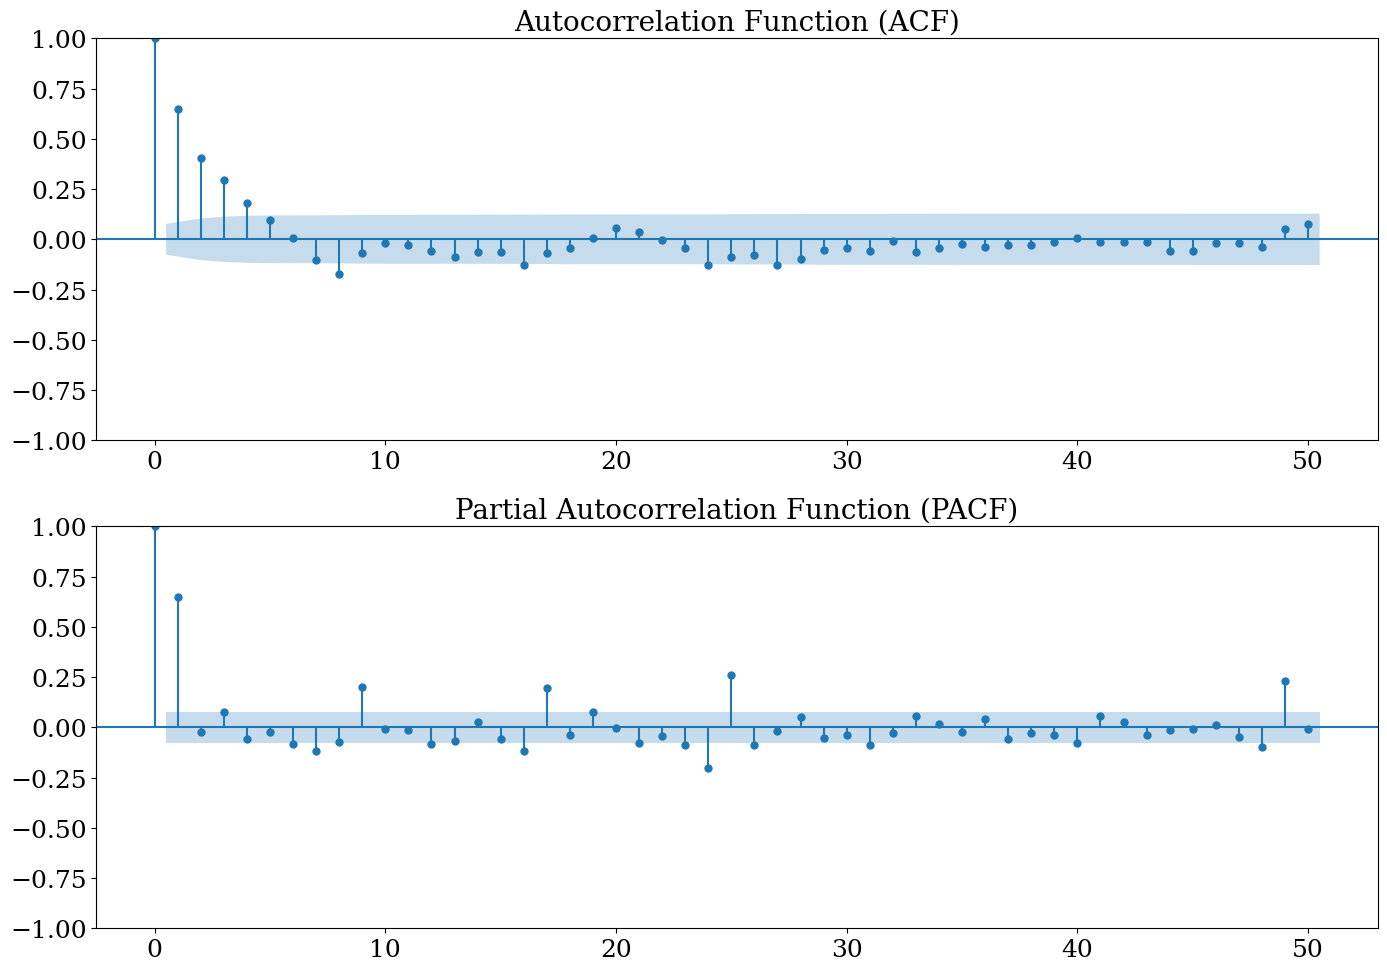

In [208]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot ACF and PACF for the cleaned training data
plt.figure(figsize=(14, 10))

# ACF plot
plt.subplot(2, 1, 1)
plot_acf(y_train['Target'], lags=50, ax=plt.gca())
plt.title("Autocorrelation Function (ACF)")

# PACF plot
plt.subplot(2, 1, 2)
plot_pacf(y_train['Target'], lags=50, ax=plt.gca(), method='ywm')
plt.title("Partial Autocorrelation Function (PACF)")

# Save the figure as an SVG file
plt.savefig("acf_h1.svg", format="svg", dpi=900, bbox_inches='tight', facecolor='white')
plt.tight_layout()
plt.show()

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[8] intercept   : AIC=5191.953, Time=0.03 sec
 ARIMA(1,0,0)(1,0,0)[8] intercept   : AIC=4796.395, Time=0.55 sec
 ARIMA(0,0,1)(0,0,1)[8] intercept   : AIC=4858.265, Time=0.38 sec
 ARIMA(0,0,0)(0,0,0)[8]             : AIC=5200.742, Time=0.02 sec
 ARIMA(1,0,0)(0,0,0)[8] intercept   : AIC=4834.537, Time=0.10 sec
 ARIMA(1,0,0)(2,0,0)[8] intercept   : AIC=4756.409, Time=3.16 sec
 ARIMA(1,0,0)(2,0,1)[8] intercept   : AIC=inf, Time=3.83 sec
 ARIMA(1,0,0)(1,0,1)[8] intercept   : AIC=inf, Time=1.79 sec
 ARIMA(0,0,0)(2,0,0)[8] intercept   : AIC=5155.406, Time=2.15 sec
 ARIMA(2,0,0)(2,0,0)[8] intercept   : AIC=4758.407, Time=5.24 sec
 ARIMA(1,0,1)(2,0,0)[8] intercept   : AIC=4758.407, Time=1.99 sec
 ARIMA(0,0,1)(2,0,0)[8] intercept   : AIC=4862.318, Time=1.43 sec
 ARIMA(2,0,1)(2,0,0)[8] intercept   : AIC=inf, Time=4.05 sec
 ARIMA(1,0,0)(2,0,0)[8]             : AIC=4759.060, Time=0.93 sec

Best model:  ARIMA(1,0,0)(2,0,0)[8] intercept
T

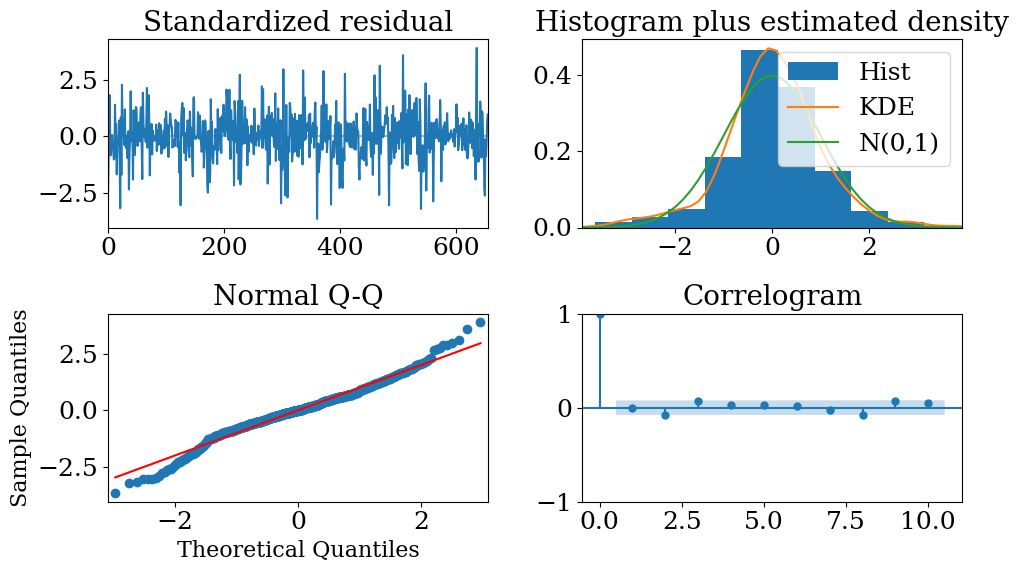

In [209]:
from pmdarima import auto_arima
import matplotlib.pyplot as plt

# Extract the time series from your training data
y_series = y_train['Target']

# Fit the seasonal ARIMA model
stepwise_model = auto_arima(
    y_series,
    start_p=0, start_q=0,
    max_p=5, max_q=5,
    seasonal=True,
    m=8,  # seasonal period
    start_P=0, start_Q=0,
    max_P=2, max_Q=2,
    d=None, D=None,           # let auto_arima figure out differencing
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True,
    information_criterion='aic'
)

# Print summary of the best model
print(stepwise_model.summary())

# Plot diagnostics
stepwise_model.plot_diagnostics(figsize=(10, 6))
plt.tight_layout()
plt.show()


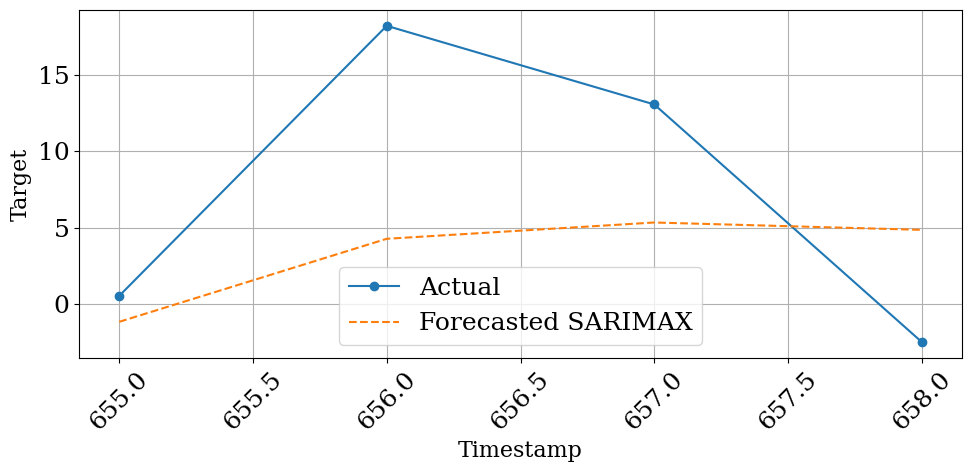

(7.658340479186477, 1.8583604823475004)

In [210]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt


n_periods = len(test_data)
sarima_predictions = stepwise_model.predict(n_periods=n_periods)

# Calculate evaluation metrics
sarima_mse = mean_absolute_error(test_data['Target'], sarima_predictions)
sarima_mape = mean_absolute_percentage_error(test_data['Target'], sarima_predictions)

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(test_data.index, test_data['Target'], label='Actual', marker='o')
plt.plot(test_data.index, sarima_predictions, label='Forecasted SARIMAX', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Output the MSE and MAPE values
sarima_mse, sarima_mape


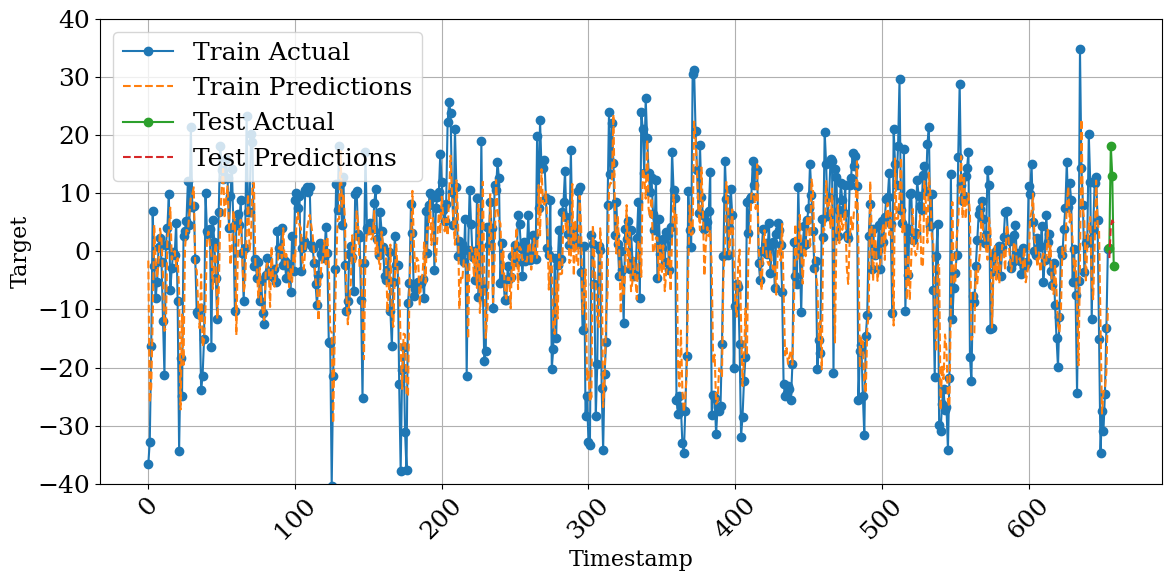

Train MAE: 6.8373
Train MAPE: 4.9152
Test MAE: 7.6583
Test MAPE: 1.8584


In [211]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# In-sample predictions for the training set
train_predictions = stepwise_model.predict_in_sample()

# Forecasting the values for the test set
test_predictions = stepwise_model.predict(n_periods=len(test_data))

# Calculate evaluation metrics for the training set
train_mae = mean_absolute_error(train_data['Target'], train_predictions)
train_mape = mean_absolute_percentage_error(train_data['Target'], train_predictions)

# Calculate evaluation metrics for the test set
test_mae = mean_absolute_error(test_data['Target'], test_predictions)
test_mape = mean_absolute_percentage_error(test_data['Target'], test_predictions)

# Plot the results: actual and predictions for both train and test data
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data['Target'], label='Train Actual', marker='o')
plt.plot(train_data.index, train_predictions, label='Train Predictions', linestyle='--')
plt.plot(test_data.index, test_data['Target'], label='Test Actual', marker='o')
plt.plot(test_data.index, test_predictions, label='Test Predictions', linestyle='--')

plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(-40, 40)
plt.show()

# Output the evaluation metrics
print("Train MAE: {:.4f}".format(train_mae))
print("Train MAPE: {:.4f}".format(train_mape))
print("Test MAE: {:.4f}".format(test_mae))
print("Test MAPE: {:.4f}".format(test_mape))


In [212]:
test_predictions

655   -1.148354
656    4.274060
657    5.338105
658    4.857213
dtype: float64

In [213]:
# Combine them into one residual prediction series
residual_prediction = pd.concat([train_predictions, test_predictions])

In [214]:
residual_prediction

0      -1.584340
1     -26.055437
2     -23.316769
3     -11.741809
4       4.546242
         ...    
654    -9.693256
655    -1.148354
656     4.274060
657     5.338105
658     4.857213
Length: 659, dtype: float64

In [215]:
# Step 2: Add SARIMA-predicted residuals to regression predictions
final_predictions = preds_all + residual_prediction

In [216]:
# Step 3: Create final DataFrame
final_df = pd.DataFrame({
    "Regression_Prediction": preds_all,
    "SARIMA_Residual_Prediction": residual_prediction,
    "Final_Prediction": final_predictions,
    "Actual": data["Target"],
    "Difference_Final": data["Target"] - final_predictions
})

# View sample
print(final_df.head())


   Regression_Prediction  SARIMA_Residual_Prediction  Final_Prediction  \
0               1.157865                   -1.584340         -0.426475   
1               1.284334                  -26.055437        -24.771103   
2               1.268827                  -23.316769        -22.047942   
3               1.137399                  -11.741809        -10.604410   
4               1.281877                    4.546242          5.828119   

      Actual  Difference_Final  
0 -36.630516        -36.204041  
1 -32.755274         -7.984171  
2 -16.242944          5.804998  
3   6.891582         17.495993  
4  -2.448256         -8.276374  


In [217]:
sarimax_forecast_array = final_df["Final_Prediction"].iloc[-4:].values
print("📦 sarimax_forecast_array:")
print(sarimax_forecast_array)


📦 sarimax_forecast_array:
[0.32492647 5.74715151 6.75984491 6.30742573]


   Combined_Sum
0     38.967644
1     45.093710
2     42.962615
3     35.160957
MAE: 7.78
MAPE: 18.21%


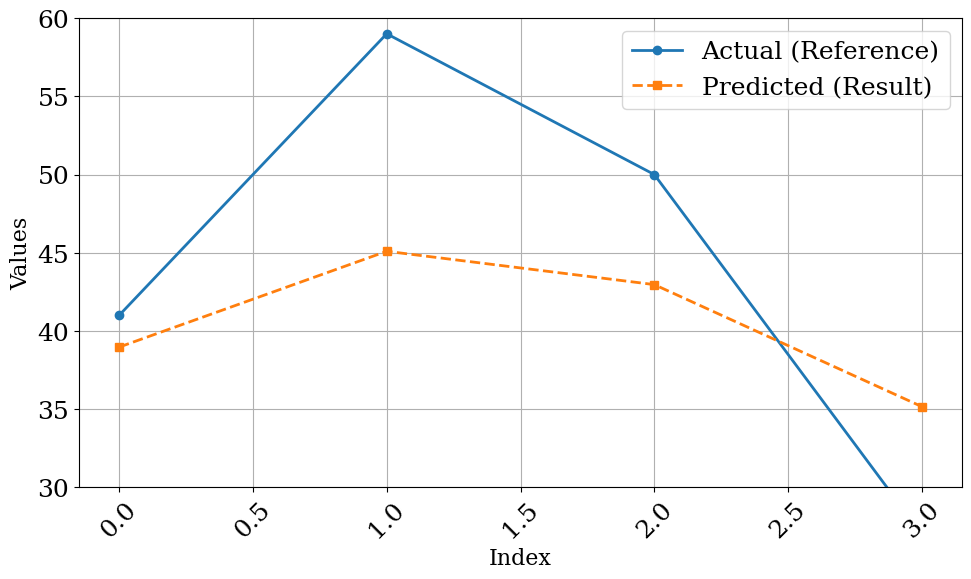

In [218]:
# Convert the DataFrames to NumPy arrays
sarimax_forecast_array = sarima_predictions.to_numpy().flatten()
summed_up_array = summed_up.to_numpy().flatten()

# Ensure both arrays have the same length
min_length = min(len(sarimax_forecast_array), len(summed_up_array))
sarimax_forecast_array = sarimax_forecast_array[:min_length]
summed_up_array = summed_up_array[:min_length]

# Perform element-wise summation
combined_sum_array = sarimax_forecast_array + summed_up_array

# Convert the result back to a DataFrame (optional)
result_df = pd.DataFrame(combined_sum_array, columns=['Combined_Sum'])

# Print the resulting DataFrame
print(result_df)

# Reset the index of the reference DataFrame
reference = reference.reset_index(drop=True)

# Ensure alignment of lengths
min_length = min(len(result_df), len(reference))
predicted = result_df.iloc[:min_length]['Combined_Sum']
test = reference.iloc[:min_length].squeeze()

# Calculate MAE and MAPE
mae = mean_absolute_error(test, predicted)
mape = mean_absolute_percentage_error(test, predicted)

# Print MAE and MAPE
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2%}")

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(test.index, test, label='Actual (Reference)', marker='o', linestyle='-', linewidth=2)
plt.plot(predicted.index, predicted, label='Predicted (Result)', marker='s', linestyle='--', linewidth=2)
 
plt.xlabel('Index')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(30, 60)
plt.show()


In [219]:
end_time=time.time()

In [220]:
Cost=end_time-start_time

In [221]:
main_results = update_results(main_results, 'Hybrid Model', mae, mape, Cost)

In [222]:
main_results

,Model_Name,MAE,MAPE,Cost
0,BASE SARIMA WITHOUT DECOMPOSITION,14.107829,0.293031,33.096646
1,BASE AUTO SARIMA WITHOUT DECOMPOSITION,12.438014,0.290428,66.778659
2,SARIMA by DECOMPOSITION W NO FEATURE,3.883099,0.104131,6.707407
3,AUTO SARIMA BY DECOMPOSITION W NO FEATURE,7.025086,0.172624,39.854797
4,Topological Dataset,0,0,0
5,SARIMA W ALL FEATUREs,19.445691,0.514501,100.935903
6,SARIMA W RFE FEATUREs,6.038522,0.175575,420.725752
7,SARIMA W RFE + PSO FEATUREs,3.772896,0.098696,11.606659
8,SARIMA W RFE + PSO BEST FEATUREs,3.772896,0.098696,5.616401
9,Regression Model W SELECTED FEATURES,8.202009,0.172503,313.378184


# STATISTICAL DATASET

In [223]:
main_results = update_results(main_results, 'Topological Dataset','0' ,'0','0' )

In [224]:
data=datas

# MODEL 2 : SARIMA W ALL FEATURES

In [225]:
start_time=time.time()

In [226]:
train_data = data[:-4]  # Last 4 rows for testing
test_data = data[-4:]

In [227]:
selected_columns_train = train_data.drop(columns=["Target"])
selected_columns_test = test_data.drop(columns=["Target"])

In [228]:
exog_train=selected_columns_train
exog_test=selected_columns_test 

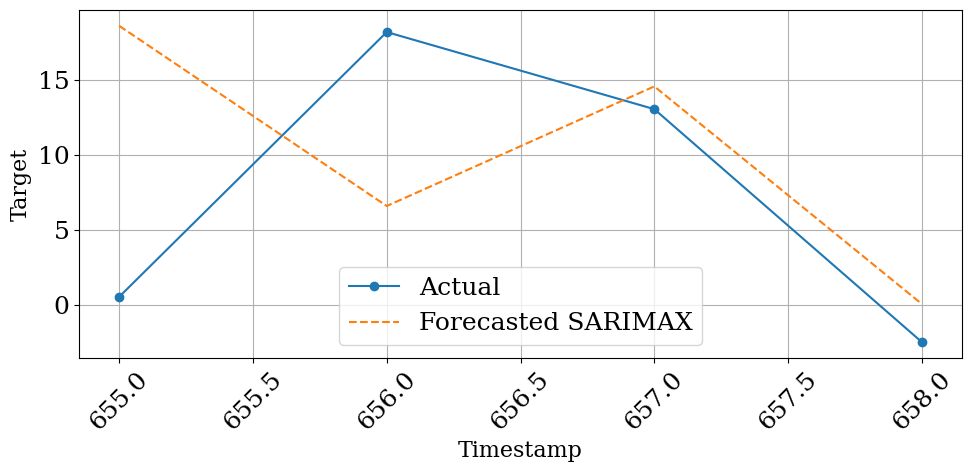

(8.42302447585142, 8.742654878097708)

In [229]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt


# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(1, 0, 0), 
                seasonal_order=(1, 0, 1, 8), 
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
sarima_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics
sarima_mse = mean_absolute_error(test_data['Target'], sarima_predictions)
sarima_mape = mean_absolute_percentage_error(test_data['Target'], sarima_predictions)

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(test_data.index, test_data['Target'], label='Actual', marker='o')
plt.plot(test_data.index, sarima_predictions, label='Forecasted SARIMAX', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Output the MSE and MAPE values
sarima_mse, sarima_mape


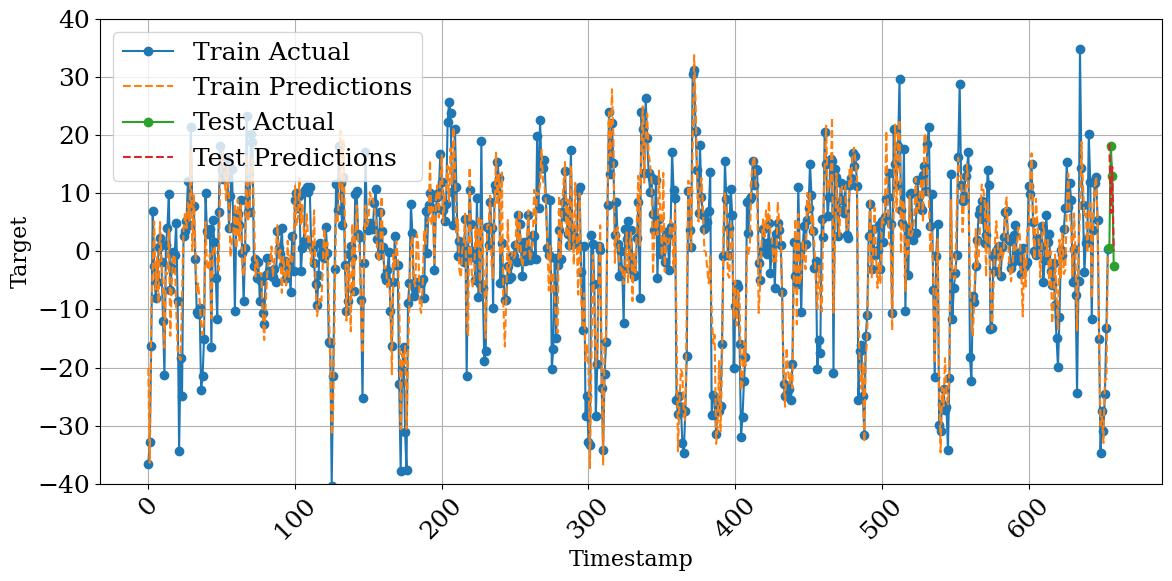

Train MAE: 4.8978
Train MAPE: 3.4458
Test MAE: 8.4230
Test MAPE: 8.7427


In [230]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(1, 0, 0), 
                seasonal_order=(1, 0, 1, 8), 
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# In-sample predictions for the training set
train_predictions = sarimax_results.predict(start=train_data.index[0], 
                                             end=train_data.index[-1], 
                                             exog=exog_train)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
test_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics for the training set
train_mae = mean_absolute_error(train_data['Target'], train_predictions)
train_mape = mean_absolute_percentage_error(train_data['Target'], train_predictions)

# Calculate evaluation metrics for the test set
test_mae = mean_absolute_error(test_data['Target'], test_predictions)
test_mape = mean_absolute_percentage_error(test_data['Target'], test_predictions)

# Plot the results: actual and predictions for both train and test data
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data['Target'], label='Train Actual', marker='o')
plt.plot(train_data.index, train_predictions, label='Train Predictions', linestyle='--')
plt.plot(test_data.index, test_data['Target'], label='Test Actual', marker='o')
plt.plot(test_data.index, test_predictions, label='Test Predictions', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(-40, 40)
plt.show()

# Output the evaluation metrics
print("Train MAE: {:.4f}".format(train_mae))
print("Train MAPE: {:.4f}".format(train_mape))
print("Test MAE: {:.4f}".format(test_mae))
print("Test MAPE: {:.4f}".format(test_mape))


   Combined_Sum
0     58.711936
1     47.413380
2     52.185855
3     30.371320
MAE: 8.71
MAPE: 19.92%


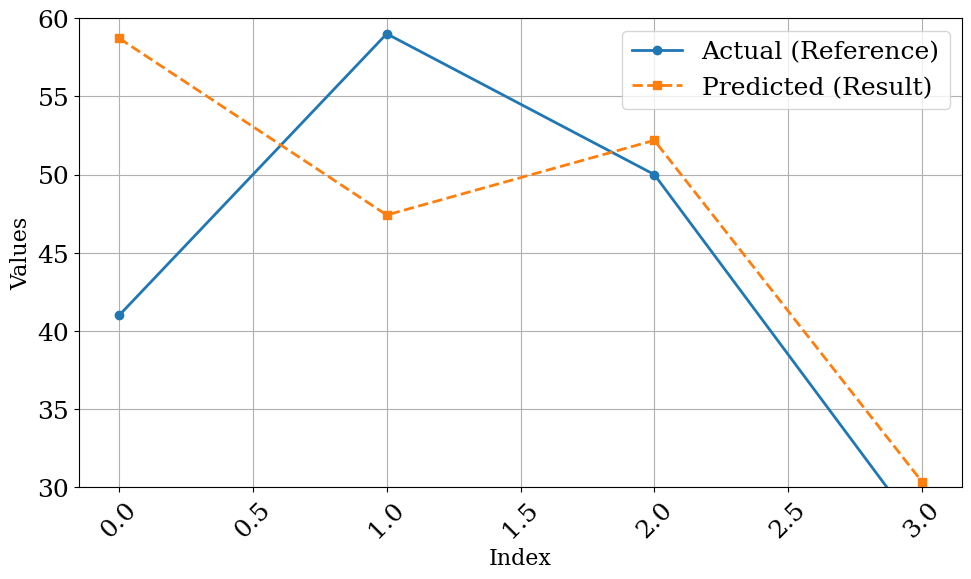

In [231]:
# Convert the DataFrames to NumPy arrays
sarimax_forecast_array = sarima_predictions.to_numpy().flatten()
summed_up_array = summed_up.to_numpy().flatten()

# Ensure both arrays have the same length
min_length = min(len(sarimax_forecast_array), len(summed_up_array))
sarimax_forecast_array = sarimax_forecast_array[:min_length]
summed_up_array = summed_up_array[:min_length]

# Perform element-wise summation
combined_sum_array = sarimax_forecast_array + summed_up_array

# Convert the result back to a DataFrame (optional)
result_df = pd.DataFrame(combined_sum_array, columns=['Combined_Sum'])

# Print the resulting DataFrame
print(result_df)

# Reset the index of the reference DataFrame
reference = reference.reset_index(drop=True)

# Ensure alignment of lengths
min_length = min(len(result_df), len(reference))
predicted = result_df.iloc[:min_length]['Combined_Sum']
test = reference.iloc[:min_length].squeeze()

# Calculate MAE and MAPE
mae = mean_absolute_error(test, predicted)
mape = mean_absolute_percentage_error(test, predicted)

# Print MAE and MAPE
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2%}")

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(test.index, test, label='Actual (Reference)', marker='o', linestyle='-', linewidth=2)
plt.plot(predicted.index, predicted, label='Predicted (Result)', marker='s', linestyle='--', linewidth=2)
 
plt.xlabel('Index')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(30, 60)
plt.show()


In [232]:
end_time=time.time()

In [233]:
Cost = end_time - start_time

In [234]:
main_results = update_results(main_results, 'SARIMA W ALL FEATUREs', mae, mape,Cost)

In [235]:
main_results

,Model_Name,MAE,MAPE,Cost
0,BASE SARIMA WITHOUT DECOMPOSITION,14.107829,0.293031,33.096646
1,BASE AUTO SARIMA WITHOUT DECOMPOSITION,12.438014,0.290428,66.778659
2,SARIMA by DECOMPOSITION W NO FEATURE,3.883099,0.104131,6.707407
3,AUTO SARIMA BY DECOMPOSITION W NO FEATURE,7.025086,0.172624,39.854797
4,Topological Dataset,0,0,0
5,SARIMA W ALL FEATUREs,19.445691,0.514501,100.935903
6,SARIMA W RFE FEATUREs,6.038522,0.175575,420.725752
7,SARIMA W RFE + PSO FEATUREs,3.772896,0.098696,11.606659
8,SARIMA W RFE + PSO BEST FEATUREs,3.772896,0.098696,5.616401
9,Regression Model W SELECTED FEATURES,8.202009,0.172503,313.378184


# MODEL 3-1 : SARIMA W RFE FEATURES

In [236]:
start_time=time.time()

In [237]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.utils import resample
import time
import warnings
import multiprocessing
from joblib import Parallel, delayed

warnings.filterwarnings("ignore")

start_time = time.time()

# Load dataset
df = data  # <-- make sure `data` is defined
target_column = "Target"
exog_columns = [col for col in df.columns if col != target_column]

# Split into training
train_df = df.iloc[:-4]
X_train = train_df[exog_columns]
y_train = train_df[target_column]

# SARIMAX p-value extractor
def get_p_values(X, y):
    try:
        model = SARIMAX(y, 
                        order=(1, 0, 0), 
                        seasonal_order=(1, 0, 1, 8), 
                        exog=X)
        result = model.fit(disp=False)
        return result.pvalues.loc[X.columns]
    except Exception as e:
        print("SARIMAX fit error:", e)
        return pd.Series([1.0] * X.shape[1], index=X.columns)

# Model AIC calculator
def compute_aic(feature_set):
    try:
        model = SARIMAX(y_train, 
                        order=(1, 0, 0), 
                        seasonal_order=(1, 0, 1, 8), 
                        exog=X_train[list(feature_set)])
        result = model.fit(disp=False)
        return (feature_set, result.aic)
    except:
        return (feature_set, np.inf)

# RFE parameters
selected_features = exog_columns.copy()
step2 = 5

# RFE Loop
while True:
    p_values = get_p_values(X_train[selected_features], y_train)

    # Features with p > 0.05
    worst_candidates = p_values[p_values > 0.05]

    # Stopping criterion
    if len(worst_candidates) < step2:
        print(f"Stopping early: Only {len(worst_candidates)} features have p > 0.05.")
        break

    # Dynamic step size
    step = min(20, len(worst_candidates), len(selected_features) // 2)

    # Worst features sorted by p-value
    worst_features = worst_candidates.sort_values(ascending=False).head(step).index

    for feature in worst_features:
        if feature in selected_features:
            selected_features.remove(feature)
            print(f"Removed Feature: {feature}, p-value: {p_values[feature]}")

print("\nInitial RFE Completed.")
print(f"Remaining Features: {len(selected_features)}")

# Optional: Stability Check via Bootstrapping
print("\nRunning stability check (bootstrap p-values)...")
bootstrap_rounds = 10
stable_features = []

boot_results = []
for i in range(bootstrap_rounds):
    X_res, y_res = resample(X_train[selected_features], y_train)
    p_vals = get_p_values(X_res, y_res)
    significant = set(p_vals[p_vals < 0.05].index)
    boot_results.append(significant)

stable_features = list(set.intersection(*boot_results))
print(f"\nStable Features Across {bootstrap_rounds} Bootstraps: {len(stable_features)}")

# Optional: AIC comparison for final selection
print("\nEvaluating AIC on stable subsets...")
feature_sets = [stable_features, selected_features]  # Compare both
num_cores = multiprocessing.cpu_count()

aic_values = Parallel(n_jobs=num_cores)(
    delayed(compute_aic)(f_set) for f_set in feature_sets
)

best_features, best_aic = sorted(aic_values, key=lambda x: x[1])[0]
print(f"\nBest AIC: {best_aic}")
print("Selected Final Features:", best_features)


Removed Feature: Operation__cid_ce__normalize_False, p-value: 0.9977202889976138
Removed Feature: Operation__partial_autocorrelation__lag_8, p-value: 0.9971706893855683
Removed Feature: Operation__fft_coefficient__attr_"real"__coeff_4, p-value: 0.9926345465888902
Removed Feature: Operation__spkt_welch_density__coeff_2, p-value: 0.9845434184220385
Removed Feature: Operation__ar_coefficient__coeff_3__k_10, p-value: 0.9817460146857829
Removed Feature: Operation__cwt_coefficients__coeff_9__w_2__widths_(2, 5, 10, 20), p-value: 0.9812325618326134
Removed Feature: Operation__ar_coefficient__coeff_2__k_10, p-value: 0.979898628446309
Removed Feature: Operation__fft_coefficient__attr_"angle"__coeff_3, p-value: 0.9751558089948413
Removed Feature: Operation__max_langevin_fixed_point__m_3__r_30, p-value: 0.9749890400450221
Removed Feature: Operation__cwt_coefficients__coeff_8__w_2__widths_(2, 5, 10, 20), p-value: 0.9717387058770279
Removed Feature: Operation__ar_coefficient__coeff_4__k_10, p-value:

Removed Feature: Operation__agg_linear_trend__attr_"rvalue"__chunk_len_10__f_agg_"var", p-value: 0.910808870335244
Removed Feature: Operation__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.0, p-value: 0.8371613306864987
Removed Feature: Operation__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.4, p-value: 0.8205993773039967
Removed Feature: Operation__autocorrelation__lag_3, p-value: 0.8174798168418631
Removed Feature: Operation__change_quantiles__f_agg_"mean"__isabs_True__qh_0.6__ql_0.4, p-value: 0.8085555083363665
Removed Feature: Operation__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0, p-value: 0.808180511339291
Removed Feature: Operation__change_quantiles__f_agg_"mean"__isabs_False__qh_0.6__ql_0.2, p-value: 0.7999474256853768
Removed Feature: Operation__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.6, p-value: 0.7596072857011594
Removed Feature: Operation__fft_coefficient__attr_"real"__coeff_11, p-value: 0.7364010585671137
Removed Feature:

Removed Feature: Operation__augmented_dickey_fuller__attr_"usedlag"__autolag_"AIC", p-value: 0.3151700400298564
Removed Feature: Operation__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.8, p-value: 0.21899975839263064
Removed Feature: Operation__median, p-value: 0.20319143773485537
Removed Feature: Operation__energy_ratio_by_chunks__num_segments_10__segment_focus_2, p-value: 0.15540793437033612
Removed Feature: Operation__fft_coefficient__attr_"imag"__coeff_6, p-value: 0.13807247497312405
Removed Feature: Operation__c3__lag_3, p-value: 0.11160676307289374
Removed Feature: Operation__fft_coefficient__attr_"abs"__coeff_10, p-value: 0.10004018507644025
Removed Feature: Operation__fft_aggregated__aggtype_"centroid", p-value: 0.07279071910015951
Removed Feature: Operation__time_reversal_asymmetry_statistic__lag_1, p-value: 0.06413086631470784
Removed Feature: Operation__index_mass_quantile__q_0.6, p-value: 0.057535742051089
Removed Feature: Operation__change_quantiles__f_agg_"var"

In [238]:
columns_to_keep = selected_features.copy()  # Make a copy of your list
if 'Target' not in columns_to_keep:
    columns_to_keep.append('Target')

data_rfe = data[columns_to_keep]

In [239]:
data_rfe

,Operation__mean_change,Operation__variance,Operation__kurtosis,Operation__first_location_of_minimum,Operation__minimum,Operation__c3__lag_2,Operation__cid_ce__normalize_True,Operation__large_standard_deviation__r_0.30000000000000004,Operation__autocorrelation__lag_2,Operation__autocorrelation__lag_4,...,"Operation__agg_linear_trend__attr_""slope""__chunk_len_5__f_agg_""var""","Operation__agg_linear_trend__attr_""slope""__chunk_len_10__f_agg_""max""","Operation__agg_linear_trend__attr_""stderr""__chunk_len_5__f_agg_""max""","Operation__agg_linear_trend__attr_""stderr""__chunk_len_10__f_agg_""mean""","Operation__augmented_dickey_fuller__attr_""teststat""__autolag_""AIC""",Operation__energy_ratio_by_chunks__num_segments_10__segment_focus_0,Operation__energy_ratio_by_chunks__num_segments_10__segment_focus_1,Operation__energy_ratio_by_chunks__num_segments_10__segment_focus_9,Operation__fourier_entropy__bins_5,Target
0,0.435641,0.115800,0.241996,0.608696,0.736691,0.713178,0.478533,0,0.732304,0.667920,...,0.488034,0.506061,0.135317,0.228163,0.532393,0.501017,0.212610,0.018029,0.504556,-36.630516
1,0.000000,0.276186,0.814625,1.000000,0.101781,0.703359,0.509238,0,0.516078,0.578727,...,0.808668,0.506061,0.190517,0.102840,0.588588,0.264193,0.142531,0.640073,0.504556,-32.755274
2,0.106475,0.361447,0.563293,0.956522,0.101781,0.683828,0.383007,0,0.438189,0.446990,...,0.848609,0.573029,0.119451,0.141673,0.614267,0.108308,0.122982,0.924360,0.576236,-16.242944
3,0.288723,0.372947,0.447570,0.913043,0.101781,0.684502,0.408672,0,0.561794,0.411802,...,0.748741,0.576647,0.111513,0.224648,0.565750,0.098007,0.106838,0.493819,0.576236,6.891582
4,0.465402,0.372415,0.448262,0.869565,0.101781,0.669784,0.483940,0,0.473252,0.395034,...,0.791988,0.604535,0.124114,0.241058,0.581954,0.110997,0.076961,0.115074,0.576236,-2.448256
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
654,0.425908,0.697103,0.149290,0.826087,0.153139,0.460751,0.389104,0,0.520188,0.477816,...,0.542073,0.124951,0.744567,0.361837,0.566523,0.016110,0.358909,0.152297,0.504556,0.412770
655,0.494867,0.697851,0.148954,0.782609,0.153139,0.464605,0.401063,0,0.507496,0.459679,...,0.392050,0.273481,0.227867,0.155343,0.561089,0.126527,0.283699,0.034025,0.504556,0.543904
656,0.565500,0.697949,0.148874,0.739130,0.153139,0.469137,0.395877,0,0.512554,0.423437,...,0.236790,0.274920,0.087314,0.146578,0.520804,0.131576,0.291301,0.000000,0.576236,18.180364
657,0.868459,0.739417,0.127158,0.695652,0.153139,0.463273,0.373611,0,0.507480,0.369644,...,0.183635,0.468551,0.652691,0.447607,0.814676,0.343776,0.053010,0.063021,0.687523,13.045591


In [240]:
train_data = data_rfe[:-4]  # Last 4 rows for testing
test_data = data_rfe[-4:]

In [241]:
selected_columns_train = train_data.drop(columns=["Target"])
selected_columns_test = test_data.drop(columns=["Target"])

In [242]:
exog_train=selected_columns_train
exog_test=selected_columns_test 

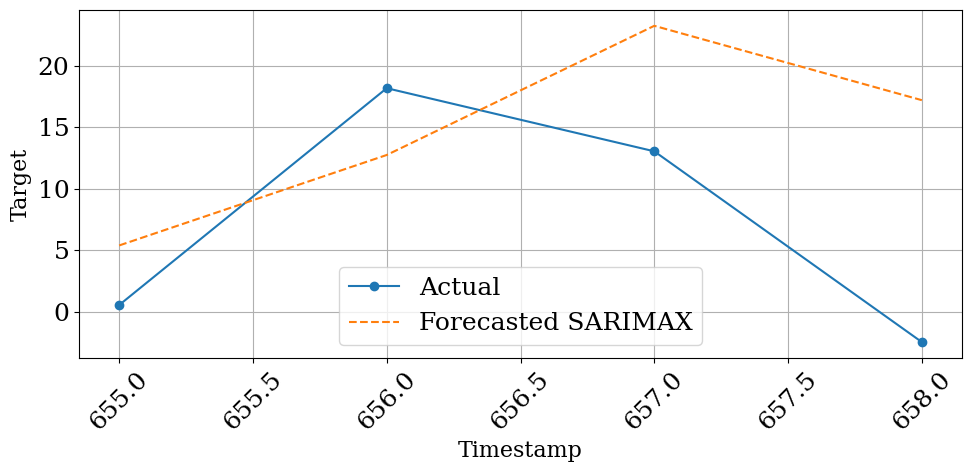

(10.04006973420003, 4.488672800245222)

In [243]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt


# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(1, 0, 0), 
                seasonal_order=(1, 0, 1, 8), 
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
sarima_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics
sarima_mse = mean_absolute_error(test_data['Target'], sarima_predictions)
sarima_mape = mean_absolute_percentage_error(test_data['Target'], sarima_predictions)

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(test_data.index, test_data['Target'], label='Actual', marker='o')
plt.plot(test_data.index, sarima_predictions, label='Forecasted SARIMAX', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Output the MSE and MAPE values
sarima_mse, sarima_mape


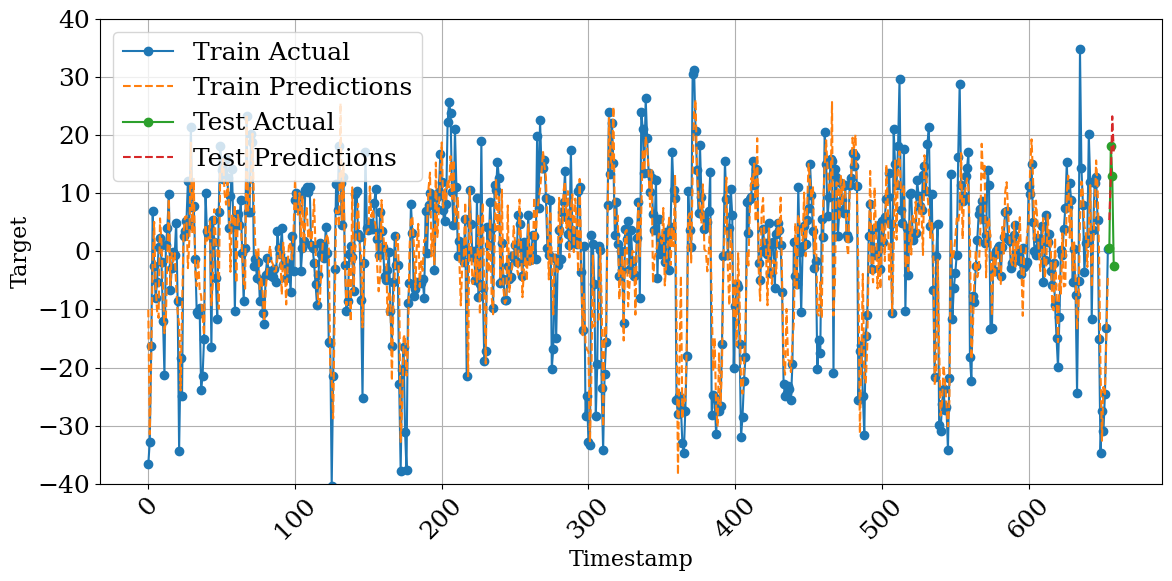

Train MAE: 5.6534
Train MAPE: 4.3609
Test MAE: 10.0401
Test MAPE: 4.4887


In [244]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(1, 0, 0), 
                seasonal_order=(1, 0, 1, 8), 
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# In-sample predictions for the training set
train_predictions = sarimax_results.predict(start=train_data.index[0], 
                                             end=train_data.index[-1], 
                                             exog=exog_train)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
test_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics for the training set
train_mae = mean_absolute_error(train_data['Target'], train_predictions)
train_mape = mean_absolute_percentage_error(train_data['Target'], train_predictions)

# Calculate evaluation metrics for the test set
test_mae = mean_absolute_error(test_data['Target'], test_predictions)
test_mape = mean_absolute_percentage_error(test_data['Target'], test_predictions)

# Plot the results: actual and predictions for both train and test data
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data['Target'], label='Train Actual', marker='o')
plt.plot(train_data.index, train_predictions, label='Train Predictions', linestyle='--')
plt.plot(test_data.index, test_data['Target'], label='Test Actual', marker='o')
plt.plot(test_data.index, test_predictions, label='Test Predictions', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(-40, 40)
plt.show()

# Output the evaluation metrics
print("Train MAE: {:.4f}".format(train_mae))
print("Train MAPE: {:.4f}".format(train_mape))
print("Test MAE: {:.4f}".format(test_mae))
print("Test MAPE: {:.4f}".format(test_mape))


   Combined_Sum
0     45.505186
1     53.567191
2     60.877797
3     47.508120
MAE: 10.33
MAPE: 29.48%


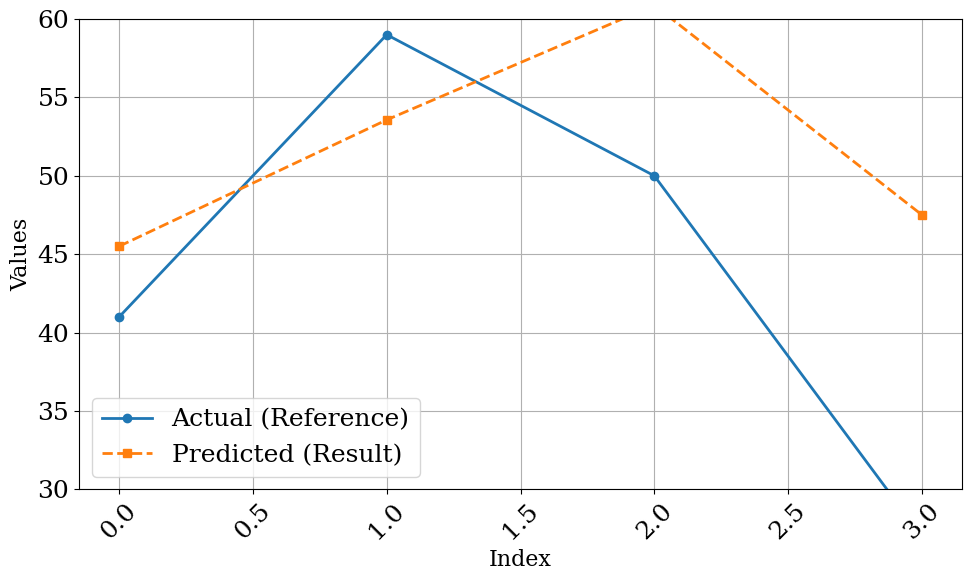

In [245]:
# Convert the DataFrames to NumPy arrays
sarimax_forecast_array = sarima_predictions.to_numpy().flatten()
summed_up_array = summed_up.to_numpy().flatten()

# Ensure both arrays have the same length
min_length = min(len(sarimax_forecast_array), len(summed_up_array))
sarimax_forecast_array = sarimax_forecast_array[:min_length]
summed_up_array = summed_up_array[:min_length]

# Perform element-wise summation
combined_sum_array = sarimax_forecast_array + summed_up_array

# Convert the result back to a DataFrame (optional)
result_df = pd.DataFrame(combined_sum_array, columns=['Combined_Sum'])

# Print the resulting DataFrame
print(result_df)

# Reset the index of the reference DataFrame
reference = reference.reset_index(drop=True)

# Ensure alignment of lengths
min_length = min(len(result_df), len(reference))
predicted = result_df.iloc[:min_length]['Combined_Sum']
test = reference.iloc[:min_length].squeeze()

# Calculate MAE and MAPE
mae = mean_absolute_error(test, predicted)
mape = mean_absolute_percentage_error(test, predicted)

# Print MAE and MAPE
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2%}")

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(test.index, test, label='Actual (Reference)', marker='o', linestyle='-', linewidth=2)
plt.plot(predicted.index, predicted, label='Predicted (Result)', marker='s', linestyle='--', linewidth=2)
 
plt.xlabel('Index')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(30, 60)
plt.show()


In [246]:
end_time=time.time()

In [247]:
Cost = end_time - start_time

In [248]:
main_results = update_results(main_results, 'SARIMA W RFE FEATUREs', mae, mape,Cost)

In [249]:
main_results

,Model_Name,MAE,MAPE,Cost
0,BASE SARIMA WITHOUT DECOMPOSITION,14.107829,0.293031,33.096646
1,BASE AUTO SARIMA WITHOUT DECOMPOSITION,12.438014,0.290428,66.778659
2,SARIMA by DECOMPOSITION W NO FEATURE,3.883099,0.104131,6.707407
3,AUTO SARIMA BY DECOMPOSITION W NO FEATURE,7.025086,0.172624,39.854797
4,Topological Dataset,0,0,0
5,SARIMA W ALL FEATUREs,19.445691,0.514501,100.935903
6,SARIMA W RFE FEATUREs,6.038522,0.175575,420.725752
7,SARIMA W RFE + PSO FEATUREs,3.772896,0.098696,11.606659
8,SARIMA W RFE + PSO BEST FEATUREs,3.772896,0.098696,5.616401
9,Regression Model W SELECTED FEATURES,8.202009,0.172503,313.378184


# MODEL 4 : SARIMA W RFE + PSO FEATURES

In [250]:
import numpy as np 
import pandas as pd
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pyswarm import pso  # Particle Swarm Optimization
from functools import lru_cache
from collections import Counter
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
start_time=time.time()
# Suppress warnings
warnings.filterwarnings("ignore")

# ============================
# Data Preparation
# ============================

target_column = 'Target'  # Replace with actual target column
train_data = data_rfe[:-4]  # Use all but the last 4 rows for training

selected_columns_train = train_data.drop(columns=[target_column])  # Features only
exog_train = selected_columns_train.values

num_features = selected_columns_train.shape[1]  # Number of features

# ============================
# Caching for Faster Execution
# ============================

solution_cache = {}

@lru_cache(maxsize=1000)
def evaluate_solution(solution_key):
    """
    Evaluates SARIMAX performance for a given feature subset using negative BIC.
    """
    selected_features = np.array(solution_key, dtype=bool)
    
    # Penalize solutions that select no features
    if not np.any(selected_features):
        return 1e6  

    exog_selected = exog_train[:, selected_features]

    try:
        model = SARIMAX(train_data[target_column],
                        order=(1, 0, 0),
                        seasonal_order=(1, 0, 1, 8),
                        exog=exog_selected,
                        enforce_stationarity=False,
                        enforce_invertibility=False)
        results = model.fit(disp=0, maxiter=30)  # Lower maxiter for speed
        return results.bic  # Minimize BIC
    except:
        return 1e6  # Strong penalty for errors

# ============================
# Define PSO Objective Function
# ============================

def pso_objective_function(solution):
    """
    Evaluates the fitness of a feature subset for PSO.
    """
    key = tuple(np.round(solution).astype(int))  # Convert to binary feature selection
    
    if key in solution_cache:
        return solution_cache[key]

    # Evaluate solution
    fitness_val = evaluate_solution(key)
    solution_cache[key] = fitness_val  # Store in cache
    return fitness_val

# ============================
# PSO Execution
# ============================

lb = [0] * num_features  # Lower bounds (0 = feature not selected)
ub = [1] * num_features  # Upper bounds (1 = feature selected)

selected_features_runs = []
best_results = []
num_columns = data_rfe.shape[1]-1
for run in range(5):
    print(f"Starting PSO optimization, run {run+1}...")

    best_solution, best_bic = best_solution, best_bic = pso(
    pso_objective_function, 
    lb, 
    ub, 
    swarmsize=40, 
    maxiter=100, 
    omega=0.7,  # Inertia weight
    phip=1.4,   # Cognitive parameter (similar to c1)
    phig=1.8,   # Social parameter (similar to c2)
    debug=False
)


    # Convert solution to selected feature names
    selected_features_mask = np.round(best_solution).astype(int).astype(bool)
    selected_features_pso = selected_columns_train.columns[selected_features_mask].tolist()
    selected_features_runs.append(selected_features_pso)

    # Fit final model with selected features
    exog_train_final = exog_train[:, selected_features_mask]


    final_model = SARIMAX(train_data[target_column],
                          order=(1, 0, 0),
                          seasonal_order=(1, 0, 1, 8),
                          exog=exog_train_final)
    final_results = final_model.fit(disp=False)
    


    # Save best results
    best_results.append({
        "Run": run + 1,
        "BIC": best_bic,
        "Selected Features": selected_features_pso
    })

# Convert to DataFrame
results_df = pd.DataFrame(best_results)

# Identify the best run (minimum BIC)
best_run = results_df.loc[results_df[['BIC']].sum(axis=1).idxmin()]
best_run_features = best_run["Selected Features"]

# Find the most frequently chosen features (chosen in at least 3 runs)
feature_counts = Counter(feature for run_features in selected_features_runs for feature in run_features)
final_feature_selection = list(feature_counts.keys())

# If final_feature_selection is empty, assign it to best_run_features
if not final_feature_selection:
    final_feature_selection = best_run_features

# Save best run features and final feature selection in separate lists
best_run_feature_list = list(best_run_features)
final_feature_selection_list = list(final_feature_selection)

# ============================
# Display Results
# ============================

print("\nPSO Runs Results:")
print(results_df)

print("\nBest Run Summary:")
print(best_run)

print("\nFinal Feature Selection (Chosen in at least 3 runs or from best run if empty):")
print(final_feature_selection_list)

print("\nBest Run Features List:")
print(best_run_feature_list)

# ============================
# Save Results
# ============================

# Convert to DataFrame for easy export if needed
best_run_summary_df = pd.DataFrame([best_run])
final_features_df = pd.DataFrame({"Most Chosen Features": final_feature_selection_list})


Starting PSO optimization, run 1...
Stopping search: maximum iterations reached --> 100
Starting PSO optimization, run 2...
Stopping search: maximum iterations reached --> 100
Starting PSO optimization, run 3...
Stopping search: maximum iterations reached --> 100
Starting PSO optimization, run 4...
Stopping search: maximum iterations reached --> 100
Starting PSO optimization, run 5...
Stopping search: maximum iterations reached --> 100

PSO Runs Results:
   Run          BIC                                  Selected Features
0    1  4592.198655  [Operation__c3__lag_2, Operation__cid_ce__norm...
1    2  4575.654776  [Operation__mean_change, Operation__minimum, O...
2    3  4584.304983  [Operation__mean_change, Operation__cid_ce__no...
3    4  4594.388747  [Operation__mean_change, Operation__kurtosis, ...
4    5  4622.155074  [Operation__kurtosis, Operation__large_standar...

Best Run Summary:
Run                                                                  2
BIC                      

In [251]:
# Save best run features and final feature selection in separate lists
best_run_feature_list = list(best_run_features)
final_feature_selection_list = list(final_feature_selection)

In [252]:
# Convert selected_features_pso to a standard Python list
selected_features_pso = best_run_feature_list

# Add 'Target' to the selected features list
selected_features_pso.append('Target')

In [253]:
data_pso=data_rfe[selected_features_pso]

In [254]:
# Convert selected_features_pso to a standard Python list
selected_features_pso = final_feature_selection_list

# Add 'Target' to the selected features list
selected_features_pso.append('Target')

In [255]:
data_pso_best=data_rfe[selected_features_pso]

In [256]:
train_data = data_pso[:-4]  # Last 4 rows for testing
test_data = data_pso[-4:]

In [257]:
selected_columns_train = train_data.drop(columns=["Target"])
selected_columns_test = test_data.drop(columns=["Target"])

In [258]:
exog_train=selected_columns_train
exog_test=selected_columns_test 

In [259]:
start_time=time.time()

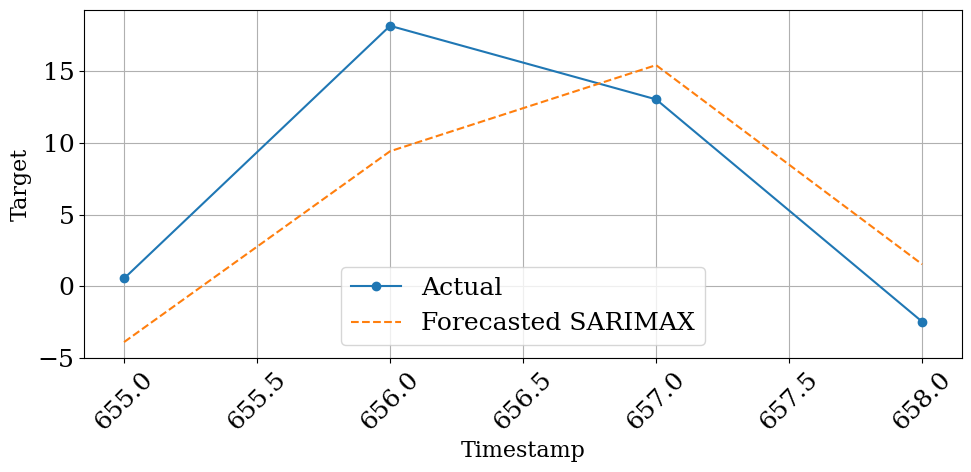

(4.89844276409749, 2.612716974543888)

In [260]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt


# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(1, 0, 0), 
                seasonal_order=(1, 0, 1, 8), 
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
sarima_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics
sarima_mse = mean_absolute_error(test_data['Target'], sarima_predictions)
sarima_mape = mean_absolute_percentage_error(test_data['Target'], sarima_predictions)

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(test_data.index, test_data['Target'], label='Actual', marker='o')
plt.plot(test_data.index, sarima_predictions, label='Forecasted SARIMAX', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Output the MSE and MAPE values
sarima_mse, sarima_mape


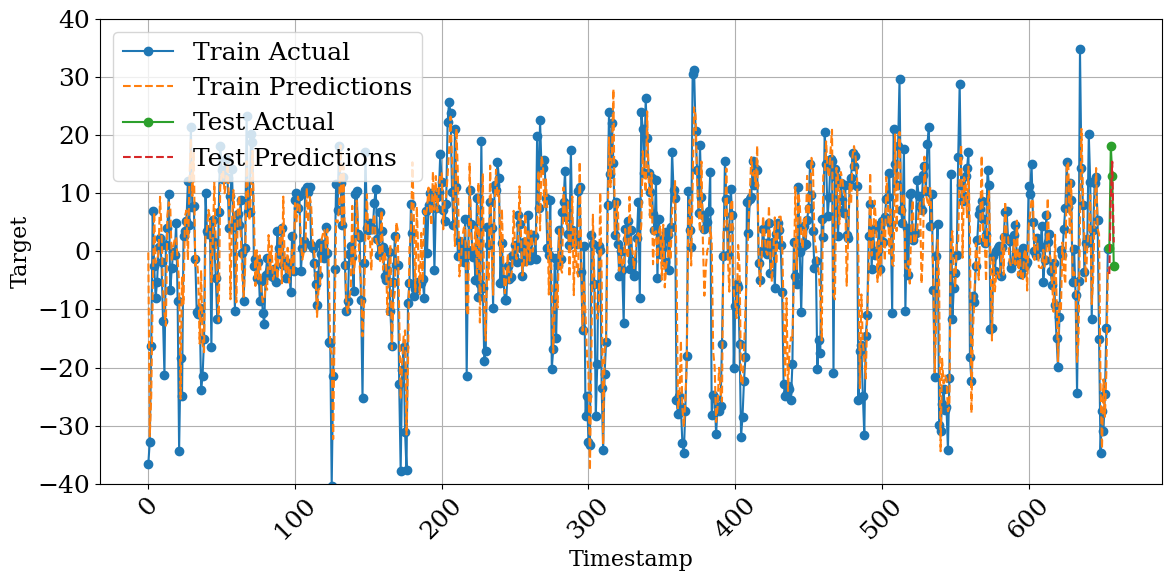

Train MAE: 5.8326
Train MAPE: 3.5545
Test MAE: 4.8984
Test MAPE: 2.6127


In [261]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(1, 0, 0), 
                seasonal_order=(1, 0, 1, 8), 
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# In-sample predictions for the training set
train_predictions = sarimax_results.predict(start=train_data.index[0], 
                                             end=train_data.index[-1], 
                                             exog=exog_train)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
test_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics for the training set
train_mae = mean_absolute_error(train_data['Target'], train_predictions)
train_mape = mean_absolute_percentage_error(train_data['Target'], train_predictions)

# Calculate evaluation metrics for the test set
test_mae = mean_absolute_error(test_data['Target'], test_predictions)
test_mape = mean_absolute_percentage_error(test_data['Target'], test_predictions)

# Plot the results: actual and predictions for both train and test data
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data['Target'], label='Train Actual', marker='o')
plt.plot(train_data.index, train_predictions, label='Train Predictions', linestyle='--')
plt.plot(test_data.index, test_data['Target'], label='Test Actual', marker='o')
plt.plot(test_data.index, test_predictions, label='Test Predictions', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(-40, 40)
plt.show()

# Output the evaluation metrics
print("Train MAE: {:.4f}".format(train_mae))
print("Train MAPE: {:.4f}".format(train_mape))
print("Test MAE: {:.4f}".format(test_mae))
print("Test MAPE: {:.4f}".format(test_mape))


   Combined_Sum
0     36.219563
1     50.243728
2     53.060292
3     31.840598
MAE: 5.36
MAPE: 12.64%


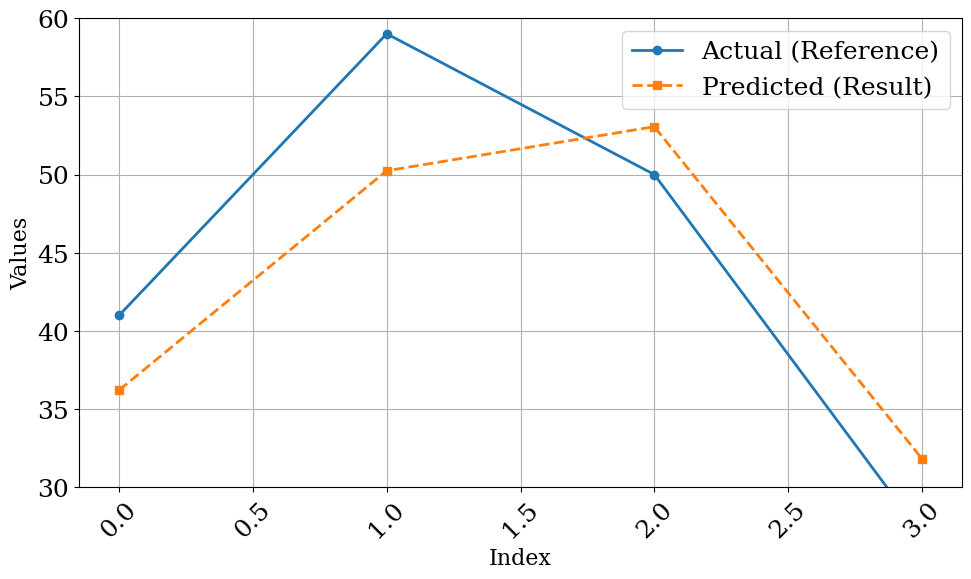

In [262]:
# Convert the DataFrames to NumPy arrays
sarimax_forecast_array = sarima_predictions.to_numpy().flatten()
summed_up_array = summed_up.to_numpy().flatten()

# Ensure both arrays have the same length
min_length = min(len(sarimax_forecast_array), len(summed_up_array))
sarimax_forecast_array = sarimax_forecast_array[:min_length]
summed_up_array = summed_up_array[:min_length]

# Perform element-wise summation
combined_sum_array = sarimax_forecast_array + summed_up_array

# Convert the result back to a DataFrame (optional)
result_df = pd.DataFrame(combined_sum_array, columns=['Combined_Sum'])

# Print the resulting DataFrame
print(result_df)

# Reset the index of the reference DataFrame
reference = reference.reset_index(drop=True)

# Ensure alignment of lengths
min_length = min(len(result_df), len(reference))
predicted = result_df.iloc[:min_length]['Combined_Sum']
test = reference.iloc[:min_length].squeeze()

# Calculate MAE and MAPE
mae = mean_absolute_error(test, predicted)
mape = mean_absolute_percentage_error(test, predicted)

# Print MAE and MAPE
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2%}")

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(test.index, test, label='Actual (Reference)', marker='o', linestyle='-', linewidth=2)
plt.plot(predicted.index, predicted, label='Predicted (Result)', marker='s', linestyle='--', linewidth=2)
 
plt.xlabel('Index')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(30, 60)
plt.show()


In [263]:
end_time=time.time()

In [264]:
Cost = end_time - start_time

In [265]:
main_results = update_results(main_results, 'SARIMA W RFE + PSO FEATUREs', mae, mape,Cost)

In [266]:
main_results

,Model_Name,MAE,MAPE,Cost
0,BASE SARIMA WITHOUT DECOMPOSITION,14.107829,0.293031,33.096646
1,BASE AUTO SARIMA WITHOUT DECOMPOSITION,12.438014,0.290428,66.778659
2,SARIMA by DECOMPOSITION W NO FEATURE,3.883099,0.104131,6.707407
3,AUTO SARIMA BY DECOMPOSITION W NO FEATURE,7.025086,0.172624,39.854797
4,Topological Dataset,0,0,0
5,SARIMA W ALL FEATUREs,19.445691,0.514501,100.935903
6,SARIMA W RFE FEATUREs,6.038522,0.175575,420.725752
7,SARIMA W RFE + PSO FEATUREs,3.772896,0.098696,11.606659
8,SARIMA W RFE + PSO BEST FEATUREs,3.772896,0.098696,5.616401
9,Regression Model W SELECTED FEATURES,8.202009,0.172503,313.378184


# MODEL 4 - 1: SARIMA W RFE+PSO BEST FEATURE SELECTION

In [267]:
start_time=time.time()

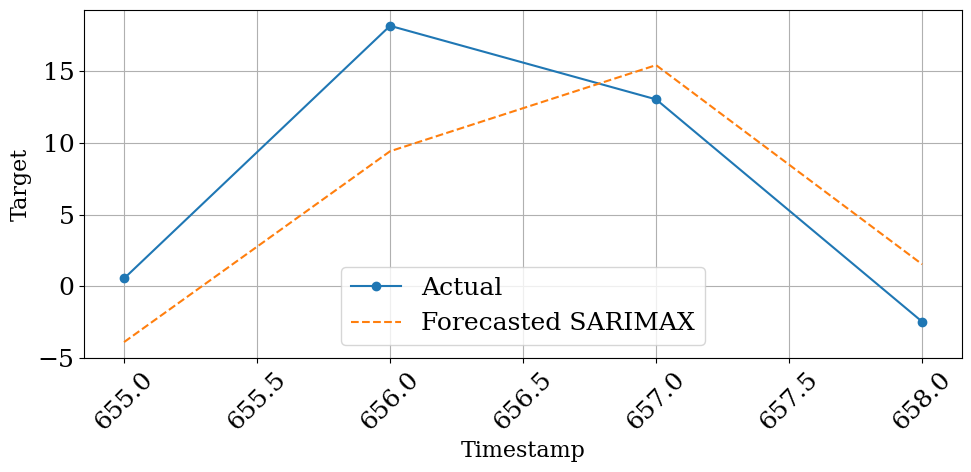

(4.89844276409749, 2.612716974543888)

In [268]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt


# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(1, 0, 0), 
                seasonal_order=(1, 0, 1, 8), 
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
sarima_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics
sarima_mse = mean_absolute_error(test_data['Target'], sarima_predictions)
sarima_mape = mean_absolute_percentage_error(test_data['Target'], sarima_predictions)

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(test_data.index, test_data['Target'], label='Actual', marker='o')
plt.plot(test_data.index, sarima_predictions, label='Forecasted SARIMAX', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Output the MSE and MAPE values
sarima_mse, sarima_mape


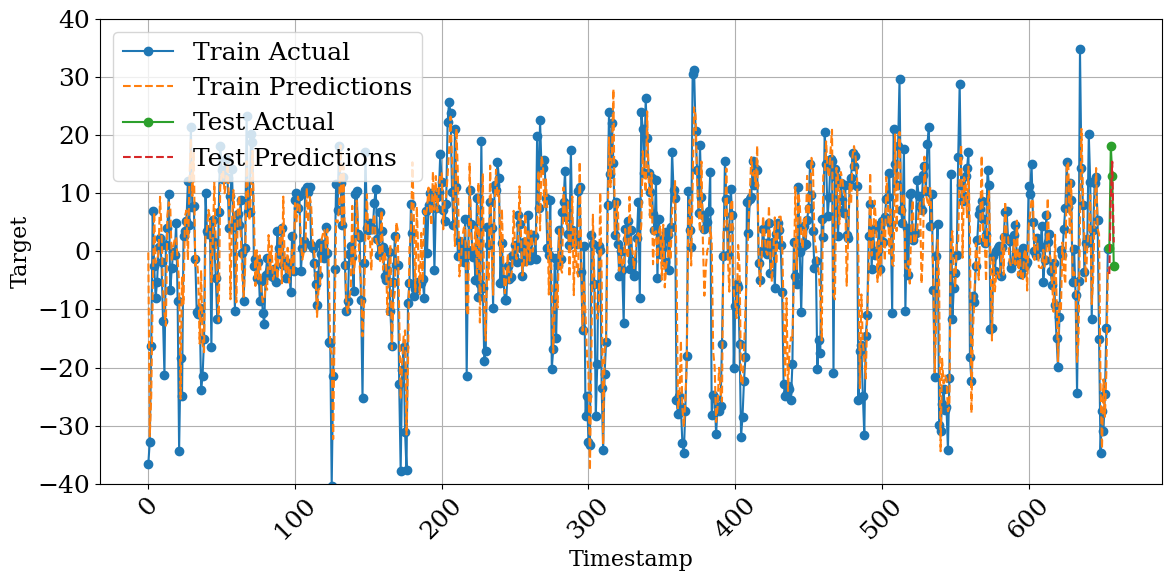

Train MAE: 5.8326
Train MAPE: 3.5545
Test MAE: 4.8984
Test MAPE: 2.6127


In [269]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(1, 0, 0), 
                seasonal_order=(1, 0, 1, 8), 
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# In-sample predictions for the training set
train_predictions = sarimax_results.predict(start=train_data.index[0], 
                                             end=train_data.index[-1], 
                                             exog=exog_train)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
test_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics for the training set
train_mae = mean_absolute_error(train_data['Target'], train_predictions)
train_mape = mean_absolute_percentage_error(train_data['Target'], train_predictions)

# Calculate evaluation metrics for the test set
test_mae = mean_absolute_error(test_data['Target'], test_predictions)
test_mape = mean_absolute_percentage_error(test_data['Target'], test_predictions)

# Plot the results: actual and predictions for both train and test data
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data['Target'], label='Train Actual', marker='o')
plt.plot(train_data.index, train_predictions, label='Train Predictions', linestyle='--')
plt.plot(test_data.index, test_data['Target'], label='Test Actual', marker='o')
plt.plot(test_data.index, test_predictions, label='Test Predictions', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(-40, 40)
plt.show()

# Output the evaluation metrics
print("Train MAE: {:.4f}".format(train_mae))
print("Train MAPE: {:.4f}".format(train_mape))
print("Test MAE: {:.4f}".format(test_mae))
print("Test MAPE: {:.4f}".format(test_mape))


   Combined_Sum
0     36.219563
1     50.243728
2     53.060292
3     31.840598
MAE: 5.36
MAPE: 12.64%


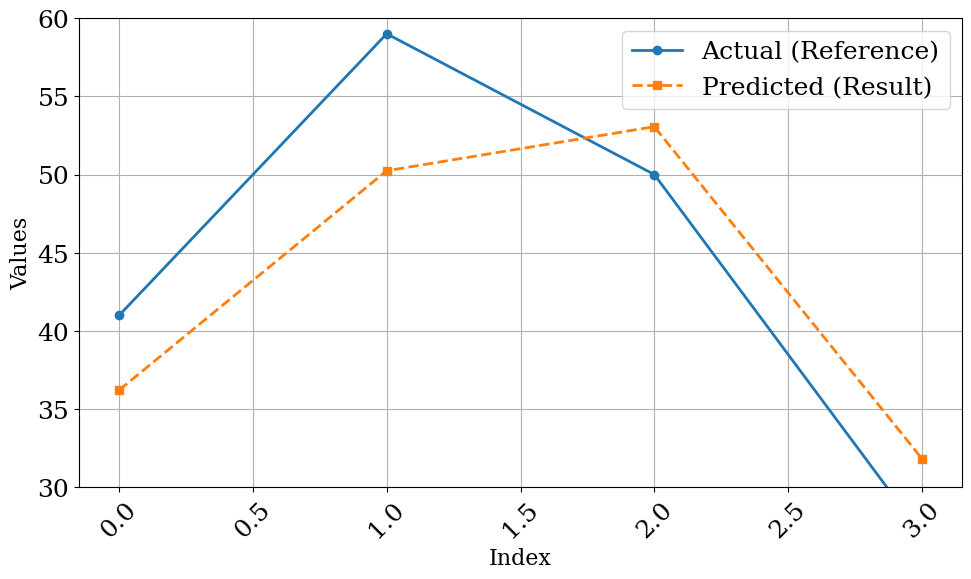

In [270]:
# Convert the DataFrames to NumPy arrays
sarimax_forecast_array = sarima_predictions.to_numpy().flatten()
summed_up_array = summed_up.to_numpy().flatten()

# Ensure both arrays have the same length
min_length = min(len(sarimax_forecast_array), len(summed_up_array))
sarimax_forecast_array = sarimax_forecast_array[:min_length]
summed_up_array = summed_up_array[:min_length]

# Perform element-wise summation
combined_sum_array = sarimax_forecast_array + summed_up_array

# Convert the result back to a DataFrame (optional)
result_df = pd.DataFrame(combined_sum_array, columns=['Combined_Sum'])

# Print the resulting DataFrame
print(result_df)

# Reset the index of the reference DataFrame
reference = reference.reset_index(drop=True)

# Ensure alignment of lengths
min_length = min(len(result_df), len(reference))
predicted = result_df.iloc[:min_length]['Combined_Sum']
test = reference.iloc[:min_length].squeeze()

# Calculate MAE and MAPE
mae = mean_absolute_error(test, predicted)
mape = mean_absolute_percentage_error(test, predicted)

# Print MAE and MAPE
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2%}")

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(test.index, test, label='Actual (Reference)', marker='o', linestyle='-', linewidth=2)
plt.plot(predicted.index, predicted, label='Predicted (Result)', marker='s', linestyle='--', linewidth=2)
 
plt.xlabel('Index')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(30, 60)
plt.show()


In [271]:
end_time=time.time()

In [272]:
Cost = end_time - start_time

In [273]:
main_results = update_results(main_results, 'SARIMA W RFE + PSO BEST FEATUREs', mae, mape,Cost)

In [274]:
main_results

,Model_Name,MAE,MAPE,Cost
0,BASE SARIMA WITHOUT DECOMPOSITION,14.107829,0.293031,33.096646
1,BASE AUTO SARIMA WITHOUT DECOMPOSITION,12.438014,0.290428,66.778659
2,SARIMA by DECOMPOSITION W NO FEATURE,3.883099,0.104131,6.707407
3,AUTO SARIMA BY DECOMPOSITION W NO FEATURE,7.025086,0.172624,39.854797
4,Topological Dataset,0,0,0
5,SARIMA W ALL FEATUREs,19.445691,0.514501,100.935903
6,SARIMA W RFE FEATUREs,6.038522,0.175575,420.725752
7,SARIMA W RFE + PSO FEATUREs,3.772896,0.098696,11.606659
8,SARIMA W RFE + PSO BEST FEATUREs,3.772896,0.098696,5.616401
9,Regression Model W SELECTED FEATURES,8.202009,0.172503,313.378184


# MODEL 5-1 : FEATURE SELECTION REGRESSION ANALYSIS

In [275]:
data

,Operation__mean_change,Operation__mean_second_derivative_central,Operation__median,Operation__variation_coefficient,Operation__variance,Operation__skewness,Operation__kurtosis,Operation__longest_strike_below_mean,Operation__longest_strike_above_mean,Operation__count_below_mean,...,Operation__energy_ratio_by_chunks__num_segments_10__segment_focus_8,Operation__energy_ratio_by_chunks__num_segments_10__segment_focus_9,Operation__ratio_beyond_r_sigma__r_0.5,Operation__fourier_entropy__bins_2,Operation__fourier_entropy__bins_3,Operation__fourier_entropy__bins_5,Operation__fourier_entropy__bins_10,Operation__fourier_entropy__bins_100,Operation__permutation_entropy__dimension_4__tau_1,Target
0,0.435641,0.403709,0.766209,0.303235,0.115800,0.390664,0.241996,0.428571,0.428571,0.454545,...,0.038271,0.018029,0.533333,0.377411,0.322247,0.504556,0.522383,0.613147,0.695534,-36.630516
1,0.000000,0.152973,0.724083,0.304089,0.276186,0.067671,0.814625,0.214286,0.500000,0.363636,...,0.024161,0.640073,0.333333,0.377411,0.506185,0.504556,0.541618,0.742098,0.695534,-32.755274
2,0.106475,0.539077,0.689861,0.324647,0.361447,0.079330,0.563293,0.071429,0.428571,0.090909,...,0.009689,0.924360,0.466667,0.000000,0.506185,0.576236,0.647616,0.871049,0.721786,-16.242944
3,0.288723,0.589949,0.679788,0.299041,0.372947,0.137649,0.447570,0.071429,0.357143,0.090909,...,0.562813,0.493819,0.466667,0.000000,0.506185,0.576236,0.603281,0.564475,0.721786,6.891582
4,0.465402,0.677543,0.679788,0.299092,0.372415,0.137327,0.448262,0.071429,0.285714,0.090909,...,1.000000,0.115074,0.466667,0.000000,0.322247,0.576236,0.459491,0.742098,0.721786,-2.448256
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
654,0.425908,0.516370,0.546702,0.301186,0.697103,0.523267,0.149290,0.285714,0.071429,0.545455,...,0.377922,0.152297,0.600000,0.642046,0.631758,0.504556,0.522383,0.742098,0.556427,0.412770
655,0.494867,0.665126,0.615010,0.301060,0.697851,0.512795,0.148954,0.285714,0.071429,0.454545,...,0.344663,0.034025,0.533333,0.642046,0.506185,0.504556,0.522383,0.871049,0.530175,0.543904
656,0.565500,0.622909,0.617428,0.301057,0.697949,0.512553,0.148874,0.285714,0.071429,0.454545,...,0.171173,0.000000,0.533333,0.377411,0.631758,0.576236,0.540389,0.871049,0.417320,18.180364
657,0.868459,0.447348,0.636607,0.300019,0.739417,0.486269,0.127158,0.285714,0.071429,0.363636,...,0.036675,0.063021,0.600000,0.377411,0.680745,0.687523,0.540389,0.693426,0.361342,13.045591


In [276]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from xgboost import XGBRegressor

start_time=time.time()

# Step 1: Split the data
train_data = data[:-4]
test_data = data[-4:]

X_train = train_data.drop(columns=["Target"])
X_test = test_data.drop(columns=["Target"])
y_train = train_data["Target"]
y_test = test_data["Target"]

from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

In [277]:
from sklearn.ensemble import RandomForestRegressor
import numpy as np

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Get top k important features
importances = pd.Series(model.feature_importances_, index=X_train.columns)
selected_features = importances.sort_values(ascending=False).head(50).index  # choose top 20 or tune

X_train = X_train[selected_features]
X_test = X_test[selected_features]


In [278]:
X_train

,Operation__mean_change,"Operation__change_quantiles__f_agg_""var""__isabs_True__qh_1.0__ql_0.0","Operation__change_quantiles__f_agg_""var""__isabs_True__qh_0.8__ql_0.0","Operation__agg_autocorrelation__f_agg_""var""__maxlag_40","Operation__fft_coefficient__attr_""real""__coeff_9",Operation__last_location_of_maximum,"Operation__fft_coefficient__attr_""imag""__coeff_3",Operation__energy_ratio_by_chunks__num_segments_10__segment_focus_9,"Operation__fft_coefficient__attr_""real""__coeff_12","Operation__agg_autocorrelation__f_agg_""mean""__maxlag_40",...,"Operation__fft_coefficient__attr_""imag""__coeff_6","Operation__cwt_coefficients__coeff_13__w_2__widths_(2, 5, 10, 20)","Operation__fft_coefficient__attr_""abs""__coeff_4","Operation__cwt_coefficients__coeff_6__w_2__widths_(2, 5, 10, 20)","Operation__change_quantiles__f_agg_""mean""__isabs_False__qh_1.0__ql_0.4",Operation__autocorrelation__lag_4,"Operation__fft_coefficient__attr_""abs""__coeff_8",Operation__minimum,Operation__time_reversal_asymmetry_statistic__lag_3,Operation__c3__lag_3
0,0.435641,0.118327,0.139835,0.060859,0.592257,0.043478,0.377471,0.018029,0.531290,0.547334,...,0.330116,0.440488,0.199047,0.587809,0.452269,0.667920,0.421221,0.736691,0.490068,0.726475
1,0.000000,0.524579,0.752386,0.914593,0.659165,0.000000,0.315553,0.640073,0.982517,0.177921,...,0.289052,0.397457,0.172604,0.632908,0.270892,0.578727,0.662897,0.101781,0.552101,0.712135
2,0.106475,0.528178,0.747422,0.337983,0.924531,0.000000,0.200496,0.924360,0.572075,0.246004,...,0.310275,0.382859,0.333374,0.642563,0.517951,0.446990,0.239206,0.101781,0.584052,0.678553
3,0.288723,0.553198,0.728367,0.236389,0.389076,0.173913,0.168400,0.493819,0.768420,0.311367,...,0.524827,0.439913,0.372195,0.600192,0.592260,0.411802,0.230831,0.101781,0.595676,0.666841
4,0.465402,0.622055,0.772586,0.140966,0.559329,0.130435,0.314004,0.115074,0.335426,0.487995,...,0.695367,0.541708,0.371064,0.534418,0.549501,0.395034,0.232340,0.101781,0.597312,0.646126
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
650,0.055237,0.607189,0.391505,0.232483,0.895773,0.391304,0.024077,0.390220,0.616454,0.494363,...,0.165488,0.395847,0.660851,0.191397,0.198526,0.273138,0.849564,0.153139,0.442570,0.675606
651,0.186127,0.608783,0.314396,0.141785,0.576181,0.347826,0.000000,0.485926,0.854915,0.531859,...,0.322342,0.465293,0.917435,0.139809,0.309012,0.258787,0.431398,0.153139,0.481410,0.681040
652,0.119842,0.613394,0.320265,0.149105,0.630784,0.304348,0.146275,0.366032,0.579249,0.488713,...,0.572488,0.599144,1.000000,0.346548,0.227504,0.273804,0.618670,0.153139,0.416152,0.733011
653,0.202145,0.595225,0.297684,0.066380,0.830284,0.260870,0.383404,0.310759,0.835629,0.538972,...,0.431263,0.617130,0.891885,0.707819,0.206033,0.368210,0.791988,0.153139,0.311491,0.858712


In [279]:
import warnings
warnings.filterwarnings("ignore")  # Suppress all warnings

from sklearn.linear_model import Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, make_scorer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import pandas as pd
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
# Optional: scale for SVR and other sensitive models
scaler = StandardScaler()


tscv = TimeSeriesSplit(n_splits=5)

# Step 1: Define models and their hyperparameter grids
models = {
    "Lasso": (Lasso(), {
        "alpha": [0.001, 0.01, 0.1, 1, 10]
    }),
    "ElasticNet": (ElasticNet(), {
        "alpha": [0.001, 0.01, 0.1, 1, 10],
        "l1_ratio": [0.1, 0.5, 0.9]
    }),
    "RandomForest": (RandomForestRegressor(), {
        "n_estimators": [100, 200],
        "max_depth": [None, 10, 20]
    }),
    "XGBoost": (XGBRegressor(verbosity=0), {
        "n_estimators": [100, 200],
        "learning_rate": [0.01, 0.1],
        "max_depth": [3, 6]
    }),
    
    "CatBoost": (CatBoostRegressor(verbose=0), {
        "iterations": [100, 200],
        "learning_rate": [0.01, 0.1],
        "depth": [3, 6]
    }),
    "GradientBoosting": (GradientBoostingRegressor(), {
        "n_estimators": [100, 200],
        "learning_rate": [0.01, 0.1],
        "max_depth": [3, 6]
    }),
    "SVR": (Pipeline([
        ('scaler', StandardScaler()),
        ('svr', SVR())
    ]), {
        "svr__C": [0.1, 1, 10],
        "svr__epsilon": [0.01, 0.1]
    })
}

results = []

# Step 2: Run grid search and evaluate
for name, (model, param_grid) in models.items():
    print(f"🔍 Tuning {name}...")

    grid = GridSearchCV(model, param_grid, cv=tscv, scoring=make_scorer(mean_absolute_error, greater_is_better=False), n_jobs=-1)
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    preds = best_model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    mape = mean_absolute_percentage_error(y_test, preds)

    results.append({
        "Model": name,
        "MAE": mae,
        "MAPE": mape,
        "ModelObject": best_model,
        "BestParams": grid.best_params_
    })

# Step 3: Choose the best model based on MAE, then MAPE
results_df = pd.DataFrame(results).sort_values(by=["MAE", "MAPE"])
best = results_df.iloc[0]
best_model = best["ModelObject"]

print("✅ Best Model:", best["Model"])
print("🔹 MAE:", best["MAE"])
print("🔹 MAPE:", best["MAPE"])
print("🎯 Best Params:", best["BestParams"])


🔍 Tuning Lasso...
🔍 Tuning ElasticNet...
🔍 Tuning RandomForest...
🔍 Tuning XGBoost...
🔍 Tuning CatBoost...
🔍 Tuning GradientBoosting...
🔍 Tuning SVR...
✅ Best Model: CatBoost
🔹 MAE: 6.574558014122056
🔹 MAPE: 2.23210345555888
🎯 Best Params: {'depth': 3, 'iterations': 100, 'learning_rate': 0.1}


<Figure size 1400x600 with 0 Axes>

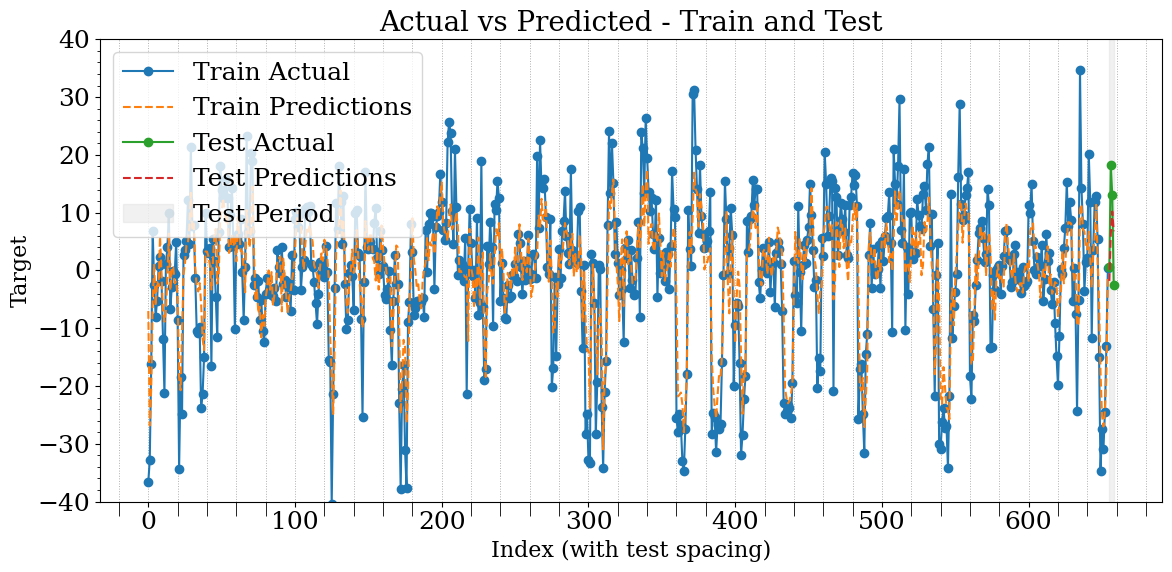

Train MAE: 5.2665
Train MAPE: 5.8050
Test MAE: 6.5746
Test MAPE: 2.2321


In [280]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# Train the best ML model on the training data

best_model.fit(X_train, y_train)

# In-sample predictions for the training set
train_predictions = best_model.predict(X_train)

# Forecasting for the test set
test_predictions = best_model.predict(X_test)

# Calculate evaluation metrics for the training set
train_mae = mean_absolute_error(y_train, train_predictions)
train_mape = mean_absolute_percentage_error(y_train, train_predictions)

# Calculate evaluation metrics for the test set
test_mae = mean_absolute_error(y_test, test_predictions)
test_mape = mean_absolute_percentage_error(y_test, test_predictions)


plt.figure(figsize=(14, 6))

# Convert index to a numeric range for controlled spacing
train_x = np.arange(len(train_data))
test_x = np.arange(len(test_data))  + len(train_data)  # 5x spacing and offset after train

# Plot actual and predicted values
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data['Target'], label='Train Actual', marker='o')
plt.plot(train_data.index, train_predictions, label='Train Predictions', linestyle='--')
plt.plot(test_data.index, test_data['Target'], label='Test Actual', marker='o')
plt.plot(test_data.index, test_predictions, label='Test Predictions', linestyle='--')

# Highlight the test period
plt.axvspan(test_x[0], test_x[-1], color='lightgray', alpha=0.3, label='Test Period')

# Make gridlines denser
plt.minorticks_on()
plt.grid(which='both', axis='x', linestyle=':', linewidth=0.7)
plt.tick_params(axis='x', which='minor', length=10)

# Add labels and legend
plt.xlabel('Index (with test spacing)')
plt.ylabel('Target')
plt.title('Actual vs Predicted - Train and Test')
plt.legend(loc='upper left')  # 👈 Changed legend position here
plt.tight_layout()
plt.ylim(-40, 40)
plt.show()

# Output the evaluation metrics
print("Train MAE: {:.4f}".format(train_mae))
print("Train MAPE: {:.4f}".format(train_mape))
print("Test MAE: {:.4f}".format(test_mae))
print("Test MAPE: {:.4f}".format(test_mape))


   Combined_Sum
0     38.313712
1     47.147194
2     47.819818
3     37.082582
MAE: 6.70
MAPE: 17.09%


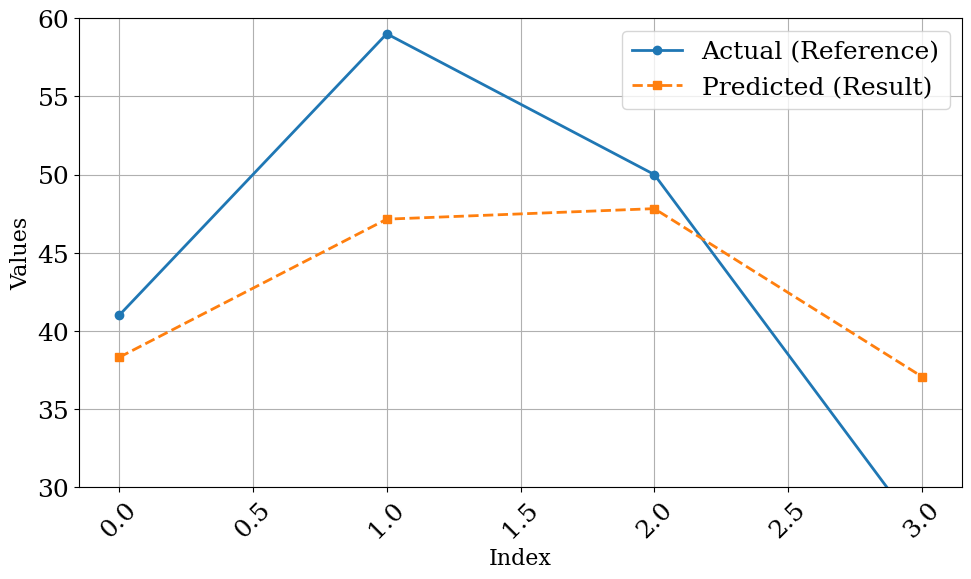

In [281]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# Fit the best model on the training data (exogenous features)
best_model.fit(X_train, y_train)

# Make predictions on the test set
predictions = best_model.predict(X_test)

# Convert the DataFrames to NumPy arrays
predictions_array = predictions.flatten()
summed_up_array = summed_up.to_numpy().flatten()

# Ensure both arrays have the same length
min_length = min(len(predictions_array), len(summed_up_array))
predictions_array = predictions_array[:min_length]
summed_up_array = summed_up_array[:min_length]

# Perform element-wise summation
combined_sum_array = predictions_array + summed_up_array

# Convert the result back to a DataFrame (optional)
result_df = pd.DataFrame(combined_sum_array, columns=['Combined_Sum'])

# Print the resulting DataFrame
print(result_df)

# Reset the index of the reference DataFrame
reference = reference.reset_index(drop=True)

# Ensure alignment of lengths
min_length = min(len(result_df), len(reference))
predicted = result_df.iloc[:min_length]['Combined_Sum']
test = reference.iloc[:min_length].squeeze()

# Calculate MAE and MAPE
mae = mean_absolute_error(test, predicted)
mape = mean_absolute_percentage_error(test, predicted)

# Print MAE and MAPE
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2%}")

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(test.index, test, label='Actual (Reference)', marker='o', linestyle='-', linewidth=2)
plt.plot(predicted.index, predicted, label='Predicted (Result)', marker='s', linestyle='--', linewidth=2)

plt.xlabel('Index')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(30, 60)
plt.show()




In [282]:
end_time=time.time()

In [283]:
Cost=end_time-start_time

In [284]:
main_results = update_results(main_results, 'Regression Model W SELECTED FEATURES', mae, mape, Cost)

In [285]:
main_results

,Model_Name,MAE,MAPE,Cost
0,BASE SARIMA WITHOUT DECOMPOSITION,14.107829,0.293031,33.096646
1,BASE AUTO SARIMA WITHOUT DECOMPOSITION,12.438014,0.290428,66.778659
2,SARIMA by DECOMPOSITION W NO FEATURE,3.883099,0.104131,6.707407
3,AUTO SARIMA BY DECOMPOSITION W NO FEATURE,7.025086,0.172624,39.854797
4,Topological Dataset,0,0,0
5,SARIMA W ALL FEATUREs,19.445691,0.514501,100.935903
6,SARIMA W RFE FEATUREs,6.038522,0.175575,420.725752
7,SARIMA W RFE + PSO FEATUREs,3.772896,0.098696,11.606659
8,SARIMA W RFE + PSO BEST FEATUREs,3.772896,0.098696,5.616401
9,Regression Model W SELECTED FEATURES,8.202009,0.172503,313.378184


# MODEL 5 : ALL FEATURES REGRESSION ANALYSIS

In [286]:
data

,Operation__mean_change,Operation__mean_second_derivative_central,Operation__median,Operation__variation_coefficient,Operation__variance,Operation__skewness,Operation__kurtosis,Operation__longest_strike_below_mean,Operation__longest_strike_above_mean,Operation__count_below_mean,...,Operation__energy_ratio_by_chunks__num_segments_10__segment_focus_8,Operation__energy_ratio_by_chunks__num_segments_10__segment_focus_9,Operation__ratio_beyond_r_sigma__r_0.5,Operation__fourier_entropy__bins_2,Operation__fourier_entropy__bins_3,Operation__fourier_entropy__bins_5,Operation__fourier_entropy__bins_10,Operation__fourier_entropy__bins_100,Operation__permutation_entropy__dimension_4__tau_1,Target
0,0.435641,0.403709,0.766209,0.303235,0.115800,0.390664,0.241996,0.428571,0.428571,0.454545,...,0.038271,0.018029,0.533333,0.377411,0.322247,0.504556,0.522383,0.613147,0.695534,-36.630516
1,0.000000,0.152973,0.724083,0.304089,0.276186,0.067671,0.814625,0.214286,0.500000,0.363636,...,0.024161,0.640073,0.333333,0.377411,0.506185,0.504556,0.541618,0.742098,0.695534,-32.755274
2,0.106475,0.539077,0.689861,0.324647,0.361447,0.079330,0.563293,0.071429,0.428571,0.090909,...,0.009689,0.924360,0.466667,0.000000,0.506185,0.576236,0.647616,0.871049,0.721786,-16.242944
3,0.288723,0.589949,0.679788,0.299041,0.372947,0.137649,0.447570,0.071429,0.357143,0.090909,...,0.562813,0.493819,0.466667,0.000000,0.506185,0.576236,0.603281,0.564475,0.721786,6.891582
4,0.465402,0.677543,0.679788,0.299092,0.372415,0.137327,0.448262,0.071429,0.285714,0.090909,...,1.000000,0.115074,0.466667,0.000000,0.322247,0.576236,0.459491,0.742098,0.721786,-2.448256
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
654,0.425908,0.516370,0.546702,0.301186,0.697103,0.523267,0.149290,0.285714,0.071429,0.545455,...,0.377922,0.152297,0.600000,0.642046,0.631758,0.504556,0.522383,0.742098,0.556427,0.412770
655,0.494867,0.665126,0.615010,0.301060,0.697851,0.512795,0.148954,0.285714,0.071429,0.454545,...,0.344663,0.034025,0.533333,0.642046,0.506185,0.504556,0.522383,0.871049,0.530175,0.543904
656,0.565500,0.622909,0.617428,0.301057,0.697949,0.512553,0.148874,0.285714,0.071429,0.454545,...,0.171173,0.000000,0.533333,0.377411,0.631758,0.576236,0.540389,0.871049,0.417320,18.180364
657,0.868459,0.447348,0.636607,0.300019,0.739417,0.486269,0.127158,0.285714,0.071429,0.363636,...,0.036675,0.063021,0.600000,0.377411,0.680745,0.687523,0.540389,0.693426,0.361342,13.045591


In [287]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from xgboost import XGBRegressor

start_time=time.time()

# Step 1: Split the data
train_data = data[:-4]
test_data = data[-4:]

X_train = train_data.drop(columns=["Target"])
X_test = test_data.drop(columns=["Target"])
y_train = train_data["Target"]
y_test = test_data["Target"]

In [288]:
import warnings
warnings.filterwarnings("ignore")  # Suppress all warnings

from sklearn.linear_model import Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, make_scorer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import pandas as pd
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
# Optional: scale for SVR and other sensitive models
scaler = StandardScaler()


tscv = TimeSeriesSplit(n_splits=5)

# Step 1: Define models and their hyperparameter grids
models = {
    "Lasso": (Lasso(), {
        "alpha": [0.001, 0.01, 0.1, 1, 10]
    }),
    "ElasticNet": (ElasticNet(), {
        "alpha": [0.001, 0.01, 0.1, 1, 10],
        "l1_ratio": [0.1, 0.5, 0.9]
    }),
    "RandomForest": (RandomForestRegressor(), {
        "n_estimators": [100, 200],
        "max_depth": [None, 10, 20]
    }),
    "XGBoost": (XGBRegressor(verbosity=0), {
        "n_estimators": [100, 200],
        "learning_rate": [0.01, 0.1],
        "max_depth": [3, 6]
    }),
    
    "CatBoost": (CatBoostRegressor(verbose=0), {
        "iterations": [100, 200],
        "learning_rate": [0.01, 0.1],
        "depth": [3, 6]
    }),
    "GradientBoosting": (GradientBoostingRegressor(), {
        "n_estimators": [100, 200],
        "learning_rate": [0.01, 0.1],
        "max_depth": [3, 6]
    }),
    "SVR": (Pipeline([
        ('scaler', StandardScaler()),
        ('svr', SVR())
    ]), {
        "svr__C": [0.1, 1, 10],
        "svr__epsilon": [0.01, 0.1]
    })
}

results = []

# Step 2: Run grid search and evaluate
for name, (model, param_grid) in models.items():
    print(f"🔍 Tuning {name}...")

    grid = GridSearchCV(model, param_grid, cv=tscv, scoring=make_scorer(mean_absolute_error, greater_is_better=False), n_jobs=-1)
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    preds = best_model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    mape = mean_absolute_percentage_error(y_test, preds)

    results.append({
        "Model": name,
        "MAE": mae,
        "MAPE": mape,
        "ModelObject": best_model,
        "BestParams": grid.best_params_
    })

# Step 3: Choose the best model based on MAE, then MAPE
results_df = pd.DataFrame(results).sort_values(by=["MAE", "MAPE"])
best = results_df.iloc[0]
best_model = best["ModelObject"]

print("✅ Best Model:", best["Model"])
print("🔹 MAE:", best["MAE"])
print("🔹 MAPE:", best["MAPE"])
print("🎯 Best Params:", best["BestParams"])


🔍 Tuning Lasso...
🔍 Tuning ElasticNet...
🔍 Tuning RandomForest...
🔍 Tuning XGBoost...
🔍 Tuning CatBoost...
🔍 Tuning GradientBoosting...
🔍 Tuning SVR...
✅ Best Model: ElasticNet
🔹 MAE: 6.296343608769987
🔹 MAPE: 2.5159697657993405
🎯 Best Params: {'alpha': 0.1, 'l1_ratio': 0.5}


<Figure size 1400x600 with 0 Axes>

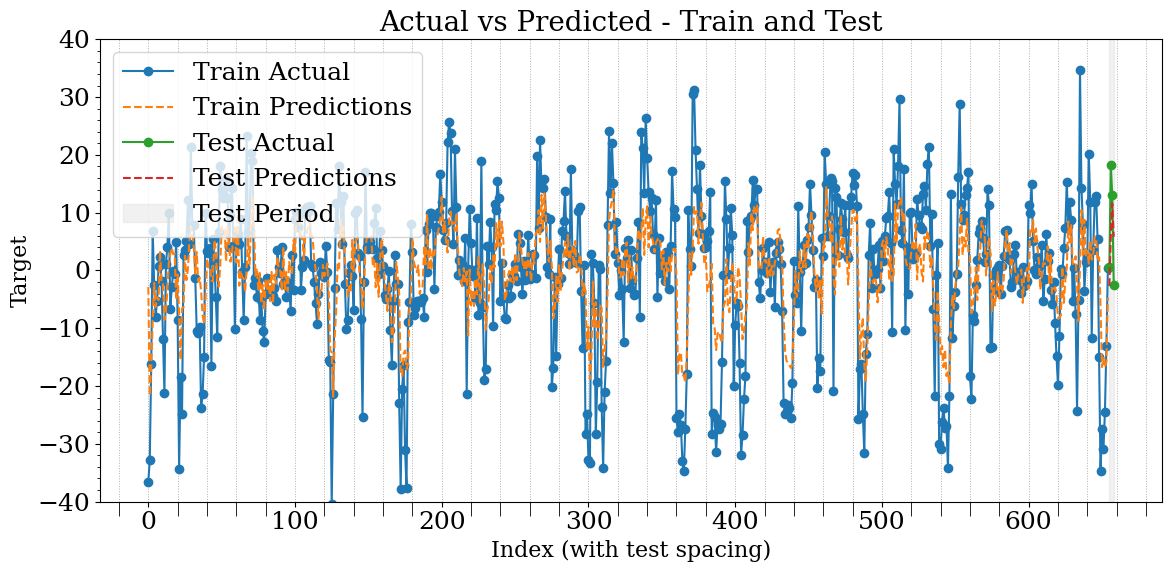

Train MAE: 6.8193
Train MAPE: 7.1797
Test MAE: 6.2963
Test MAPE: 2.5160


In [289]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# Train the best ML model on the training data

best_model.fit(X_train, y_train)

# In-sample predictions for the training set
train_predictions = best_model.predict(X_train)

# Forecasting for the test set
test_predictions = best_model.predict(X_test)

# Calculate evaluation metrics for the training set
train_mae = mean_absolute_error(y_train, train_predictions)
train_mape = mean_absolute_percentage_error(y_train, train_predictions)

# Calculate evaluation metrics for the test set
test_mae = mean_absolute_error(y_test, test_predictions)
test_mape = mean_absolute_percentage_error(y_test, test_predictions)


plt.figure(figsize=(14, 6))

# Convert index to a numeric range for controlled spacing
train_x = np.arange(len(train_data))
test_x = np.arange(len(test_data))  + len(train_data)  # 5x spacing and offset after train

# Plot actual and predicted values
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data['Target'], label='Train Actual', marker='o')
plt.plot(train_data.index, train_predictions, label='Train Predictions', linestyle='--')
plt.plot(test_data.index, test_data['Target'], label='Test Actual', marker='o')
plt.plot(test_data.index, test_predictions, label='Test Predictions', linestyle='--')

# Highlight the test period
plt.axvspan(test_x[0], test_x[-1], color='lightgray', alpha=0.3, label='Test Period')

# Make gridlines denser
plt.minorticks_on()
plt.grid(which='both', axis='x', linestyle=':', linewidth=0.7)
plt.tick_params(axis='x', which='minor', length=10)

# Add labels and legend
plt.xlabel('Index (with test spacing)')
plt.ylabel('Target')
plt.title('Actual vs Predicted - Train and Test')
plt.legend(loc='upper left')  # 👈 Changed legend position here
plt.tight_layout()
plt.ylim(-40, 40)
plt.show()

# Output the evaluation metrics
print("Train MAE: {:.4f}".format(train_mae))
print("Train MAPE: {:.4f}".format(train_mape))
print("Test MAE: {:.4f}".format(test_mae))
print("Test MAPE: {:.4f}".format(test_mape))


   Combined_Sum
0     37.440527
1     46.806950
2     49.200506
3     36.136983
MAE: 6.42
MAPE: 16.20%


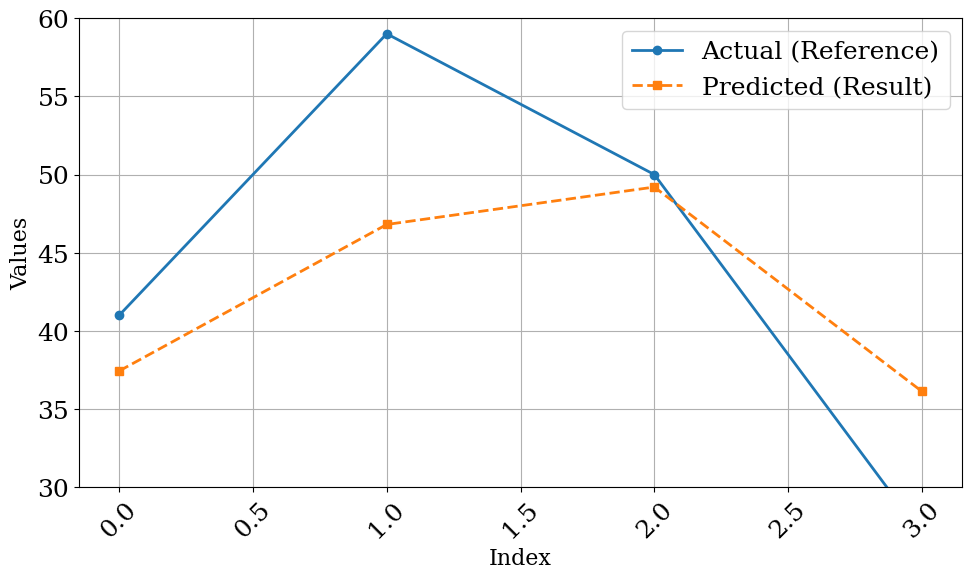

In [290]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# Fit the best model on the training data (exogenous features)
best_model.fit(X_train, y_train)

# Make predictions on the test set
predictions = best_model.predict(X_test)

# Convert the DataFrames to NumPy arrays
predictions_array = predictions.flatten()
summed_up_array = summed_up.to_numpy().flatten()

# Ensure both arrays have the same length
min_length = min(len(predictions_array), len(summed_up_array))
predictions_array = predictions_array[:min_length]
summed_up_array = summed_up_array[:min_length]

# Perform element-wise summation
combined_sum_array = predictions_array + summed_up_array

# Convert the result back to a DataFrame (optional)
result_df = pd.DataFrame(combined_sum_array, columns=['Combined_Sum'])

# Print the resulting DataFrame
print(result_df)

# Reset the index of the reference DataFrame
reference = reference.reset_index(drop=True)

# Ensure alignment of lengths
min_length = min(len(result_df), len(reference))
predicted = result_df.iloc[:min_length]['Combined_Sum']
test = reference.iloc[:min_length].squeeze()

# Calculate MAE and MAPE
mae = mean_absolute_error(test, predicted)
mape = mean_absolute_percentage_error(test, predicted)

# Print MAE and MAPE
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2%}")

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(test.index, test, label='Actual (Reference)', marker='o', linestyle='-', linewidth=2)
plt.plot(predicted.index, predicted, label='Predicted (Result)', marker='s', linestyle='--', linewidth=2)

plt.xlabel('Index')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(30, 60)
plt.show()




In [291]:
end_time=time.time()

In [292]:
Cost=end_time-start_time

In [293]:
main_results = update_results(main_results, 'Regression Model All', mae, mape, Cost)

In [294]:
main_results

,Model_Name,MAE,MAPE,Cost
0,BASE SARIMA WITHOUT DECOMPOSITION,14.107829,0.293031,33.096646
1,BASE AUTO SARIMA WITHOUT DECOMPOSITION,12.438014,0.290428,66.778659
2,SARIMA by DECOMPOSITION W NO FEATURE,3.883099,0.104131,6.707407
3,AUTO SARIMA BY DECOMPOSITION W NO FEATURE,7.025086,0.172624,39.854797
4,Topological Dataset,0,0,0
5,SARIMA W ALL FEATUREs,19.445691,0.514501,100.935903
6,SARIMA W RFE FEATUREs,6.038522,0.175575,420.725752
7,SARIMA W RFE + PSO FEATUREs,3.772896,0.098696,11.606659
8,SARIMA W RFE + PSO BEST FEATUREs,3.772896,0.098696,5.616401
9,Regression Model W SELECTED FEATURES,8.202009,0.172503,313.378184


# MODEL 6 HYBRID MODEL REGRESSION AND SARIMA

In [295]:
start_time=time.time()

In [296]:
# Step 4: Apply best model to the entire dataset
X_all = data.drop(columns=["Target"])
y_all = data["Target"]
preds_all = best_model.predict(X_all)

In [297]:
# Step 5: Create the difference DataFrame
diff_df = pd.DataFrame({
    "Actual": y_all.values,
    "Predicted": preds_all,
    "Difference": y_all.values - preds_all
}, index=data.index)

In [298]:
# Step 1: Create a new column 'Target' from the residuals
diff_df['Target'] = diff_df['Difference']

# Step 2: Split the data into train and test
y_train = diff_df[:-4]
y_test = diff_df[-4:]

In [299]:
from statsmodels.tsa.stattools import kpss

# Applying the KPSS test to the training data to test for stationarity
kpss_test = kpss(y_train['Target'], regression='c')

# Unpacking the KPSS test results
kpss_statistic, p_value, lags, critical_values = kpss_test

# Displaying the KPSS test results
kpss_test_result = {
    'KPSS Statistic': kpss_statistic,
    'p-value': p_value,
    'Lags Used': lags,
    'Critical Values': critical_values,
    'Conclusion': 'Stationary' if p_value > 0.05 else 'Not stationary'
}

kpss_test_result


{'KPSS Statistic': 0.06096488804406898,
 'p-value': 0.1,
 'Lags Used': 8,
 'Critical Values': {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739},
 'Conclusion': 'Stationary'}

In [300]:
from pmdarima.arima import auto_arima, OCSBTest, CHTest

# time series after first differencing
# OCSB test that returns the recommended order of seasonal differencing:
n_ocsb = OCSBTest(m=12).estimate_seasonal_differencing_term(y_train['Target'])

# CH test that returns the recommended order of seasonal differencing:
n_ch = CHTest(m=12).estimate_seasonal_differencing_term(y_train['Target'])

# seasonal differencing recommendation:
print("time series -")
n_seasdiffs = {"recommended order of seasonal differencing":"", "OCSB recommendation":n_ocsb, "nCH recommendation":n_ch}
[print(key, ":", value) for key,value in n_seasdiffs.items()]

time series -
recommended order of seasonal differencing : 
OCSB recommendation : 0
nCH recommendation : 0


[None, None, None]

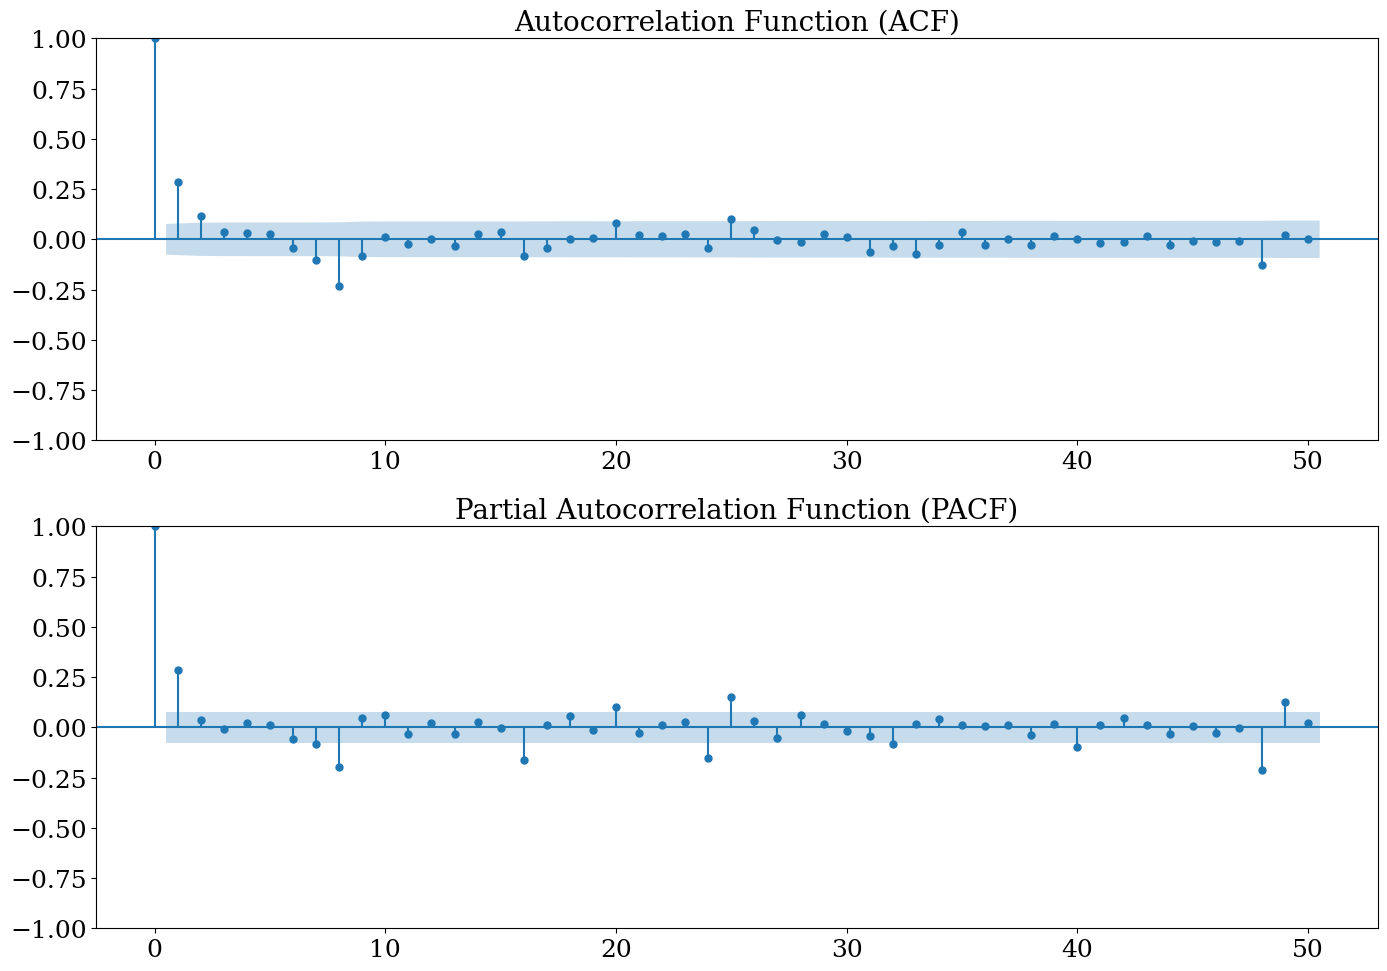

In [301]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot ACF and PACF for the cleaned training data
plt.figure(figsize=(14, 10))

# ACF plot
plt.subplot(2, 1, 1)
plot_acf(y_train['Target'], lags=50, ax=plt.gca())
plt.title("Autocorrelation Function (ACF)")

# PACF plot
plt.subplot(2, 1, 2)
plot_pacf(y_train['Target'], lags=50, ax=plt.gca(), method='ywm')
plt.title("Partial Autocorrelation Function (PACF)")

# Save the figure as an SVG file
plt.savefig("acf_h1.svg", format="svg", dpi=900, bbox_inches='tight', facecolor='white')
plt.tight_layout()
plt.show()

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[8] intercept   : AIC=4755.366, Time=0.04 sec
 ARIMA(1,0,0)(1,0,0)[8] intercept   : AIC=4668.023, Time=0.80 sec
 ARIMA(0,0,1)(0,0,1)[8] intercept   : AIC=4658.586, Time=0.29 sec
 ARIMA(0,0,0)(0,0,0)[8]             : AIC=4753.366, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[8] intercept   : AIC=4707.505, Time=0.20 sec
 ARIMA(0,0,1)(1,0,1)[8] intercept   : AIC=inf, Time=0.65 sec
 ARIMA(0,0,1)(0,0,2)[8] intercept   : AIC=4627.330, Time=0.66 sec
 ARIMA(0,0,1)(1,0,2)[8] intercept   : AIC=inf, Time=1.41 sec
 ARIMA(0,0,0)(0,0,2)[8] intercept   : AIC=4678.991, Time=0.38 sec
 ARIMA(1,0,1)(0,0,2)[8] intercept   : AIC=4595.017, Time=1.12 sec
 ARIMA(1,0,1)(0,0,1)[8] intercept   : AIC=4648.081, Time=0.39 sec
 ARIMA(1,0,1)(1,0,2)[8] intercept   : AIC=inf, Time=1.68 sec
 ARIMA(1,0,1)(1,0,1)[8] intercept   : AIC=inf, Time=1.13 sec
 ARIMA(1,0,0)(0,0,2)[8] intercept   : AIC=4608.155, Time=0.61 sec
 ARIMA(2,0,1)(0,0,2)[8] intercept   : AIC=4596.878, T

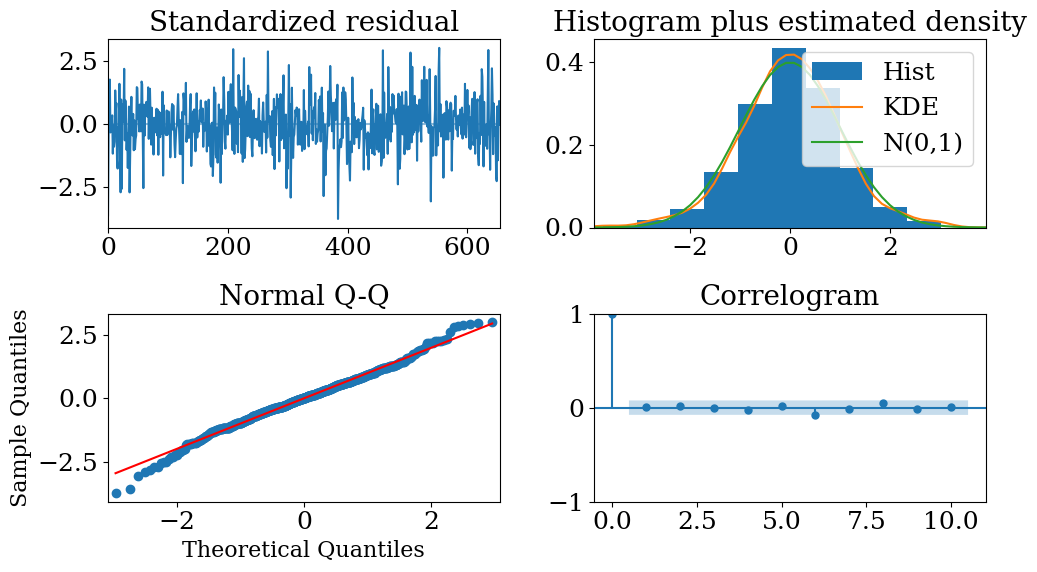

In [302]:
from pmdarima import auto_arima
import matplotlib.pyplot as plt

# Extract the time series from your training data
y_series = y_train['Target']

# Fit the seasonal ARIMA model
stepwise_model = auto_arima(
    y_series,
    start_p=0, start_q=0,
    max_p=5, max_q=5,
    seasonal=True,
    m=8,  # seasonal period
    start_P=0, start_Q=0,
    max_P=2, max_Q=2,
    d=None, D=None,           # let auto_arima figure out differencing
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True,
    information_criterion='aic'
)

# Print summary of the best model
print(stepwise_model.summary())

# Plot diagnostics
stepwise_model.plot_diagnostics(figsize=(10, 6))
plt.tight_layout()
plt.show()


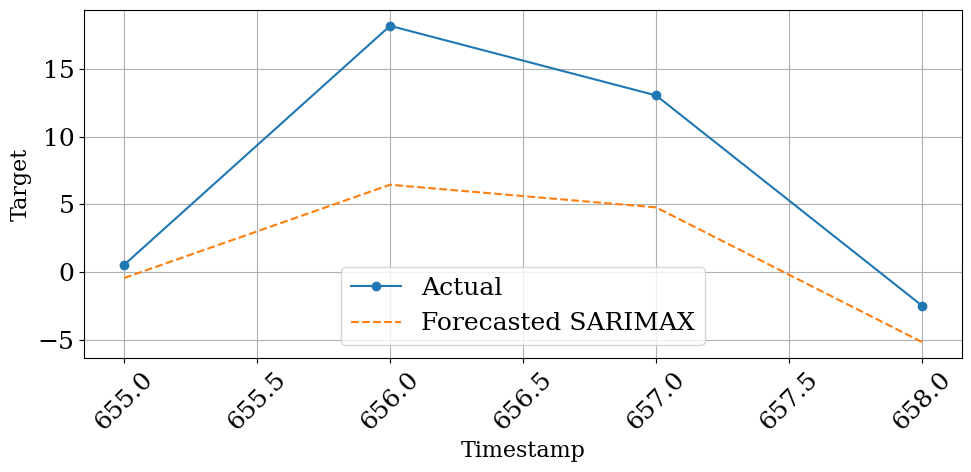

(5.908902514378241, 1.0359474129806792)

In [303]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt


n_periods = len(test_data)
sarima_predictions = stepwise_model.predict(n_periods=n_periods)

# Calculate evaluation metrics
sarima_mse = mean_absolute_error(test_data['Target'], sarima_predictions)
sarima_mape = mean_absolute_percentage_error(test_data['Target'], sarima_predictions)

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(test_data.index, test_data['Target'], label='Actual', marker='o')
plt.plot(test_data.index, sarima_predictions, label='Forecasted SARIMAX', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Output the MSE and MAPE values
sarima_mse, sarima_mape


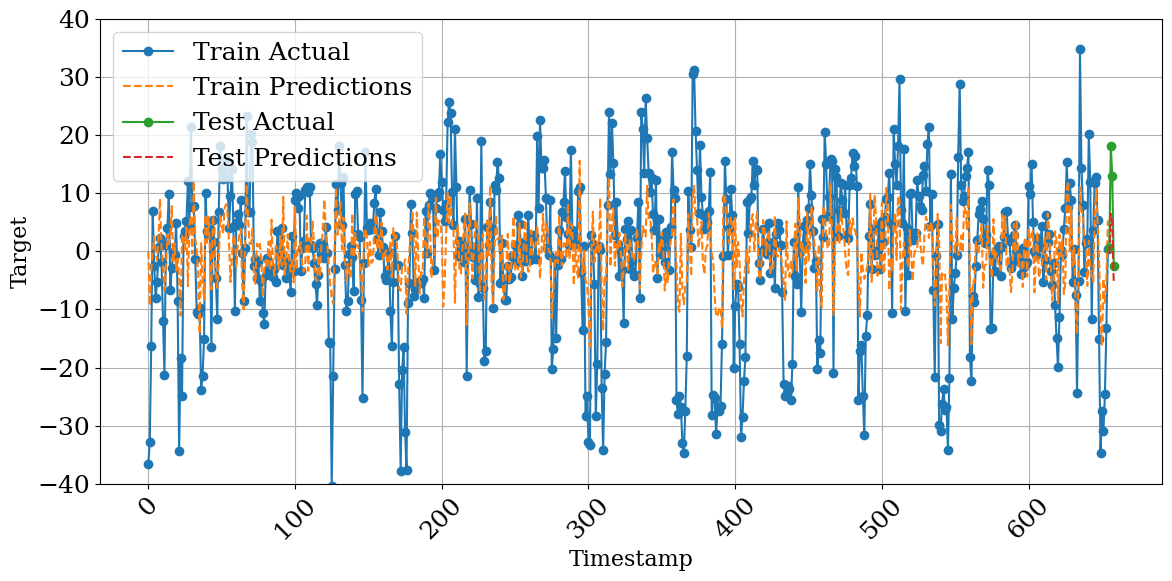

Train MAE: 7.8606
Train MAPE: 9.4210
Test MAE: 5.9089
Test MAPE: 1.0359


In [304]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# In-sample predictions for the training set
train_predictions = stepwise_model.predict_in_sample()

# Forecasting the values for the test set
test_predictions = stepwise_model.predict(n_periods=len(test_data))

# Calculate evaluation metrics for the training set
train_mae = mean_absolute_error(train_data['Target'], train_predictions)
train_mape = mean_absolute_percentage_error(train_data['Target'], train_predictions)

# Calculate evaluation metrics for the test set
test_mae = mean_absolute_error(test_data['Target'], test_predictions)
test_mape = mean_absolute_percentage_error(test_data['Target'], test_predictions)

# Plot the results: actual and predictions for both train and test data
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data['Target'], label='Train Actual', marker='o')
plt.plot(train_data.index, train_predictions, label='Train Predictions', linestyle='--')
plt.plot(test_data.index, test_data['Target'], label='Test Actual', marker='o')
plt.plot(test_data.index, test_predictions, label='Test Predictions', linestyle='--')

plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(-40, 40)
plt.show()

# Output the evaluation metrics
print("Train MAE: {:.4f}".format(train_mae))
print("Train MAPE: {:.4f}".format(train_mape))
print("Test MAE: {:.4f}".format(test_mae))
print("Test MAPE: {:.4f}".format(test_mape))


In [305]:
test_predictions

655   -0.424231
656    6.455935
657    4.784210
658   -5.151765
dtype: float64

In [306]:
# Combine them into one residual prediction series
residual_prediction = pd.concat([train_predictions, test_predictions])

In [307]:
residual_prediction

0      0.000000
1     -9.325055
2     -3.174504
3     -0.101575
4      2.631092
         ...   
654    5.328055
655   -0.424231
656    6.455935
657    4.784210
658   -5.151765
Length: 659, dtype: float64

In [308]:
# Step 2: Add SARIMA-predicted residuals to regression predictions
final_predictions = preds_all + residual_prediction

In [309]:
# Step 3: Create final DataFrame
final_df = pd.DataFrame({
    "Regression_Prediction": preds_all,
    "SARIMA_Residual_Prediction": residual_prediction,
    "Final_Prediction": final_predictions,
    "Actual": data["Target"],
    "Difference_Final": data["Target"] - final_predictions
})

# View sample
print(final_df.head())


   Regression_Prediction  SARIMA_Residual_Prediction  Final_Prediction  \
0              -2.860616                    0.000000         -2.860616   
1             -21.691757                   -9.325055        -31.016812   
2             -16.662282                   -3.174504        -19.836787   
3              -8.935645                   -0.101575         -9.037220   
4              -2.152956                    2.631092          0.478136   

      Actual  Difference_Final  
0 -36.630516        -33.769899  
1 -32.755274         -1.738462  
2 -16.242944          3.593843  
3   6.891582         15.928802  
4  -2.448256         -2.926392  


In [310]:
sarimax_forecast_array = final_df["Final_Prediction"].iloc[-4:].values
print("📦 sarimax_forecast_array:")
print(sarimax_forecast_array)


📦 sarimax_forecast_array:
[-3.09970248 12.44323502 16.36020544  0.68147399]


   Combined_Sum
0     39.691768
1     47.275585
2     42.408720
3     25.151978
MAE: 5.62
MAPE: 11.27%


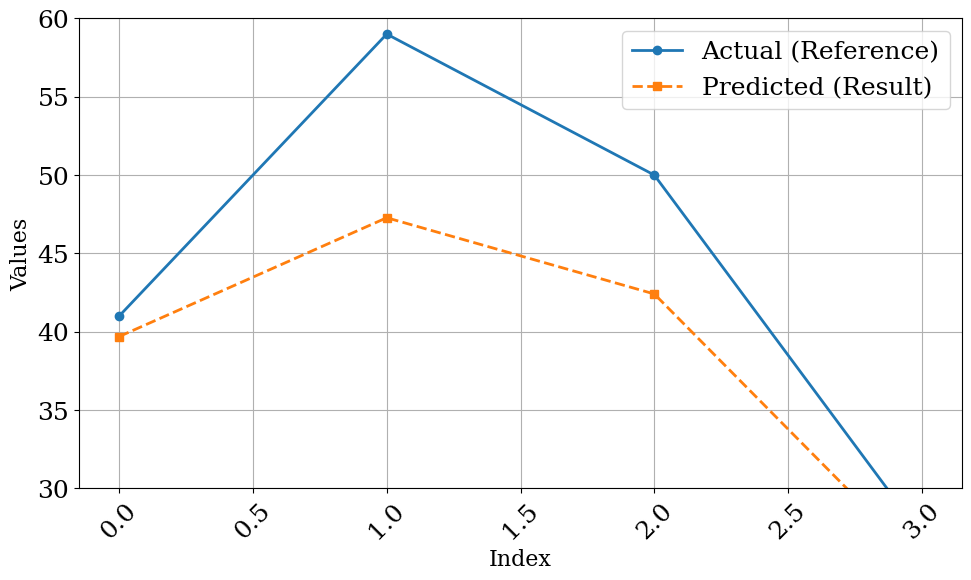

In [311]:
# Convert the DataFrames to NumPy arrays
sarimax_forecast_array = sarima_predictions.to_numpy().flatten()
summed_up_array = summed_up.to_numpy().flatten()

# Ensure both arrays have the same length
min_length = min(len(sarimax_forecast_array), len(summed_up_array))
sarimax_forecast_array = sarimax_forecast_array[:min_length]
summed_up_array = summed_up_array[:min_length]

# Perform element-wise summation
combined_sum_array = sarimax_forecast_array + summed_up_array

# Convert the result back to a DataFrame (optional)
result_df = pd.DataFrame(combined_sum_array, columns=['Combined_Sum'])

# Print the resulting DataFrame
print(result_df)

# Reset the index of the reference DataFrame
reference = reference.reset_index(drop=True)

# Ensure alignment of lengths
min_length = min(len(result_df), len(reference))
predicted = result_df.iloc[:min_length]['Combined_Sum']
test = reference.iloc[:min_length].squeeze()

# Calculate MAE and MAPE
mae = mean_absolute_error(test, predicted)
mape = mean_absolute_percentage_error(test, predicted)

# Print MAE and MAPE
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2%}")

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(test.index, test, label='Actual (Reference)', marker='o', linestyle='-', linewidth=2)
plt.plot(predicted.index, predicted, label='Predicted (Result)', marker='s', linestyle='--', linewidth=2)
 
plt.xlabel('Index')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(30, 60)
plt.show()


In [312]:
end_time=time.time()

In [313]:
Cost=end_time-start_time

In [314]:
main_results = update_results(main_results, 'Hybrid Model', mae, mape, Cost)

In [315]:
main_results

,Model_Name,MAE,MAPE,Cost
0,BASE SARIMA WITHOUT DECOMPOSITION,14.107829,0.293031,33.096646
1,BASE AUTO SARIMA WITHOUT DECOMPOSITION,12.438014,0.290428,66.778659
2,SARIMA by DECOMPOSITION W NO FEATURE,3.883099,0.104131,6.707407
3,AUTO SARIMA BY DECOMPOSITION W NO FEATURE,7.025086,0.172624,39.854797
4,Topological Dataset,0,0,0
5,SARIMA W ALL FEATUREs,19.445691,0.514501,100.935903
6,SARIMA W RFE FEATUREs,6.038522,0.175575,420.725752
7,SARIMA W RFE + PSO FEATUREs,3.772896,0.098696,11.606659
8,SARIMA W RFE + PSO BEST FEATUREs,3.772896,0.098696,5.616401
9,Regression Model W SELECTED FEATURES,8.202009,0.172503,313.378184


In [316]:
main_results.to_excel("main_results.xlsx", index=False)